In [115]:

import os
import sys
import subprocess
import re
import json
import pandas as pd
from pathlib import Path
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from statsmodels.stats.multitest import multipletests

# Try to import ete3 for tree manipulation
try:
    from ete3 import Tree
    ETE3_AVAILABLE = True
    print("ete3 is available for tree anipulation")
except ImportError:
    ETE3_AVAILABLE = False
    print("WARNING: ete3 not available. Tree manipulation will be limited.")

print("All imports successful!")

ete3 is available for tree anipulation
All imports successful!


In [116]:
OUTPUT_DIR = "pipeline_results"
BAT_PROTEOME_FILE="all_birds_proteins_tagged_merged.faa"

In [117]:
DIRS = {
    'mmseqs_results': os.path.join(OUTPUT_DIR, '01_mmseqs_results'),
    'paired_proteins': os.path.join(OUTPUT_DIR, '02_paired_proteins'),
    'nucleotides': os.path.join(OUTPUT_DIR, '03_nucleotides'),
    'alignments': os.path.join(OUTPUT_DIR, '04_alignmentss'),
    'pal2nal': os.path.join(OUTPUT_DIR, '05_pal2nal_normalized_no_duplicates'),
    'trees': os.path.join(OUTPUT_DIR, '06_trees'),
    'labeled_trees': os.path.join(OUTPUT_DIR, '07_labeled_trees'),
    'busted': os.path.join(OUTPUT_DIR, '08_busted'),
    'relax': os.path.join(OUTPUT_DIR, '08b_relax'),
    'busted_background': os.path.join(OUTPUT_DIR, '08c_busted_background'),
    'absrel': os.path.join(OUTPUT_DIR, '09_absrel'),
    'meme': os.path.join(OUTPUT_DIR, '09b_meme'),
    'fitmg94': os.path.join(OUTPUT_DIR, '09_fitmg94'),
    'summary': os.path.join(OUTPUT_DIR, '11_summary'),
    'tmp': os.path.join(OUTPUT_DIR, 'tmp'),
}
for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"Created: {dir_path}")

print("\nDirectory structure created!")

Created: pipeline_results/01_mmseqs_results
Created: pipeline_results/02_paired_proteins
Created: pipeline_results/03_nucleotides
Created: pipeline_results/04_alignmentss
Created: pipeline_results/05_pal2nal_normalized_no_duplicates
Created: pipeline_results/06_trees
Created: pipeline_results/07_labeled_trees
Created: pipeline_results/08_busted
Created: pipeline_results/08b_relax
Created: pipeline_results/08c_busted_background
Created: pipeline_results/09_absrel
Created: pipeline_results/09b_meme
Created: pipeline_results/09_fitmg94
Created: pipeline_results/11_summary
Created: pipeline_results/tmp

Directory structure created!


# 1. Mmseq2

на вход: 
- объединенные и протэганные (название вида перед > (Род_вид)) птичьи протеомы 
- человеческие белки--таргеты
выход: таблица квери--таргет
потом из нее оставляем по лучшему хиту на вид

чтобы сделать по категориям захожу в окружение где стоит mmseq(based) и запускаю цикл (файл mmseq_cicl.sh, не забыть сделать исполняемым)по всем файлам из папки со следующей следующими параметрами PARAMS="-c 0.2 --min-seq-id 0.3 --alt-ali 25 --threads 12"


результаты лежат в папке dn_ds_pipeline/pipeline_results/01_mmseqs_results/category

## обработка результатов
1. собираем файлы по кусочкам + добавляем столбец с тегом+добавляем LQ и то находится ли LQ в вехних 20 процентах
2. ищем лучшее вхождение для данного вида
3. оставляем только гены, для которых достаточное количество видов имеют гомологи + где есть хотя бы 5 долгоживущих
4. долгоживущие определяются как верхние 20 процентов

In [181]:
import os
import pandas as pd
df=pd.DataFrame()
folder = "category_easy_search"
for filename in os.listdir(folder):
    filepath = os.path.join(folder, filename)
    if os.path.isfile(filepath):          # только файлы, не папки
        # делаем что-то с файлом
        columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
               "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
        
        df_mmseqs = pd.read_csv(filepath, sep='\t', names=columns)
        
        if df_mmseqs["qseqid"].isna().sum()!=0:
            print(f'в файле{filename} какая-то полная хуйня')
        teg=filepath.split('/')[-1][10:-3]
        df_mmseqs['teg']=teg
        df_mmseqs['tag'] = df_mmseqs['teg'].astype(str).str.replace(r'_+', ' ', regex=True)
        
        
        df = pd.concat([df, df_mmseqs], axis=0)
        df['tag']=df['tag'].str.split('.').str[0]
        # print(filepath.split('/')[-1][10:-2])
df


в файлеhomologs__uncat_genes_proteins.m8 какая-то полная хуйня


,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,teg,tag
0,RHOT1,Cygnus_olor|XP_040386766.1,0.895,659,68,0,1,650,1,659,0.000000e+00,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
1,RHOT1,Cygnus_atratus|XP_035414759.1,0.895,659,68,0,1,650,1,659,0.000000e+00,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
2,RHOT1,Anser_cygnoides|XP_047920573.1,0.895,659,68,0,1,650,1,659,0.000000e+00,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
3,RHOT1,Mycteria_americana|XP_075374675.1,0.892,659,70,0,1,650,1,659,0.000000e+00,1222,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
4,RHOT1,Phalacrocorax_carbo|XP_064323223.1,0.892,659,70,0,1,650,1,659,0.000000e+00,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10704,HDAC4,Haliaeetus_albicilla|XP_069638295.1,0.896,713,74,0,22,729,1,713,0.000000e+00,1190,hromatin_remodeling_genes_proteins,hromatin remodeling genes proteins
10705,HDAC4,Harpia_harpyja|XP_052647396.1,0.896,713,74,0,22,729,1,713,0.000000e+00,1190,hromatin_remodeling_genes_proteins,hromatin remodeling genes proteins
10706,HDAC4,Aquila_chrysaetos_chrysaetos|XP_029873193.1,0.896,713,74,0,22,729,1,713,0.000000e+00,1189,hromatin_remodeling_genes_proteins,hromatin remodeling genes proteins
10707,HDAC4,Corvus_cornix_cornix|XP_039410494.1,0.894,712,75,0,22,729,1,712,0.000000e+00,1182,hromatin_remodeling_genes_proteins,hromatin remodeling genes proteins


In [124]:
es=list(set(df['qseqid']))

1064

In [182]:

# Examine MMseqs2 results

    
print(f"Total hits: {len(df)}")
print(f"Unique query genes: {df['qseqid'].nunique()}")
print(f"Unique subject sequences: {df['sseqid'].nunique()}")
print(f"\nFirst 10 rows:")
display(df.head(10))


Total hits: 620310
Unique query genes: 2289
Unique subject sequences: 528320

First 10 rows:


,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,teg,tag
0,RHOT1,Cygnus_olor|XP_040386766.1,0.895,659,68,0,1,650,1,659,0.0,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
1,RHOT1,Cygnus_atratus|XP_035414759.1,0.895,659,68,0,1,650,1,659,0.0,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
2,RHOT1,Anser_cygnoides|XP_047920573.1,0.895,659,68,0,1,650,1,659,0.0,1223,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
3,RHOT1,Mycteria_americana|XP_075374675.1,0.892,659,70,0,1,650,1,659,0.0,1222,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
4,RHOT1,Phalacrocorax_carbo|XP_064323223.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
5,RHOT1,Ammospiza_caudacuta|XP_058673040.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
6,RHOT1,Zonotrichia_albicollis|XP_074410889.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
7,RHOT1,Zonotrichia_leucophrys_gambelii|XP_064584461.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
8,RHOT1,Melospiza_georgiana|XP_057894620.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...
9,RHOT1,Molothrus_aeneus|XP_066422039.1,0.892,659,70,0,1,650,1,659,0.0,1221,mpairment_of_the_mitochondrial_integrity_and_b...,mpairment of the mitochondrial integrity and b...


In [183]:
df['spices']=df['sseqid'].str.split('|').str[0]

In [186]:
# =============================================================================
# STEP 2: EXTRACT BEST MATCHES
# =============================================================================
columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
           "qstart", "qend", "sstart", "send", "evalue", "bitscore"]

df = df.reset_index(drop=True).copy()
df["pident"] = pd.to_numeric(df["pident"], errors="coerce")
df["bitscore"] = pd.to_numeric(df["bitscore"], errors="coerce")
df["length"] = pd.to_numeric(df["length"], errors="coerce")
df["spices"] = df["sseqid"].str.split("|").str[0]

print(f"Loaded {len(df)} hits from MMseqs2 results")

best_matches = pd.DataFrame()

for prefix in set(df["spices"]):
    bat_matches = df[df["sseqid"].str.startswith(prefix)].reset_index(drop=True)

    if not bat_matches.empty:
        best_bat_matches = (
            bat_matches
            .sort_values(["qseqid", "pident", "bitscore", "length"],
                         ascending=[True, False, False, False])
            .drop_duplicates(subset=["qseqid"], keep="first")
        )
        best_matches = pd.concat([best_matches, best_bat_matches], ignore_index=True)

# Save best matches
BEST_MATCHES_CSV = os.path.join('pipeline_results/01_mmseqs_results', 'best_matches.csv')
best_matches.to_csv(BEST_MATCHES_CSV, index=False)

print(f"\nFound {len(best_matches)} best matches")
print(f"Unique genes: {best_matches['qseqid'].nunique()}")
print(f"\nBest matches saved to: {BEST_MATCHES_CSV}")

# Summary statistics
bat_counts = best_matches.groupby('qseqid')['spices'].nunique()
print(f"\nBirds species per gene:")
print(f"  Median: {bat_counts.median():.0f}")
print(f"  Min: {bat_counts.min()}")
print(f"  Max: {bat_counts.max()}")
print(f"\nMedian percent identity: {best_matches['pident'].median():.2f}%")

Loaded 620310 hits from MMseqs2 results

Found 221952 best matches
Unique genes: 2289

Best matches saved to: pipeline_results/01_mmseqs_results/best_matches.csv

Birds species per gene:
  Median: 105
  Min: 1
  Max: 107

Median percent identity: 0.77%


In [190]:
best_matches

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,teg,tag,spices
0,A2M,Zonotrichia_albicollis|XP_074391075.1,0.578,1471,619,0,1,1468,1,1471,0.000000e+00,1675,tem_cell_exhaustion_genes_proteins,tem cell exhaustion genes proteins,Zonotrichia_albicollis
1,AARS1,Zonotrichia_albicollis|XP_005490794.1,0.870,968,126,0,1,968,1,968,0.000000e+00,1737,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis
2,AASS,Zonotrichia_albicollis|XP_074396065.1,0.814,297,55,0,159,455,1,295,1.087000e-164,528,ccumulation_of_reactive_oxygen_species_genes_p...,ccumulation of reactive oxygen species genes p...,Zonotrichia_albicollis
3,ABCA5,Zonotrichia_albicollis|XP_074411450.1,0.735,1556,411,0,92,1642,1,1556,0.000000e+00,2329,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis
4,ABCA8,Zonotrichia_albicollis|XP_074411085.1,0.446,1045,578,0,4,1048,6,1049,1.593000e-254,818,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221947,ZNF652,Coturnix_japonica|XP_015708505.1,0.754,285,62,0,119,403,460,711,2.233000e-137,447,ranscriptional_alterations_genes_proteins,ranscriptional alterations genes proteins,Coturnix_japonica
221948,ZNF91,Coturnix_japonica|XP_015708239.2,0.516,60,29,0,13,72,5,64,2.861000e-11,66,ranscriptional_alterations_genes_proteins,ranscriptional alterations genes proteins,Coturnix_japonica
221949,ZSCAN5A,Coturnix_japonica|XP_032299423.1,0.335,158,75,0,376,489,915,1072,1.088000e-16,92,ranscriptional_alterations_genes_proteins,ranscriptional alterations genes proteins,Coturnix_japonica
221950,ZW10,Coturnix_japonica|XP_015739352.1,0.664,776,239,0,3,715,7,782,0.000000e+00,1007,uclear_DNA_instability_genes_proteins,uclear DNA instability genes proteins,Coturnix_japonica


In [192]:
import pandas as pd

# df_lq   = первый датафрейм с LQ
# df_hits = второй датафрейм с результатами поиска
df_lq   = pd.read_csv('homologs_filtered.csv')

import pandas as pd

df_lq_clean = df_lq.copy()
df_hits_clean = best_matches.copy()

# =========================
# 1. Чистим названия колонок
# =========================
df_lq_clean.columns = df_lq_clean.columns.astype(str).str.strip()
df_hits_clean.columns = df_hits_clean.columns.astype(str).str.strip()

# =========================
# 2. Переименовываем кривые названия
# =========================
rename_species_variants = {
    "spices": "species",
    "spicies": "species",
    "specie": "species",
    "Species": "species",
}

df_lq_clean = df_lq_clean.rename(columns=rename_species_variants)
df_hits_clean = df_hits_clean.rename(columns=rename_species_variants)

df_lq_clean = df_lq_clean.rename(columns={
    "upper_20_persent_LQ": "LQ_upper",
    "upper_20_percent_LQ": "LQ_upper",
})

# =========================
# 3. Нормализация вида до двух слов
# =========================
def normalize_to_binomial(x):
    """
    Делает:
    Aquila_chrysaetos_chrysaetos -> Aquila_chrysaetos
    Aquila chrysaetos chrysaetos -> Aquila_chrysaetos
    Passer_montanus -> Passer_montanus
    """
    parts = (
        str(x)
        .strip()
        .replace("_", " ")
        .split()
    )
    
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    else:
        return str(x).strip().replace(" ", "_")

# ВАЖНО: во втором df реально заменяем species на binomial с подчёркиванием
df_hits_clean["species"] = df_hits_clean["species"].apply(normalize_to_binomial)

# В первом df тоже делаем нормальный binomial
df_lq_clean["species_binomial"] = df_lq_clean["species"].apply(normalize_to_binomial)

# =========================
# 4. Ключ для merge
# =========================
df_hits_clean["species_key"] = df_hits_clean["species"].str.lower()
df_lq_clean["species_key"] = df_lq_clean["species_binomial"].str.lower()

# =========================
# 5. Таблица LQ: одна строка на вид
# =========================
lq_table = (
    df_lq_clean[["species_key", "LQ", "LQ_upper"]]
    .drop_duplicates(subset=["species_key"], keep="first")
)

# =========================
# 6. Merge
# =========================
df_hits_with_lq = df_hits_clean.merge(
    lq_table,
    on="species_key",
    how="left",
    validate="m:1"
)

df_hits_with_lq = df_hits_with_lq.drop(columns=["species_key"])

# =========================
# 7. Проверка
# =========================
missing_species = (
    df_hits_with_lq.loc[df_hits_with_lq["LQ"].isna(), "species"]
    .drop_duplicates()
    .sort_values()
)

print(f"Всего строк: {len(df_hits_with_lq)}")
print(f"Видов без LQ: {len(missing_species)}")

display(missing_species)
display(df_hits_with_lq.head())

Всего строк: 221952
Видов без LQ: 0


Series([], Name: species, dtype: object)

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,teg,tag,species,LQ,LQ_upper
0,A2M,Zonotrichia_albicollis|XP_074391075.1,0.578,1471,619,0,1,1468,1,1471,0.000000e+00,1675,tem_cell_exhaustion_genes_proteins,tem cell exhaustion genes proteins,Zonotrichia_albicollis,1.355456,False
1,AARS1,Zonotrichia_albicollis|XP_005490794.1,0.870,968,126,0,1,968,1,968,0.000000e+00,1737,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis,1.355456,False
2,AASS,Zonotrichia_albicollis|XP_074396065.1,0.814,297,55,0,159,455,1,295,1.087000e-164,528,ccumulation_of_reactive_oxygen_species_genes_p...,ccumulation of reactive oxygen species genes p...,Zonotrichia_albicollis,1.355456,False
3,ABCA5,Zonotrichia_albicollis|XP_074411450.1,0.735,1556,411,0,92,1642,1,1556,0.000000e+00,2329,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis,1.355456,False
4,ABCA8,Zonotrichia_albicollis|XP_074411085.1,0.446,1045,578,0,4,1048,6,1049,1.593000e-254,818,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Zonotrichia_albicollis,1.355456,False


In [193]:
df_hits_with_lq.to_csv("homology_results_with_LQ.csv", index=False)

## делаем красивые таблички с результатами поиска гомологов латеховские и для презы

In [21]:
tab = finale.rename(columns={
    'upper_20_persent_LQ': 'number of species long-lived',
    'sseqid': 'number of species', 
    'qseqid':'gene', 
    'tag':'hallmark'

})
styled_df = tab.style.background_gradient(cmap='Blues', axis=None)


In [22]:
styled_df.to_html('ttable.html')


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Получаем LaTeX-код таблицы
latex_code = tab.to_latex()

# Удаляем столбец с индексом из вывода
lines = latex_code.split('\n')
# Находим строку с \begin{tabular}
start = next(i for i, line in enumerate(lines) if line.startswith('\\begin{tabular}'))
# Убираем первый символ в спецификации столбцов (он обычно 'l')
if start + 1 < len(lines):
    lines[start + 1] = lines[start + 1][1:]  # убираем 'l' в начале
# В строке заголовков убираем первый столбец
if start + 2 < len(lines) and '&' in lines[start + 2]:
    header_parts = lines[start + 2].split('&')
    lines[start + 2] = '&'.join(header_parts[1:])
# В каждой строке данных убираем первый столбец
for i in range(start + 3, len(lines)):
    if '&' in lines[i]:
        parts = lines[i].split('&')
        lines[i] = '&'.join(parts[1:])

# Сохраняем исправленный LaTeX-код
with open('table.tex', 'w') as f:
    f.write('\n'.join(lines))

# Генерация PNG через matplotlib
fig, ax = plt.subplots(figsize=(12, 0.5 + len(tab) * 0.2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=tab.values, colLabels=tab.columns, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
plt.savefig('table.png', dpi=200, bbox_inches='tight')
plt.close()

print("Сохранено: table.tex и table.png")

Сохранено: table.tex и table.png


In [24]:
import pandas as pd
import re

def escape_latex(s):
    """Экранирует спецсимволы LaTeX в строке."""
    if not isinstance(s, str):
        s = str(s)
    replacements = [
        ('\\', r'\textbackslash{}'),
        ('_', r'\_'),
        ('%', r'\%'),
        ('&', r'\&'),
        ('#', r'\#'),
        ('$', r'\$'),
        ('{', r'\{'),
        ('}', r'\}'),
        ('~', r'\textasciitilde{}'),
        ('^', r'\textasciicircum{}'),
    ]
    for old, new in replacements:
        s = s.replace(old, new)
    return s

def df_to_latex_full_document(df, filename, caption, label):
    """Сохраняет DataFrame в файл LaTeX, который представляет собой полный документ с таблицей."""
    # Определяем выравнивание столбцов
    col_align = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            col_align.append('r')
        else:
            col_align.append('l')
    col_format = ''.join(col_align)

    # Экранируем заголовки и данные
    headers = [escape_latex(col) for col in df.columns]
    data = df.applymap(escape_latex).values

    # Строим содержимое таблицы
    table_lines = []
    table_lines.append(r'\begin{table}[htbp]')
    table_lines.append(r'\centering')
    table_lines.append(r'\caption{' + caption + '}')
    table_lines.append(r'\label{' + label + '}')
    table_lines.append(r'\begin{adjustbox}{width=\textwidth}')
    table_lines.append(r'\begin{tabular}{' + col_format + '}')
    table_lines.append(r'\toprule')
    table_lines.append(' & '.join(headers) + r' \\')
    table_lines.append(r'\midrule')
    for row in data:
        table_lines.append(' & '.join(row) + r' \\')
    table_lines.append(r'\bottomrule')
    table_lines.append(r'\end{tabular}')
    table_lines.append(r'\end{adjustbox}')
    table_lines.append(r'\end{table}')

    # Полный документ с преамбулой
    preamble = [
        r'\documentclass{article}',
        r'\usepackage[utf8]{inputenc}',
        r'\usepackage{geometry}',
        r'\geometry{a4paper, margin=1cm}',
        r'\usepackage{booktabs}',
        r'\usepackage{adjustbox}',
        r'\begin{document}'
    ]
    postamble = [r'\end{document}']

    all_lines = preamble + table_lines + postamble

    with open(filename, 'w', encoding='utf-8') as f:
        f.write('\n'.join(all_lines))

# Пример использования для вашего DataFrame `tab`
df_to_latex_full_document(
    df=tab,
    filename='table.tex',
    caption='Results of homology search using mmseqs reciprocal best hit',
    label='tab:homology_results'
)
print("Готово! Полный LaTeX-документ сохранён в table.tex")

Готово! Полный LaTeX-документ сохранён в table.tex


/tmp/ipykernel_1262716/1528787965.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = df.applymap(escape_latex).values


In [25]:
df_filtered

,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,teg,tag,spices,LQ,upper_20_persent_LQ
0,AARS1,Passer_montanus|XP_039577218.1,0.868,968,128,0,1,968,1,968,0.000000e+00,1733,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Passer montanus,1.198218,False
1,ABCA5,Passer_montanus|XP_039572142.1,0.708,1639,466,0,4,1642,5,1602,0.000000e+00,2344,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Passer montanus,1.198218,False
2,ABCA9,Passer_montanus|XP_039572208.1,0.479,1438,747,0,18,1452,170,1607,0.000000e+00,1250,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Passer montanus,1.198218,False
3,ABCD3,Passer_montanus|XP_039583128.1,0.904,347,33,0,1,347,299,644,1.535000e-209,651,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Passer montanus,1.198218,False
4,ABCE1,Passer_montanus|XP_039566626.1,0.986,599,8,0,1,599,1,599,0.000000e+00,1208,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Passer montanus,1.198218,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102034,ZFYVE28,Rissa_tridactyla|XP_054059221.1,0.889,163,18,0,1,163,71,233,3.353000e-93,305,Association_of_genetic_variants_and_gene_expre...,Association of genetic variants and gene expre...,Rissa tridactyla,1.554385,True
102035,ZFYVE9,Rissa_tridactyla|XP_054067774.1,0.739,1417,356,0,1,1365,1,1417,0.000000e+00,2046,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Rissa tridactyla,1.554385,True
102036,ZNF318,Rissa_tridactyla|XP_054050292.1,0.456,2227,1186,0,1,2227,1,2181,0.000000e+00,1484,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Rissa tridactyla,1.554385,True
102037,ZNF532,Rissa_tridactyla|XP_054071561.1,0.385,786,477,0,63,848,1,776,1.396000e-100,357,Age-related_changes_in_gene_expression__methyl...,Age-related changes in gene expression methyla...,Rissa tridactyla,1.554385,True


In [26]:
# Для каждого уникального tag подсчитываем количество уникальных qseqid
result.groupby('tag')['qseqid'].nunique().reset_index(name='unique_qseqid_count')

,tag,unique_qseqid_count
0,Age-related changes in gene expression methyla...,49
1,Age-related changes in gene expression methyla...,851
2,Age-related changes in gene expression methyla...,2
3,Association of genetic variants and gene expre...,92
4,Association of the gene with accelerated aging...,2
5,Changes in gene activity enhance age-related d...,1
6,Changes in gene activity extend mammalian life...,12
7,Changes in gene activity extend non-mammalian ...,8
8,Changes in gene activity protect against age-r...,3
9,Changes in gene activity reduce mammalian life...,10


In [27]:
# Группировка по tag: считаем уникальные qseqid и среднее pident
hallmarks = result.groupby('tag').agg(
    unique_qseqid_count=('qseqid', 'nunique'),
    mean_pident=('pident', 'mean')
).reset_index()

hallmarks['mean_pident'] = hallmarks['mean_pident'].round(2)

In [28]:
tab = hallmarks.rename(columns={
    'unique_qseqid_count':'Number of genes gene', 
    'tag':'Hallmark',
    'mean_pident':'Mean percent of identity '

})

In [29]:
import pandas as pd
import re

def escape_latex(s):
    """Экранирует спецсимволы LaTeX в строке."""
    if not isinstance(s, str):
        s = str(s)
    replacements = [
        ('\\', r'\textbackslash{}'),
        ('_', r'\_'),
        ('%', r'\%'),
        ('&', r'\&'),
        ('#', r'\#'),
        ('$', r'\$'),
        ('{', r'\{'),
        ('}', r'\}'),
        ('~', r'\textasciitilde{}'),
        ('^', r'\textasciicircum{}'),
    ]
    for old, new in replacements:
        s = s.replace(old, new)
    return s

def df_to_latex_full_document(df, filename, caption, label):
    """Сохраняет DataFrame в файл LaTeX, который представляет собой полный документ с таблицей."""
    # Определяем выравнивание столбцов
    col_align = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            col_align.append('r')
        else:
            col_align.append('l')
    col_format = ''.join(col_align)

    # Экранируем заголовки и данные
    headers = [escape_latex(col) for col in df.columns]
    data = df.applymap(escape_latex).values

    # Строим содержимое таблицы
    table_lines = []
    table_lines.append(r'\begin{table}[htbp]')
    table_lines.append(r'\centering')
    table_lines.append(r'\caption{' + caption + '}')
    table_lines.append(r'\label{' + label + '}')
    table_lines.append(r'\begin{adjustbox}{width=\textwidth}')
    table_lines.append(r'\begin{tabular}{' + col_format + '}')
    table_lines.append(r'\toprule')
    table_lines.append(' & '.join(headers) + r' \\')
    table_lines.append(r'\midrule')
    for row in data:
        table_lines.append(' & '.join(row) + r' \\')
    table_lines.append(r'\bottomrule')
    table_lines.append(r'\end{tabular}')
    table_lines.append(r'\end{adjustbox}')
    table_lines.append(r'\end{table}')

    # Полный документ с преамбулой
    preamble = [
        r'\documentclass{article}',
        r'\usepackage[utf8]{inputenc}',
        r'\usepackage{geometry}',
        r'\geometry{a4paper, margin=1cm}',
        r'\usepackage{booktabs}',
        r'\usepackage{adjustbox}',
        r'\begin{document}'
    ]
    postamble = [r'\end{document}']

    all_lines = preamble + table_lines + postamble

    with open(filename, 'w', encoding='utf-8') as f:
        f.write('\n'.join(all_lines))

# Пример использования для вашего DataFrame `tab`
df_to_latex_full_document(
    df=tab,
    filename='hallmarks_homology_rbh.tex',
    caption='Open Genes: Hallmarks of aging associated genes',
    label='tab:homology_results'
)
print("Готово! Полный LaTeX-документ сохранён в table.tex")

Готово! Полный LaTeX-документ сохранён в table.tex


/tmp/ipykernel_1262716/2115496056.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = df.applymap(escape_latex).values


In [36]:
import pandas as pd
best_matches=pd.read_csv('homologs_filtered.csv')
for qseqid, group in best_matches.groupby("qseqid"):
    print(qseqid)
    print('c.lf xbyfptc kc.flf')
    print(group)
    print(type(group))
    break


AARS1
c.lf xbyfptc kc.flf
        Unnamed: 0 qseqid                                  sseqid  pident  \
0                0  AARS1          Passer_montanus|XP_039577218.1   0.868   
952            952  AARS1    Corvus_brachyrhynchos|XP_017596382.1   0.876   
1840          1840  AARS1       Fulmarus_glacialis|XP_009575385.1   0.877   
2638          2638  AARS1       Catharus_ustulatus|XP_032925499.1   0.869   
3599          3599  AARS1            Athene_noctua|XP_074769798.1   0.870   
...            ...    ...                                     ...     ...   
97192        97192  AARS1           Cygnus_atratus|XP_035399706.1   0.872   
98172        98172  AARS1  Aphelocoma_coerulescens|XP_068882870.1   0.871   
99152        99152  AARS1      Taeniopygia_guttata|XP_030137993.1   0.869   
100132      100132  AARS1      Cyanistes_caeruleus|XP_023800905.1   0.870   
101044      101044  AARS1         Rissa_tridactyla|XP_054056057.1   0.880   

        length  mismatch  gapopen  qstart  qend  

## достаю fasta по всем видам для каждого гена

In [125]:
def load_fasta_with_duplicates(fasta_file):
    """Load FASTA sequences, handling duplicates."""
    sequences = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id not in sequences:
            sequences[record.id] = record
    return sequences

print(f"Loading bird proteome from {BAT_PROTEOME_FILE}...")
bat_sequences = load_fasta_with_duplicates(BAT_PROTEOME_FILE)
print(f"Loaded {len(bat_sequences)} sequences")

# Create paired files
genes_created = 0
missing_seqs = []

for qseqid, group in best_matches.groupby("qseqid"):
    # Clean gene name for filename
    clean_name = re.sub(r'[^\w\-_.]', '_', qseqid)
    output_file = os.path.join(DIRS['paired_proteins'], f"{clean_name}_bird_only.fasta")
    
    seqs_written = 0
    with open(output_file, "w") as output_fasta:
        for _, row in group.iterrows():
            sseqid = row["sseqid"]
            
            if sseqid in bat_sequences:
                record = bat_sequences[sseqid]
                output_fasta.write(f">{sseqid}\n{record.seq}\n")
                seqs_written += 1
            else:
                missing_seqs.append(sseqid)
    
    if seqs_written > 0:
        genes_created += 1

print(f"\nCreated {genes_created} paired FASTA files")
if missing_seqs:
    print(f"Warning: {len(missing_seqs)} sequences not found in proteome")
    print(f"  First 5: {missing_seqs[:5]}")

Loading bird proteome from all_birds_proteins_tagged_merged.faa...
Loaded 3815473 sequences

Created 1063 paired FASTA files


# 2. Extract Nucleotide Sequences
Find corresponding nucleotide (CDS) sequences for each protein.



1. Строит таблицу соответствия `local CDS filename -> species_binomial` из каталога.
2. Собирает общий merged CDS FASTA с каноническими заголовками вида `Genus_species|protein_id`.
3. Для каждого gene-specific protein FASTA собирает соответствующий gene-specific CDS FASTA.

Важная логика:
- `Motacilla_alba_alba` и `Motacilla_alba` считаются одним и тем же видом **на этапе lookup**.
- В итоговых gene-specific CDS FASTA сохраняется **исходный protein header**, чтобы downstream-шаги не ломались.
- Все предупреждения, пропуски, дубликаты и сводки сохраняются **в один TSV-отчёт**.


In [131]:

from pathlib import Path

# === PATHS ===
CATALOG_CSV = Path("/home/poroshina/ftp_catalogs_faa_for_weighted_fixed.csv")
CDS_DIR = Path("/home/poroshina/cds_fna")
PAIRED_PROTEINS_DIR = Path("pipeline_results/02_paired_proteins")

# === OUTPUTS ===
OUTPUT_DIR = Path("pipeline_results/03_nucleotides")
MERGED_CDS_OUT = OUTPUT_DIR / "all_birds_cds_merged.fasta"
GENE_CDS_DIR = OUTPUT_DIR / "gene_specific_cds"
REPORT_TSV = OUTPUT_DIR / "discarded_species_gene_due_to_ambiguous_cds.tsv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENE_CDS_DIR.mkdir(parents=True, exist_ok=True)

print("Catalog CSV:", CATALOG_CSV)
print("CDS dir:", CDS_DIR)
print("Paired proteins dir:", PAIRED_PROTEINS_DIR)
print("Merged CDS out:", MERGED_CDS_OUT)
print("Gene CDS dir:", GENE_CDS_DIR)
print("Discard report:", REPORT_TSV)

Catalog CSV: /home/poroshina/ftp_catalogs_faa_for_weighted_fixed.csv
CDS dir: /home/poroshina/cds_fna
Paired proteins dir: pipeline_results/02_paired_proteins
Merged CDS out: pipeline_results/03_nucleotides/all_birds_cds_merged.fasta
Gene CDS dir: pipeline_results/03_nucleotides/gene_specific_cds
Discard report: pipeline_results/03_nucleotides/discarded_species_gene_due_to_ambiguous_cds.tsv


In [132]:

import gzip
import re
from pathlib import Path

import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

PROTEIN_ID_RE = re.compile(r"\[protein_id=([^\]]+)\]")


def basename_from_url(url: str) -> str:
    return url.rstrip("/").split("/")[-1]


def canonicalize_species_label(label: str) -> str:
    """
    Приводит название вида к каноническому binomial виду.

    Примеры:
      Motacilla_alba_alba -> Motacilla_alba
      Motacilla_alba      -> Motacilla_alba
      Motacilla alba alba -> Motacilla_alba
    """
    label = str(label).strip().replace(" ", "_")
    parts = [p for p in label.split("_") if p]
    if len(parts) < 2:
        raise ValueError(f"Cannot canonicalize species label: {label!r}")
    return "_".join(parts[:2])


def canonicalize_protein_header_id(header_id: str) -> str:
    """
    Приводит protein FASTA header к lookup-ключу вида:
      species|protein_id -> canonical_species|protein_id
    """
    header_id = header_id.split()[0]
    if "|" not in header_id:
        raise ValueError(
            f"Protein header {header_id!r} does not contain '|'. Expected format: species|protein_id"
        )
    species_part, protein_id = header_id.rsplit("|", 1)
    return f"{canonicalize_species_label(species_part)}|{protein_id}"


def extract_protein_id_from_description(description: str):
    match = PROTEIN_ID_RE.search(description)
    return match.group(1) if match else None


def open_text_maybe_gzip(path: Path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt")
    return open(path, "rt")


def resolve_local_cds_path(cds_dir: Path, local_filename: str) -> Path:
    exact = cds_dir / local_filename
    if exact.exists():
        return exact

    if local_filename.endswith(".gz"):
        no_gz = cds_dir / local_filename[:-3]
        if no_gz.exists():
            return no_gz
    else:
        gz = cds_dir / f"{local_filename}.gz"
        if gz.exists():
            return gz

    raise FileNotFoundError(f"Could not find CDS file for {local_filename!r} in {cds_dir}")


In [133]:

def build_species_mapping_table(catalog_csv: Path):
    df = pd.read_csv(catalog_csv)

    required = {"cds_fna_url", "Genus", "Species"}
    missing_cols = required - set(df.columns)
    if missing_cols:
        raise ValueError(f"Catalog CSV is missing columns: {sorted(missing_cols)}")

    mapping_df = pd.DataFrame()
    mapping_df["cds_fna_url"] = df["cds_fna_url"]
    mapping_df["local_cds_filename"] = df["cds_fna_url"].map(basename_from_url)
    mapping_df["Genus"] = df["Genus"].astype(str).str.strip()
    mapping_df["Species"] = df["Species"].astype(str).str.strip()
    mapping_df["species_binomial"] = mapping_df["Genus"] + "_" + mapping_df["Species"]
    mapping_df["species_canonical"] = mapping_df["species_binomial"].map(canonicalize_species_label)

    dup_files = mapping_df[mapping_df.duplicated("local_cds_filename", keep=False)].sort_values("local_cds_filename")
    if not dup_files.empty:
        raise ValueError("Duplicate local CDS filenames found in catalog CSV.")

    dup_species = mapping_df[mapping_df.duplicated("species_canonical", keep=False)].sort_values("species_canonical")
    if not dup_species.empty:
        raise ValueError(
            "Duplicate canonical species labels found in catalog CSV. "
            "Canonical matching would become ambiguous."
        )

    return mapping_df


mapping_df = build_species_mapping_table(CATALOG_CSV)
print("Mapping table built:", mapping_df.shape)
print("Unique canonical species:", mapping_df["species_canonical"].nunique())
mapping_df.head()

Mapping table built: (107, 6)
Unique canonical species: 107


,cds_fna_url,local_cds_filename,Genus,Species,species_binomial,species_canonical
0,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,GCF_000146605.3_Turkey_5.1_cds_from_genomic.fn...,Meleagris,gallopavo,Meleagris_gallopavo,Meleagris_gallopavo
1,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,GCF_000247815.1_FicAlb1.5_cds_from_genomic.fna.gz,Ficedula,albicollis,Ficedula_albicollis,Ficedula_albicollis
2,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,GCF_000687185.1_ASM68718v1_cds_from_genomic.fn...,Egretta,garzetta,Egretta_garzetta,Egretta_garzetta
3,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,GCF_000690775.1_ASM69077v1_cds_from_genomic.fn...,Eurypyga,helias,Eurypyga_helias,Eurypyga_helias
4,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,GCF_000690835.1_ASM69083v1_cds_from_genomic.fn...,Fulmarus,glacialis,Fulmarus_glacialis,Fulmarus_glacialis


In [134]:
def build_merged_cds_fasta(mapping_df, cds_dir: Path, merged_fasta_path: Path):
    """
    Строит merged CDS FASTA.

    Если для одного species|protein_id найдено несколько разных CDS,
    такой lookup считается неоднозначным:
    - в merged FASTA он НЕ записывается;
    - информация о неоднозначности сохраняется в ambiguous_lookup.
    """
    merged_fasta_path.parent.mkdir(parents=True, exist_ok=True)

    ambiguous_lookup = {}
    stats = {
        "total_input_records": 0,
        "written_records": 0,
        "missing_protein_id_records": 0,
        "duplicate_same_seq_records": 0,
        "ambiguous_species_protein_keys": 0,
        "ambiguous_cds_records_total": 0,
    }

    with open(merged_fasta_path, "w") as merged_out:
        for row in mapping_df.itertuples(index=False):
            local_filename = row.local_cds_filename
            species_key = row.species_canonical
            cds_path = resolve_local_cds_path(cds_dir, local_filename)

            protein_groups = {}

            with open_text_maybe_gzip(cds_path) as handle:
                for record in SeqIO.parse(handle, "fasta"):
                    stats["total_input_records"] += 1
                    protein_id = extract_protein_id_from_description(record.description)

                    if not protein_id:
                        stats["missing_protein_id_records"] += 1
                        continue

                    protein_groups.setdefault(protein_id, []).append({
                        "record_id": record.id,
                        "description": record.description,
                        "seq": str(record.seq),
                        "nt_len": len(record.seq),
                    })

            for protein_id, records in protein_groups.items():
                canonical_id = f"{species_key}|{protein_id}"

                unique_by_seq = {}
                for rec in records:
                    unique_by_seq.setdefault(rec["seq"], rec)

                unique_records = list(unique_by_seq.values())

                if len(unique_records) == 1:
                    chosen = unique_records[0]
                    merged_out.write(
    f">{canonical_id} original_record_id={chosen['record_id']} source_file={local_filename}\n"
    f"{chosen['seq']}\n"
)
                    stats["written_records"] += 1
                    stats["duplicate_same_seq_records"] += max(0, len(records) - 1)
                else:
                    stats["ambiguous_species_protein_keys"] += 1
                    stats["ambiguous_cds_records_total"] += len(records)
                    ambiguous_lookup[canonical_id] = {
                        "species_canonical": species_key,
                        "protein_id": protein_id,
                        "source_cds_file": local_filename,
                        "resolved_local_path": str(cds_path),
                        "n_cds_records": len(records),
                        "n_unique_cds_sequences": len(unique_records),
                        "candidate_record_ids": ";".join(rec["record_id"] for rec in records),
                        "candidate_nt_lengths": ";".join(str(rec["nt_len"]) for rec in records),
                    }

    return ambiguous_lookup, stats


ambiguous_lookup, merge_stats = build_merged_cds_fasta(
    mapping_df=mapping_df,
    cds_dir=CDS_DIR,
    merged_fasta_path=MERGED_CDS_OUT,
)

print("Merged CDS FASTA created:", MERGED_CDS_OUT)
print("Written non-ambiguous species|protein keys:", merge_stats["written_records"])
print("Ambiguous species|protein keys skipped from merged FASTA:", merge_stats["ambiguous_species_protein_keys"])
print("Total CDS records inside ambiguous groups:", merge_stats["ambiguous_cds_records_total"])


Merged CDS FASTA created: pipeline_results/03_nucleotides/all_birds_cds_merged.fasta
Written non-ambiguous species|protein keys: 3815469
Ambiguous species|protein keys skipped from merged FASTA: 4
Total CDS records inside ambiguous groups: 12


In [135]:

def extract_gene_specific_cds_fastas(paired_proteins_dir: Path, merged_fasta_path: Path, gene_cds_dir: Path, ambiguous_lookup):
    """
    Для каждого gene-specific protein FASTA собирает gene-specific CDS FASTA.

    Если canonical species|protein попадает в ambiguous_lookup,
    соответствующий species × gene выбрасывается.

    Возвращает discard_rows — именно они и будут записаны в REPORT_TSV.
    """
    gene_cds_dir.mkdir(parents=True, exist_ok=True)
    merged_index = SeqIO.index(str(merged_fasta_path), "fasta")

    fasta_files = sorted(
        [p for p in paired_proteins_dir.iterdir() if p.is_file() and p.suffix == ".fasta"]
    )

    discard_rows = []
    stats = {
        "total_genes": 0,
        "total_protein_records": 0,
        "total_written_cds": 0,
        "total_discarded_ambiguous": 0,
        "total_missing_non_ambiguous": 0,
    }

    for protein_path in fasta_files:
        stats["total_genes"] += 1
        gene_name = protein_path.stem
        output_path = gene_cds_dir / f"{gene_name}_nucleotide.fasta"

        written_records = []
        seen_original_ids = set()

        for protein_record in SeqIO.parse(str(protein_path), "fasta"):
            stats["total_protein_records"] += 1

            original_id = protein_record.id.split()[0]
            canonical_lookup_id = canonicalize_protein_header_id(original_id)

            if original_id in seen_original_ids:
                # просто не пишем второй раз тот же ID
                continue
            seen_original_ids.add(original_id)

            if canonical_lookup_id in ambiguous_lookup:
                info = ambiguous_lookup[canonical_lookup_id]
                discard_rows.append({
                    "gene_name": gene_name,
                    "original_protein_id": original_id,
                    "canonical_lookup_id": canonical_lookup_id,
                    "species_canonical": info["species_canonical"],
                    "protein_id": info["protein_id"],
                    "discard_reason": "ambiguous_multiple_cds_for_same_species_protein",
                    "source_cds_file": info["source_cds_file"],
                    "resolved_local_path": info["resolved_local_path"],
                    "n_cds_records": info["n_cds_records"],
                    "n_unique_cds_sequences": info["n_unique_cds_sequences"],
                    "candidate_record_ids": info["candidate_record_ids"],
                    "candidate_nt_lengths": info["candidate_nt_lengths"],
                    "protein_fasta_file": str(protein_path),
                })
                stats["total_discarded_ambiguous"] += 1
                continue

            if canonical_lookup_id not in merged_index:
                stats["total_missing_non_ambiguous"] += 1
                continue

            cds_record = merged_index[canonical_lookup_id]
            written_records.append(SeqRecord(cds_record.seq, id=original_id, description=""))
            stats["total_written_cds"] += 1

        if written_records:
            with open(output_path, "w") as handle:
                SeqIO.write(written_records, handle, "fasta")

    merged_index.close()
    return discard_rows, stats


discard_rows, extraction_stats = extract_gene_specific_cds_fastas(
    paired_proteins_dir=PAIRED_PROTEINS_DIR,
    merged_fasta_path=MERGED_CDS_OUT,
    gene_cds_dir=GENE_CDS_DIR,
    ambiguous_lookup=ambiguous_lookup,
)

print("Gene-specific CDS FASTA files created in:", GENE_CDS_DIR)
print("Total written CDS:", extraction_stats["total_written_cds"])
print("Total discarded species × gene because of ambiguity:", extraction_stats["total_discarded_ambiguous"])
print("Total missing non-ambiguous CDS:", extraction_stats["total_missing_non_ambiguous"])

Gene-specific CDS FASTA files created in: pipeline_results/03_nucleotides/gene_specific_cds
Total written CDS: 101686
Total discarded species × gene because of ambiguity: 0
Total missing non-ambiguous CDS: 0


In [136]:

report_columns = [
    "gene_name",
    "original_protein_id",
    "canonical_lookup_id",
    "species_canonical",
    "protein_id",
    "discard_reason",
    "source_cds_file",
    "resolved_local_path",
    "n_cds_records",
    "n_unique_cds_sequences",
    "candidate_record_ids",
    "candidate_nt_lengths",
    "protein_fasta_file",
]

report_df = pd.DataFrame(discard_rows)
if report_df.empty:
    report_df = pd.DataFrame(columns=report_columns)
else:
    report_df = report_df[report_columns].sort_values(["gene_name", "species_canonical", "protein_id"])

# REPORT_TSV содержит только выкинутые species × gene случаи
report_df.to_csv(REPORT_TSV, sep="	", index=False)

print("Discard report written to:", REPORT_TSV)
print("Total discarded species × gene cases:", len(report_df))
print("Discarded genes:", report_df["gene_name"].nunique() if not report_df.empty else 0)
print("Discarded species:", report_df["species_canonical"].nunique() if not report_df.empty else 0)

report_df.head(20)


Discard report written to: pipeline_results/03_nucleotides/discarded_species_gene_due_to_ambiguous_cds.tsv
Total discarded species × gene cases: 0
Discarded genes: 0
Discarded species: 0


,gene_name,original_protein_id,canonical_lookup_id,species_canonical,protein_id,discard_reason,source_cds_file,resolved_local_path,n_cds_records,n_unique_cds_sequences,candidate_record_ids,candidate_nt_lengths,protein_fasta_file


# 2.1 переименовать виды убрав 3 слово+убрать плохие последовательности (начинаются не с ATG)+убрать дубликаты по видам+оставить только гены с достаточным количеством видов и долгожителей


In [137]:
#сначла надо заголовки фаста привести к виду из третьего слова в названии вида типо Aquila_chrysaetos_chrysaetos

In [138]:
import os

FASTA_DIR = "pipeline_results/03_nucleotides/gene_specific_cds"

for fname in os.listdir(FASTA_DIR):
    if not fname.endswith((".fa", ".fasta", ".fna")):
        continue

    path = os.path.join(FASTA_DIR, fname)
    new_lines = []

    with open(path, "r") as f:
        for line in f:
            if line.startswith(">"):
                header = line[1:].strip()

                if "|" in header:
                    species, rest = header.split("|", 1)
                    parts = species.split("_")
                    species_new = "_".join(parts[:2])
                    new_header = f">{species_new}|{rest}\n"
                else:
                    parts = header.split("_")
                    species_new = "_".join(parts[:2])
                    new_header = f">{species_new}\n"

                new_lines.append(new_header)
            else:
                new_lines.append(line)

    with open(path, "w") as f:
        f.writelines(new_lines)

In [139]:
#убираем гены которые начинаются не с ATG

In [140]:
import os
import pandas as pd
from Bio import SeqIO

FASTA_DIR = "pipeline_results/03_nucleotides/gene_specific_cds"

rows = []

for fname in os.listdir(FASTA_DIR):
    if not fname.endswith((".fa", ".fasta", ".fna")):
        continue

    path = os.path.join(FASTA_DIR, fname)

    records = list(SeqIO.parse(path, "fasta"))
    total = len(records)

    good_records = []
    bad_ids = []

    for record in records:
        seq = str(record.seq).upper()
        if seq.startswith("ATG"):
            good_records.append(record)
        else:
            bad_ids.append(record.id)

    SeqIO.write(good_records, path, "fasta")

    rows.append({
        "file": fname,
        "n_total": total,
        "n_removed_not_ATG": len(bad_ids),
        "n_remaining": len(good_records),
        "removed_ids": ", ".join(bad_ids),
    })

result_df = pd.DataFrame(rows).sort_values("n_removed_not_ATG", ascending=False).reset_index(drop=True)
result_df

,file,n_total,n_removed_not_ATG,n_remaining,removed_ids
0,NDUFAF7_bird_only_nucleotide.fasta,107,19,88,"Antrostomus_carolinensis|XP_010162745.1, Halia..."
1,HLA-DOA_bird_only_nucleotide.fasta,83,17,66,"Calidris_pugnax|XP_014815334.1, Antrostomus_ca..."
2,HLA-DPB1_bird_only_nucleotide.fasta,81,15,66,"Calidris_pugnax|XP_014815334.1, Antrostomus_ca..."
3,CPSF1_bird_only_nucleotide.fasta,58,15,43,"Melospiza_melodia|XP_063038581.1, Numenius_arq..."
4,HLA-DQA1_bird_only_nucleotide.fasta,84,15,69,"Calidris_pugnax|XP_014815334.1, Antrostomus_ca..."
...,...,...,...,...,...
1058,FCGR2A_bird_only_nucleotide.fasta,16,0,16,
1059,NGF_bird_only_nucleotide.fasta,107,0,107,
1060,SELENOP_bird_only_nucleotide.fasta,107,0,107,
1061,APOC3_bird_only_nucleotide.fasta,60,0,60,


In [144]:
#проверяем мало ли есть ЕБАНЫЕ ДУБЛИКАТЫ
import os
import pandas as pd
from collections import Counter
from Bio import SeqIO

FASTA_DIR = "pipeline_results/03_nucleotides/gene_specific_cds"

rows = []

for fname in os.listdir(FASTA_DIR):
    if not fname.endswith((".fa", ".fasta", ".fna")):
        continue

    path = os.path.join(FASTA_DIR, fname)

    species_list = [
        record.id.split("|")[0]
        for record in SeqIO.parse(path, "fasta")
    ]

    counts = Counter(species_list)
    dup_counts = {sp: c for sp, c in counts.items() if c > 1}

    rows.append({
        "file": fname,
        "n_records": len(species_list),
        "n_unique_species": len(counts),
        "has_duplicates": bool(dup_counts),
        "n_duplicated_species": len(dup_counts),
        "duplicate_details": "; ".join(f"{sp}:{c}" for sp, c in sorted(dup_counts.items())),
    })

dup_df = pd.DataFrame(rows).sort_values(
    ["has_duplicates", "n_duplicated_species"],
    ascending=[False, False]
).reset_index(drop=True)

dup_df

,file,n_records,n_unique_species,has_duplicates,n_duplicated_species,duplicate_details
0,ECSIT_bird_only_nucleotide.fasta,58,58,False,0,
1,SNRNP70_bird_only_nucleotide.fasta,25,25,False,0,
2,ABCG2_bird_only_nucleotide.fasta,101,101,False,0,
3,UCP3_bird_only_nucleotide.fasta,100,100,False,0,
4,CADM2_bird_only_nucleotide.fasta,97,97,False,0,
...,...,...,...,...,...,...
1058,TJP2_bird_only_nucleotide.fasta,75,75,False,0,
1059,RAP1B_bird_only_nucleotide.fasta,106,106,False,0,
1060,AP2B1_bird_only_nucleotide.fasta,93,93,False,0,
1061,SCN10A_bird_only_nucleotide.fasta,94,94,False,0,


In [145]:
dup_df[dup_df["has_duplicates"]]

,file,n_records,n_unique_species,has_duplicates,n_duplicated_species,duplicate_details


In [162]:
#убираем ну черезчур короткие последовательности 

from pathlib import Path
from Bio import SeqIO
import pandas as pd
from tqdm.auto import tqdm

INPUT_DIR = Path("pipeline_results/03_nucleotides/gene_specific_cds")
OUTPUT_DIR = Path("pipeline_results/03_nucleotides/gene_specific_cds")

LOG_FILE = Path("pipeline_results/03_nucleotides/removed_short_sequences.csv")
SUMMARY_FILE = Path("pipeline_results/03_nucleotides/length_filter_summary.csv")


removed_rows = []
summary_rows = []

for fasta_path in tqdm(sorted(INPUT_DIR.glob("*.fasta")), desc="Filtering FASTA files"):
    records = list(SeqIO.parse(fasta_path, "fasta"))

    if not records:
        continue

    lengths = [len(record.seq) for record in records]

    mean_len = sum(lengths) / len(lengths)
    threshold = 0.10 * mean_len

    kept_records = []

    for record, seq_len in zip(records, lengths):
        if seq_len < threshold:
            removed_rows.append({
                "file": fasta_path.name,
                "record_id": record.id,
                "length": seq_len,
                "mean_length": mean_len,
                "threshold": threshold,
            })
        else:
            kept_records.append(record)

    SeqIO.write(kept_records, OUTPUT_DIR / fasta_path.name, "fasta")

    summary_rows.append({
        "file": fasta_path.name,
        "n_before": len(records),
        "mean_length": mean_len,
        "threshold_10_percent": threshold,
        "n_removed": len(records) - len(kept_records),
        "n_after": len(kept_records),
    })

removed_df = pd.DataFrame(removed_rows)
summary_df = pd.DataFrame(summary_rows)

removed_df.to_csv(LOG_FILE, index=False)
summary_df.to_csv(SUMMARY_FILE, index=False)

print("Done")
print(f"Filtered FASTA saved to: {OUTPUT_DIR}")
print(f"Removed sequences log: {LOG_FILE}")
print(f"Summary: {SUMMARY_FILE}")
print(f"Total removed sequences: {len(removed_df)}")

summary_df.head()

Filtering FASTA files:   0%|          | 0/1052 [00:00<?, ?it/s]

Done
Filtered FASTA saved to: pipeline_results/03_nucleotides/gene_specific_cds
Removed sequences log: pipeline_results/03_nucleotides/removed_short_sequences.csv
Summary: pipeline_results/03_nucleotides/length_filter_summary.csv
Total removed sequences: 29


,file,n_before,mean_length,threshold_10_percent,n_removed,n_after
0,AARS1_bird_only_nucleotide.fasta,106,2896.613208,289.661321,0,106
1,ABCA5_bird_only_nucleotide.fasta,104,4829.134615,482.913462,0,104
2,ABCA8_bird_only_nucleotide.fasta,97,4831.484536,483.148454,0,97
3,ABCA9_bird_only_nucleotide.fasta,102,4808.372549,480.837255,0,102
4,ABCD3_bird_only_nucleotide.fasta,105,1901.628571,190.162857,0,105


In [159]:
#оставить только гены с достаточным количеством видов и долгожителей

In [163]:
#считаем сколько видов в каждом файле
df=pd.read_csv('featured_and_annotated_birds.csv')
import os
import pandas as pd

FASTA_DIR = "pipeline_results/03_nucleotides/gene_specific_cds"

long_lived_species = set(
    df.loc[df["LQ_group"] == "long-lived", "Genus"].astype(str).str.strip()
    + "_"
    + df.loc[df["LQ_group"] == "long-lived", "Species"].astype(str).str.strip()
)

rows = []

for fname in os.listdir(FASTA_DIR):
    if not fname.endswith((".fa", ".fasta", ".fna")):
        continue

    path = os.path.join(FASTA_DIR, fname)
    species_in_file = set()

    with open(path) as f:
        for line in f:
            if line.startswith(">"):
                species_in_file.add(line[1:].strip().split("|")[0])

    long_lived_in_file = sorted(species_in_file & long_lived_species)

    rows.append({
        "file": fname,
        "n_species": len(species_in_file),
        "n_long_lived": len(long_lived_in_file),
        "long_lived_species": ", ".join(long_lived_in_file),
    })

result_df = pd.DataFrame(rows).sort_values("n_species", ascending=False).reset_index(drop=True)
result_df

,file,n_species,n_long_lived,long_lived_species
0,APOD_bird_only_nucleotide.fasta,107,23,"Apteryx_mantelli, Apteryx_rowi, Apus_apus, Aqu..."
1,ZNF592_bird_only_nucleotide.fasta,107,23,"Apteryx_mantelli, Apteryx_rowi, Apus_apus, Aqu..."
2,PARVG_bird_only_nucleotide.fasta,107,23,"Apteryx_mantelli, Apteryx_rowi, Apus_apus, Aqu..."
3,MKKS_bird_only_nucleotide.fasta,107,23,"Apteryx_mantelli, Apteryx_rowi, Apus_apus, Aqu..."
4,ABCE1_bird_only_nucleotide.fasta,107,23,"Apteryx_mantelli, Apteryx_rowi, Apus_apus, Aqu..."
...,...,...,...,...
1047,FXYD5_bird_only_nucleotide.fasta,22,5,"Ciconia_boyciana, Melopsittacus_undulatus, Ris..."
1048,SIGLEC12_bird_only_nucleotide.fasta,20,5,"Aythya_fuligula, Nestor_notabilis, Passer_dome..."
1049,CD58_bird_only_nucleotide.fasta,19,6,"Apus_apus, Ciconia_boyciana, Melopsittacus_und..."
1050,CD244_bird_only_nucleotide.fasta,17,4,"Aquila_chrysaetos, Chroicocephalus_ridibundus,..."


In [164]:
import os

files_to_delete = result_df[
    (result_df["n_species"] < 30) & (result_df["n_long_lived"] < 4)
]["file"].tolist()

print(f"Будет удалено файлов: {len(files_to_delete)}")
print(files_to_delete[:20])

for fname in files_to_delete:
    path = os.path.join(FASTA_DIR, fname)
    if os.path.exists(path):
        os.remove(path)

Будет удалено файлов: 1
['MAP4_bird_only_nucleotide.fasta']


In [167]:
df=pd.read_csv('featured_and_annotated_birds.csv')
df[df['LQ_group']=='long-lived']['LQ'].min()

np.float64(1.445128330464449)

# 3. Multiple Sequence Alignment


macse

## вот версия с распараллеливаниемем, ее еще не пробовала запускать
надо поиграться я max workers а то мб слишком много ram сожрет (сомневаюсь)

In [ ]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

NUC_DIR = "pipeline_results/03_nucleotides/gene_specific_cds"
ALIGN_DIR = "pipeline_results/04_alignmentss"
MACSE_BIN = "/home/poroshina/.conda/envs/based/bin/macse"

# ВАЖНО: чтобы macse внутри себя видел правильный java
os.environ["PATH"] = "/home/poroshina/.conda/envs/based/bin:" + os.environ.get("PATH", "")

os.makedirs(ALIGN_DIR, exist_ok=True)

nuc_files = [
    f for f in os.listdir(NUC_DIR)
    if f.endswith(".fasta")
]

print(f"Found {len(nuc_files)} FASTA files")

MAX_WORKERS = 12

def run_macse_one(nuc_file):
    nuc_path = os.path.join(NUC_DIR, nuc_file)
    basename = os.path.splitext(nuc_file)[0]

    output_nt = os.path.join(ALIGN_DIR, f"{basename}_aligned_NT.fasta")
    output_aa = os.path.join(ALIGN_DIR, f"{basename}_aligned_AA.fasta")

    result = subprocess.run(
        [
            MACSE_BIN,
            "-prog", "alignSequences",
            "-seq", nuc_path,
            "-out_NT", output_nt,
            "-out_AA", output_aa,
        ],
        capture_output=True,
        text=True,
        env=os.environ.copy(),
    )

    return {
        "file": nuc_file,
        "success": (
            result.returncode == 0
            and os.path.exists(output_nt)
            and os.path.exists(output_aa)
        ),
        "returncode": result.returncode,
        "stdout": result.stdout[:5000],
        "stderr": result.stderr[:5000],
    }

files_aligned = 0
files_failed = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_macse_one, nuc_file) for nuc_file in nuc_files]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Aligning with MACSE"):
        res = future.result()
        if res["success"]:
            files_aligned += 1
        else:
            files_failed.append(res)

print(f"\nAligned {files_aligned} files with MACSE")

if files_failed:
    print(f"Failed files: {len(files_failed)}")
    print("First 3 failures:")
    for x in files_failed[:3]:
        print("-" * 80)
        print("file      :", x["file"])
        print("returncode:", x["returncode"])
        print("stdout    :")
        print(x["stdout"])
        print("stderr    :")
        print(x["stderr"])
else:
    print("All files aligned successfully.")

Found 1039 FASTA files


Aligning with MACSE:   0%|          | 0/1039 [00:00<?, ?it/s]

# 4. pal2nal
Для анализа dN/dS, PAML, codeml и похожих методов нельзя просто взять любое нуклеотидное выравнивание.
Им нужно именно выравнивание по кодонам, где:

1 кодон = 3 нуклеотида
гэпы вставлены по три нуклеотида


In [298]:
import os
import subprocess
from tqdm.auto import tqdm

PAL2NAL_PATH = "pal2nal.pl"

FORCE_RERUN_PAL2NAL = 0  # 0 = не трогать уже готовые файлы, 1 = перезаписать всё

files_processed = 0
files_failed = []
files_skipped = []
files_existing = []

os.makedirs(DIRS["pal2nal"], exist_ok=True)

aa_files = [
    aa_file
    for aa_file in os.listdir(DIRS["alignments"])
    if aa_file.endswith("_aligned_AA.fasta")
]

for aa_file in tqdm(aa_files, desc="Running PAL2NAL"):
    basename = aa_file.replace("_aligned_AA.fasta", "")

    aa_path = os.path.join(DIRS["alignments"], aa_file)
    nt_path = os.path.join(DIRS["alignments"], f"{basename}_aligned_NT.fasta")
    output_file = os.path.join(DIRS["pal2nal"], f"{basename}_codon_aligned.fasta")
    tmp_output_file = output_file + ".tmp"

    # если результат уже есть и он непустой — НЕ трогаем
    if (
        FORCE_RERUN_PAL2NAL == 0
        and os.path.exists(output_file)
        and os.path.getsize(output_file) > 0
    ):
        files_existing.append(basename)
        continue

    if not os.path.exists(nt_path):
        files_skipped.append((basename, "NT file not found"))
        continue

    # на всякий случай убираем старый tmp
    if os.path.exists(tmp_output_file):
        os.remove(tmp_output_file)

    with open(tmp_output_file, "w") as f:
        result = subprocess.run(
            [
                "perl",
                PAL2NAL_PATH,
                aa_path,
                nt_path,
                "-output",
                "fasta",
                "-nogap",
            ],
            stdout=f,
            stderr=subprocess.PIPE,
            text=True,
        )

    if result.returncode != 0:
        if os.path.exists(tmp_output_file):
            os.remove(tmp_output_file)
        files_failed.append((basename, f"returncode={result.returncode}", result.stderr))
        continue

    if os.path.exists(tmp_output_file) and os.path.getsize(tmp_output_file) > 0:
        os.replace(tmp_output_file, output_file)
        files_processed += 1
    else:
        if os.path.exists(tmp_output_file):
            os.remove(tmp_output_file)
        files_failed.append((basename, "empty output", result.stderr))

print(f"\nCreated new codon alignments: {files_processed}")
print(f"Already existed and skipped: {len(files_existing)}")
print(f"Skipped because missing input: {len(files_skipped)}")
print(f"Failed: {len(files_failed)}")

if files_skipped:
    print("\nSkipped files:")
    for item in files_skipped[:50]:
        print(item)
    if len(files_skipped) > 50:
        print(f"... and {len(files_skipped) - 50} more")

log_path = os.path.join(DIRS["pal2nal"], "pal2nal_failed.log")

with open(log_path, "w") as log:
    for basename, status, err in files_failed:
        log.write(f"{basename} | {status}\n")
        log.write(err if err and err.strip() else "[no stderr message]")
        log.write("\n" + "-" * 80 + "\n")

print(f"\nFailed log saved to: {log_path}")

Running PAL2NAL:   0%|          | 0/1019 [00:00<?, ?it/s]


Created new codon alignments: 0
Already existed and skipped: 1017
Skipped because missing input: 0
Failed: 2

Failed log saved to: pipeline_results/05_pal2nal_normalized_no_duplicates/pal2nal_failed.log


In [299]:
## убираю последовательности которые зафейлили pal2nal

In [300]:
from pathlib import Path
import re
import os
from Bio import SeqIO

# =========================
# НАСТРОЙКИ
# =========================
LOG_FILE = Path("pipeline_results/05_pal2nal_normalized_no_duplicates/pal2nal_failed.log")

# лучше укажи копию папки, если уже сделала cp -a
ALIGNMENTS_DIR = Path("pipeline_results/04_alignmentss")

AA_SUFFIX = "_aligned_AA.fasta"
NT_SUFFIX = "_aligned_NT.fasta"

DRY_RUN = False  # сначала True, потом False

# =========================
# 1. ПАРСИМ ЛОГ PAL2NAL
# =========================
bad_ids_by_base = {}
current_base = None

file_re = re.compile(r"^(.+?)\s+\|\s+(.+?)\s*$")
seq_re = re.compile(r"^>(.+)$")

with open(LOG_FILE, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n")

        m_file = file_re.match(line)
        if m_file:
            # В логе basename уже должен быть типа:
            # ABCA8_bird_only_nucleotide
            current_base = m_file.group(1).strip()
            bad_ids_by_base.setdefault(current_base, set())
            continue

        m_seq = seq_re.match(line)
        if m_seq and current_base is not None:
            seq_id = m_seq.group(1).strip().split()[0]
            bad_ids_by_base[current_base].add(seq_id)

bad_ids_by_base = {
    base: ids
    for base, ids in bad_ids_by_base.items()
    if ids
}

print(f"В логе найдено {len(bad_ids_by_base)} генов с конкретными bad sequence IDs")

# =========================
# 2. ФУНКЦИИ
# =========================
def fasta_ids(fasta_path):
    return [r.id for r in SeqIO.parse(str(fasta_path), "fasta")]

def remove_ids_from_fasta(fasta_path, ids_to_remove):
    records = list(SeqIO.parse(str(fasta_path), "fasta"))
    before = len(records)

    kept = [r for r in records if r.id not in ids_to_remove]
    removed = before - len(kept)

    tmp_path = Path(str(fasta_path) + ".tmp")
    SeqIO.write(kept, str(tmp_path), "fasta")
    os.replace(tmp_path, fasta_path)

    return before, removed, len(kept)

# =========================
# 3. УДАЛЯЕМ ИЗ AA И NT ALIGNMENTS
# =========================
stats = []

for base, bad_ids in bad_ids_by_base.items():
    aa_path = ALIGNMENTS_DIR / f"{base}{AA_SUFFIX}"
    nt_path = ALIGNMENTS_DIR / f"{base}{NT_SUFFIX}"

    if not aa_path.exists() or not nt_path.exists():
        print(
            f"[WARN] {base}: не найдены файлы | "
            f"AA={aa_path.exists()} | NT={nt_path.exists()}"
        )
        stats.append((base, "MISSING_FILE", len(bad_ids), 0, 0, 0, 0))
        continue

    aa_ids = set(fasta_ids(aa_path))
    nt_ids = set(fasta_ids(nt_path))

    found_in_aa = bad_ids & aa_ids
    found_in_nt = bad_ids & nt_ids

    ids_to_remove = found_in_aa & found_in_nt

    print(f"\n[{base}]")
    print(f"  bad ids in log: {len(bad_ids)}")
    print(f"  found in AA:    {len(found_in_aa)}")
    print(f"  found in NT:    {len(found_in_nt)}")
    print(f"  to remove:      {len(ids_to_remove)}")

    if found_in_aa != found_in_nt:
        print("  [WARN] bad IDs differ between AA and NT")
        print(f"  only in AA: {sorted(found_in_aa - found_in_nt)[:10]}")
        print(f"  only in NT: {sorted(found_in_nt - found_in_aa)[:10]}")

    if not ids_to_remove:
        print("  [SKIP] nothing to remove")
        stats.append((base, "NO_MATCH", len(bad_ids), 0, 0, len(aa_ids), len(nt_ids)))
        continue

    if DRY_RUN:
        print(f"  [DRY RUN] would remove: {sorted(ids_to_remove)}")
        stats.append((base, "DRY_RUN", len(bad_ids), len(ids_to_remove), len(ids_to_remove), len(aa_ids), len(nt_ids)))
        continue

    aa_before, aa_removed, aa_left = remove_ids_from_fasta(aa_path, ids_to_remove)
    nt_before, nt_removed, nt_left = remove_ids_from_fasta(nt_path, ids_to_remove)

    print(f"  [OK] AA removed={aa_removed}, left={aa_left}")
    print(f"  [OK] NT removed={nt_removed}, left={nt_left}")

    stats.append((base, "DONE", len(bad_ids), aa_removed, nt_removed, aa_left, nt_left))

# =========================
# 4. ОТЧЕТ
# =========================
report_path = ALIGNMENTS_DIR / (
    "removed_bad_sequences_dryrun.tsv" if DRY_RUN else "removed_bad_sequences.tsv"
)

with open(report_path, "w", encoding="utf-8") as out:
    out.write("gene\tstatus\tbad_ids_in_log\taa_removed_or_found\tnt_removed_or_found\taa_left_before_or_after\tnt_left_before_or_after\n")
    for row in stats:
        out.write("\t".join(map(str, row)) + "\n")

print("\nГотово.")
print(f"Report: {report_path}")
print(f"DRY_RUN = {DRY_RUN}")

В логе найдено 1 генов с конкретными bad sequence IDs

[SELENOP_bird_only_nucleotide]
  bad ids in log: 1
  found in AA:    1
  found in NT:    1
  to remove:      1
  [OK] AA removed=1, left=17
  [OK] NT removed=1, left=17

Готово.
Report: pipeline_results/04_alignmentss/removed_bad_sequences.tsv
DRY_RUN = False


In [302]:
#удаляю файлы в которых меньше 30 видов 
from pathlib import Path
from Bio import SeqIO
import pandas as pd

PAL2NAL_DIR = Path("pipeline_results/05_pal2nal_normalized_no_duplicates")

MIN_SEQS = 31
SUFFIX = "_bird_only_nucleotide_codon_aligned.fasta"

# Сначала поставь False, проверь таблицу, потом замени на True
DELETE_FILES = True 

rows = []

fasta_files = sorted(PAL2NAL_DIR.glob(f"*{SUFFIX}"))

for fasta_path in fasta_files:
    try:
        n_seqs = sum(1 for _ in SeqIO.parse(fasta_path, "fasta"))
        status = "keep"
        error = ""

        if n_seqs < MIN_SEQS:
            status = "delete_candidate"
            if DELETE_FILES:
                fasta_path.unlink()
                status = "deleted"

    except Exception as e:
        n_seqs = None
        status = "error"
        error = str(e)

    gene = fasta_path.name.replace(SUFFIX, "")

    rows.append({
        "gene": gene,
        "file": fasta_path.name,
        "n_sequences": n_seqs,
        "status": status,
        "error": error,
    })

df_seq_counts = pd.DataFrame(rows)

report_path = PAL2NAL_DIR / "sequence_counts_report.csv"
df_seq_counts.to_csv(report_path, index=False)

print(f"Total files checked: {len(df_seq_counts)}")
print(f"Files with < {MIN_SEQS} sequences: {(df_seq_counts['n_sequences'] < MIN_SEQS).sum()}")
print(f"Report saved to: {report_path}")

display(df_seq_counts.sort_values(["status", "n_sequences"], ascending=[False, True]))

Total files checked: 1017
Files with < 31 sequences: 19
Report saved to: pipeline_results/05_pal2nal_normalized_no_duplicates/sequence_counts_report.csv


,gene,file,n_sequences,status,error
965,TXNDC11,TXNDC11_bird_only_nucleotide_codon_aligned.fasta,31,keep,
679,PORCN,PORCN_bird_only_nucleotide_codon_aligned.fasta,32,keep,
113,BSCL2,BSCL2_bird_only_nucleotide_codon_aligned.fasta,34,keep,
490,LPP,LPP_bird_only_nucleotide_codon_aligned.fasta,37,keep,
563,NAA38,NAA38_bird_only_nucleotide_codon_aligned.fasta,38,keep,
...,...,...,...,...,...
73,ARPP21,ARPP21_bird_only_nucleotide_codon_aligned.fasta,26,deleted,
774,RPL28,RPL28_bird_only_nucleotide_codon_aligned.fasta,26,deleted,
116,BTNL3,BTNL3_bird_only_nucleotide_codon_aligned.fasta,28,deleted,
152,CD7,CD7_bird_only_nucleotide_codon_aligned.fasta,28,deleted,


In [311]:
#удаляю файлы в которых меньше 6 долгоживущих птиц
from pathlib import Path
from Bio import SeqIO
import pandas as pd
import re

# =========================
# НАСТРОЙКИ
# =========================
PAL2NAL_DIR = Path("pipeline_results/05_pal2nal_normalized_no_duplicates")

FEATURES_FILE = Path("featured_and_annotated_birds.csv")

SUFFIX = "_bird_only_nucleotide_codon_aligned.fasta"

MIN_LONG_LIVED = 6

# Сначала оставь False, проверь таблицу.
# Потом поставь True и перезапусти ячейку, если всё окей.
DELETE_FILES = True

# =========================
# 1. ЧИТАЕМ СПИСОК ДОЛГОЖИВУЩИХ ПТИЦ
# =========================
df = pd.read_csv(FEATURES_FILE)

long_df = df[df["LQ_group"] == "long-lived"].copy()

def normalize_species_name(x):
    """
    Делает имена сопоставимыми:
    'Aquila chrysaetos' -> 'aquila_chrysaetos'
    'Aquila_chrysaetos|XP_...' -> 'aquila_chrysaetos'
    """
    x = str(x).strip()
    x = x.split("|")[0]
    x = re.sub(r"[^A-Za-z0-9]+", "_", x)
    x = re.sub(r"_+", "_", x)
    return x.strip("_").lower()

long_lived_species = set(
    normalize_species_name(g + "_" + s)
    for g, s in zip(long_df["Genus"], long_df["Species"])
)

print(f"Long-lived species in df: {len(long_lived_species)}")

# =========================
# 2. СЧИТАЕМ ДОЛГОЖИВУЩИХ ПТИЦ В КАЖДОМ FASTA
# =========================
rows = []

fasta_files = sorted(PAL2NAL_DIR.glob(f"*{SUFFIX}"))

for fasta_path in fasta_files:
    gene = fasta_path.name.replace(SUFFIX, "")

    all_species_in_file = []
    long_species_in_file = []

    try:
        for rec in SeqIO.parse(fasta_path, "fasta"):
            species_name = normalize_species_name(rec.id)
            all_species_in_file.append(species_name)

            if species_name in long_lived_species:
                long_species_in_file.append(species_name)

        n_total_sequences = len(all_species_in_file)
        n_long_lived_sequences = len(long_species_in_file)
        n_unique_long_lived_species = len(set(long_species_in_file))

        status = "keep"

        if n_unique_long_lived_species < MIN_LONG_LIVED:
            status = "delete_candidate"

            if DELETE_FILES:
                fasta_path.unlink()
                status = "deleted"

        error = ""

    except Exception as e:
        n_total_sequences = None
        n_long_lived_sequences = None
        n_unique_long_lived_species = None
        status = "error"
        error = str(e)

    rows.append({
        "gene": gene,
        "file": fasta_path.name,
        "n_total_sequences": n_total_sequences,
        "n_long_lived_sequences": n_long_lived_sequences,
        "n_unique_long_lived_species": n_unique_long_lived_species,
        "status": status,
        "long_lived_species_found": ", ".join(sorted(set(long_species_in_file))) if status != "error" else "",
        "error": error,
    })

report_df = pd.DataFrame(rows)

# =========================
# 3. СОХРАНЯЕМ ОТЧЕТ
# =========================
report_path = PAL2NAL_DIR / "long_lived_sequence_counts_report.csv"
report_df.to_csv(report_path, index=False)

print(f"Total FASTA files checked: {len(report_df)}")
print(
    f"Files with < {MIN_LONG_LIVED} long-lived birds: "
    f"{(report_df['n_unique_long_lived_species'] < MIN_LONG_LIVED).sum()}"
)
print(f"Report saved to: {report_path}")

display(
    report_df.sort_values(
        ["status", "n_unique_long_lived_species"],
        ascending=[False, True]
    )
)

Long-lived species in df: 37
Total FASTA files checked: 995
Files with < 6 long-lived birds: 0
Report saved to: pipeline_results/05_pal2nal_normalized_no_duplicates/long_lived_sequence_counts_report.csv


,gene,file,n_total_sequences,n_long_lived_sequences,n_unique_long_lived_species,status,long_lived_species_found,error
665,PORCN,PORCN_bird_only_nucleotide_codon_aligned.fasta,32,6,6,keep,"camarhynchus_parvulus, ciconia_boyciana, melop...",
200,CPSF1,CPSF1_bird_only_nucleotide_codon_aligned.fasta,40,7,7,keep,"apteryx_mantelli, ciconia_boyciana, columba_li...",
554,NCBP2AS2,NCBP2AS2_bird_only_nucleotide_codon_aligned.fasta,38,7,7,keep,"apus_apus, aquila_chrysaetos, chroicocephalus_...",
726,RBFOX2,RBFOX2_bird_only_nucleotide_codon_aligned.fasta,40,7,7,keep,"apus_apus, aythya_fuligula, chroicocephalus_ri...",
112,BSCL2,BSCL2_bird_only_nucleotide_codon_aligned.fasta,34,9,9,keep,"apteryx_mantelli, apteryx_rowi, camarhynchus_p...",
...,...,...,...,...,...,...,...,...
980,YWHAB,YWHAB_bird_only_nucleotide_codon_aligned.fasta,107,23,23,keep,"apteryx_mantelli, apteryx_rowi, apus_apus, aqu...",
981,YWHAE,YWHAE_bird_only_nucleotide_codon_aligned.fasta,107,23,23,keep,"apteryx_mantelli, apteryx_rowi, apus_apus, aqu...",
983,ZBTB8OS,ZBTB8OS_bird_only_nucleotide_codon_aligned.fasta,103,23,23,keep,"apteryx_mantelli, apteryx_rowi, apus_apus, aqu...",
988,ZCRB1,ZCRB1_bird_only_nucleotide_codon_aligned.fasta,105,23,23,keep,"apteryx_mantelli, apteryx_rowi, apus_apus, aqu...",


# 4.  Alignment Quality Control (Optional)
1. Сначала смотрит исходные длины генов (считает медиану для данного сета гомологов)
2. Смотрит какой длины pal2nal выравнивание и если оно меньше 0.3 от медианы для данного гена то плохо
3. ищет виноватые sequence
4. удаляет их
6. удаляет результаты выравнивания и палтунал
7. советует переделать выравнивание и pal2nal

In [154]:
DIRS['nucleotides']='pipeline_results/03_nucleotides/gene_specific_cds'

In [6]:

import os
from Bio import SeqIO

MIN_ALIGNMENT_RATIO = 0.3

def get_original_lengths(nucleotide_dir):
    """Get median original (unaligned) sequence length for each gene."""
    original_lengths = {}

    for nuc_file in os.listdir(nucleotide_dir):
        nuc_path = os.path.join(nucleotide_dir, nuc_file)

        # пропускаем папки
        if not os.path.isfile(nuc_path):
            continue

        # пропускаем не-fasta файлы
        if not nuc_file.endswith((".fasta", ".fa", ".fas", ".fna")):
            continue

        gene_name = os.path.splitext(nuc_file)[0]
        lengths = [len(record.seq) for record in SeqIO.parse(nuc_path, "fasta")]

        if lengths:
            lengths.sort()
            median_len = lengths[len(lengths) // 2]
            original_lengths[gene_name] = median_len

    return original_lengths


def identify_bad_sequences(pal2nal_dir, original_lengths, min_ratio=0.3, nucleotide_dir=None):
    """
    Identify genes with suspiciously short codon alignments and
    candidate bad/truncated sequences in the ORIGINAL nucleotide files.
    """
    bad_genes = {}

    for codon_file in os.listdir(pal2nal_dir):
        codon_path = os.path.join(pal2nal_dir, codon_file)

        # пропускаем папки
        if not os.path.isfile(codon_path):
            continue

        # пропускаем не-fasta
        if not codon_file.endswith((".fasta", ".fa", ".fas", ".fna")):
            continue

        records = list(SeqIO.parse(codon_path, "fasta"))
        if not records:
            continue

        alignment_length = len(records[0].seq)
        gene_base = codon_file.replace("_codon_aligned.fasta", "")

        # find expected original length
        original_len = None
        for key in original_lengths:
            if gene_base in key or key in gene_base:
                original_len = original_lengths[key]
                break

        if original_len is None:
            original_len = max(len(str(r.seq).replace('-', '')) for r in records)

        ratio = alignment_length / original_len if original_len > 0 else 0

        if ratio < min_ratio:
            print(f"\n⚠️ Short alignment: {codon_file}")
            print(f"   Alignment: {alignment_length} bp | Expected: ~{original_len} bp | Ratio: {ratio:.1%}")

            bad_ids = []
            median_nuc_len = None

            if nucleotide_dir:
                nuc_file = gene_base + ".fasta"
                nuc_path = os.path.join(nucleotide_dir, nuc_file)

                if os.path.exists(nuc_path) and os.path.isfile(nuc_path):
                    nuc_records = list(SeqIO.parse(nuc_path, "fasta"))
                    nuc_lengths = [(r.id, len(r.seq)) for r in nuc_records]
                    nuc_lengths.sort(key=lambda x: x[1])

                    if nuc_lengths:
                        median_nuc_len = nuc_lengths[len(nuc_lengths) // 2][1]

                        for seq_id, length in nuc_lengths:
                            if length < median_nuc_len * 0.5:
                                bad_ids.append(seq_id)
                                print(f"   Candidate bad sequence: {seq_id} ({length} bp vs median {median_nuc_len} bp)")

                        if not bad_ids:
                            print("   Warning: no obviously truncated sequences found in original data")
                            print("   This may indicate alignment failure rather than bad input sequences")
                else:
                    print(f"   Warning: original nucleotide file not found: {nuc_path}")

            else:
                print("   Warning: nucleotide_dir was not provided; cannot inspect original sequences")

            if bad_ids:
                bad_genes[gene_base] = {
                    "alignment_length": alignment_length,
                    "expected_length": original_len,
                    "ratio": ratio,
                    "bad_ids": sorted(set(bad_ids)),
                    "median_original_length": median_nuc_len,
                }

    return bad_genes


def print_removal_plan(bad_genes):
    """Pretty-print what would be removed."""
    print("\n" + "=" * 60)
    print("QC SUMMARY (PREVIEW ONLY)")
    print("=" * 60)

    if not bad_genes:
        print("\n✅ All alignments pass quality control!")
        return

    total_bad_ids = 0

    for gene_base, info in bad_genes.items():
        print(f"\nGene: {gene_base}")
        print(f"  Alignment length: {info['alignment_length']} bp")
        print(f"  Expected length:  ~{info['expected_length']} bp")
        print(f"  Ratio:            {info['ratio']:.1%}")
        print(f"  Median orig len:  {info['median_original_length']} bp")
        print(f"  Would remove {len(info['bad_ids'])} sequence(s):")
        for seq_id in info["bad_ids"]:
            print(f"    - {seq_id}")
        total_bad_ids += len(info["bad_ids"])

    print("\n" + "-" * 60)
    print(f"Genes affected: {len(bad_genes)}")
    print(f"Sequences that would be removed: {total_bad_ids}")
    print("-" * 60)
    print("Nothing has been deleted yet.")\



# ===== BLOCK 1: preview only =====

original_lengths = get_original_lengths(DIRS['nucleotides'])
bad_genes = identify_bad_sequences(
    DIRS['pal2nal'],
    original_lengths,
    min_ratio=MIN_ALIGNMENT_RATIO,
    nucleotide_dir=DIRS['nucleotides']
)

print_removal_plan(bad_genes)


⚠️ Short alignment: BSCL2_bird_only_nucleotide_codon_aligned.fasta
   Alignment: 0 bp | Expected: ~0 bp | Ratio: 0.0%

⚠️ Short alignment: ITGA3_bird_only_nucleotide_codon_aligned.fasta
   Alignment: 0 bp | Expected: ~0 bp | Ratio: 0.0%

⚠️ Short alignment: XPO7_bird_only_nucleotide_codon_aligned.fasta
   Alignment: 0 bp | Expected: ~0 bp | Ratio: 0.0%

QC SUMMARY (PREVIEW ONLY)

✅ All alignments pass quality control!


In [158]:
import os
from Bio import SeqIO

def remove_bad_from_files(bad_genes, paired_dir, nuc_dir):
    """Remove bad sequences from paired protein and nucleotide fasta files."""
    total_removed_protein = 0
    total_removed_nucleotide = 0

    for gene_base, info in bad_genes.items():
        bad_ids = set(info["bad_ids"])
        print(f"\nRemoving from {gene_base}:")
        for seq_id in sorted(bad_ids):
            print(f"  - {seq_id}")

        # paired proteins
        for protein_file in os.listdir(paired_dir):
            if gene_base in protein_file and protein_file.endswith(".fasta"):
                protein_path = os.path.join(paired_dir, protein_file)
                records = list(SeqIO.parse(protein_path, "fasta"))
                filtered = [r for r in records if r.id not in bad_ids]

                removed_here = len(records) - len(filtered)
                if removed_here > 0:
                    with open(protein_path, "w") as f:
                        SeqIO.write(filtered, f, "fasta")
                    total_removed_protein += removed_here
                    print(f"  Protein file {protein_file}: {len(records)} -> {len(filtered)}")

        # nucleotides
        for nuc_file in os.listdir(nuc_dir):
            if gene_base in nuc_file and nuc_file.endswith(".fasta"):
                nuc_path = os.path.join(nuc_dir, nuc_file)
                records = list(SeqIO.parse(nuc_path, "fasta"))
                filtered = [r for r in records if r.id not in bad_ids]

                removed_here = len(records) - len(filtered)
                if removed_here > 0:
                    with open(nuc_path, "w") as f:
                        SeqIO.write(filtered, f, "fasta")
                    total_removed_nucleotide += removed_here
                    print(f"  Nucleotide file {nuc_file}: {len(records)} -> {len(filtered)}")

    print("\n" + "=" * 60)
    print("REMOVAL DONE")
    print("=" * 60)
    print(f"Removed from protein files:    {total_removed_protein}")
    print(f"Removed from nucleotide files: {total_removed_nucleotide}")


def clear_downstream_files(bad_genes, alignments_dir, pal2nal_dir, labeled_trees_dir):
    """Delete downstream files for affected genes so they can be rebuilt."""
    removed_alignments = 0
    removed_pal2nal = 0
    removed_trees = 0

    for gene_base in bad_genes.keys():
        for f in os.listdir(alignments_dir):
            if gene_base in f:
                os.remove(os.path.join(alignments_dir, f))
                removed_alignments += 1

        for f in os.listdir(pal2nal_dir):
            if gene_base in f:
                os.remove(os.path.join(pal2nal_dir, f))
                removed_pal2nal += 1

        for f in os.listdir(labeled_trees_dir):
            if gene_base in f:
                os.remove(os.path.join(labeled_trees_dir, f))
                removed_trees += 1

    print("\nCleared downstream files:")
    print(f"  alignments:    {removed_alignments}")
    print(f"  pal2nal:       {removed_pal2nal}")
    print(f"  labeled trees: {removed_trees}")


# ===== BLOCK 2: apply deletion =====

if not bad_genes:
    print("Nothing to delete: bad_genes is empty.")
else:
    remove_bad_from_files(
        bad_genes,
        DIRS['paired_proteins'],
        DIRS['nucleotides']
    )

    clear_downstream_files(
        bad_genes,
        DIRS['alignments'],
        DIRS['pal2nal'],
        DIRS['labeled_trees']
    )

    print("\n⚠️ Now re-run:")
    print("  STEP 4 (alignment)")
    print("  STEP 5 (PAL2NAL / or your MACSE-based codon alignment step)")
    print("  STEP 7 (tree labeling)")
    print(f"\nAffected genes: {list(bad_genes.keys())}")


Removing from RPS3A_bird_only_nucleotide:
  - Athene_noctua|XP_074760132.1
  - Pelecanus_crispus|XP_075564961.1
  Nucleotide file RPS3A_bird_only_nucleotide.fasta: 96 -> 94

Removing from EIF5A2_bird_only_nucleotide:
  - Acanthisitta_chloris|XP_009081846.1
  - Antrostomus_carolinensis|XP_010164371.1
  - Charadrius_vociferus|XP_009882743.1
  - Chlamydotis_macqueenii|XP_010114116.1
  - Nipponia_nippon|XP_009473986.1
  Nucleotide file EIF5A2_bird_only_nucleotide.fasta: 104 -> 99

Removing from CDK5R1_bird_only_nucleotide:
  - Nipponia_nippon|XP_009470385.1
  - Pygoscelis_adeliae|XP_009328248.1
  Nucleotide file CDK5R1_bird_only_nucleotide.fasta: 91 -> 89

Removing from PDK3_bird_only_nucleotide:
  - Meleagris_gallopavo|XP_019477602.1
  Nucleotide file PDK3_bird_only_nucleotide.fasta: 106 -> 105

Removing from CITED4_bird_only_nucleotide:
  - Chaetura_pelagica|XP_010002997.1
  Nucleotide file CITED4_bird_only_nucleotide.fasta: 105 -> 104

Removing from DAAM1_bird_only_nucleotide:
  - Chla

# 4.  Phylogenetic Tree Construction


In [ ]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# =============================================================================
# STEP 6: PHYLOGENETIC TREE CONSTRUCTION (RAXML-NG)
# =============================================================================

RAXML_PATH = "./raxml-ng"   # если бинарник лежит рядом с ноутбуком
TOTAL_CORES = 12            # сколько ядер использовать суммарно
THREADS_PER_TREE = 1        # сколько потоков давать одному запуску RAxML
BOOTSTRAPS = 50
START_TREES = 10

MAX_WORKERS = max(1, TOTAL_CORES // THREADS_PER_TREE)

print("Building gene trees with RAxML-NG...")
print(f"Total cores: {TOTAL_CORES}")
print(f"Threads per tree: {THREADS_PER_TREE}")
print(f"Parallel jobs: {MAX_WORKERS}")
print("This may take a while...")

alignment_files = [
    f for f in os.listdir(DIRS['alignments'])
    if f.endswith("_aligned_NT.fasta")
    and os.path.getsize(os.path.join(DIRS['alignments'], f)) > 0
]

def run_raxml_one(alignment_file):
    alignment_path = os.path.join(DIRS['alignments'], alignment_file)
    prefix = os.path.join(DIRS['trees'], os.path.splitext(alignment_file)[0])

    cmd = [
        RAXML_PATH,
        "--all",
        "--msa", alignment_path,
        "--model", "GTR+G",
        "--threads", str(THREADS_PER_TREE),
        "--tree", f"pars{{{START_TREES}}}",
        "--bs-trees", str(BOOTSTRAPS),
        "--prefix", prefix,
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True
    )

    best_tree_path = f"{prefix}.raxml.bestTree"

    return {
        "file": alignment_file,
        "success": result.returncode == 0 and os.path.exists(best_tree_path),
        "stderr": result.stderr,
        "stdout": result.stdout,
    }

trees_built = 0
trees_failed = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(run_raxml_one, alignment_file): alignment_file
        for alignment_file in alignment_files
    }

    with tqdm(total=len(futures), desc="Building gene trees") as pbar:
        for future in as_completed(futures):
            res = future.result()

            if res["success"]:
                trees_built += 1
            else:
                trees_failed.append(res)

            pbar.update(1)
            pbar.set_postfix(done=trees_built, failed=len(trees_failed))

print(f"\nBuilt {trees_built} gene trees")

if trees_failed:
    print(f"\nFailed: {len(trees_failed)}")
    for item in trees_failed:
        print(f"\n{item['file']}")
        err = item["stderr"].strip()
        print(err if err else "[no stderr]")

Building gene trees with RAxML-NG...
Total cores: 12
Threads per tree: 1
Parallel jobs: 12
This may take a while...


Building gene trees:   0%|          | 0/458 [00:00<?, ?it/s]

# 5.  Tree Labeling


In [4]:
df=pd.read_csv('featured_and_annotated_birds.csv')

In [5]:
import os
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from ete3 import Tree
from tqdm.auto import tqdm

SPECIES_TREE_FILE = "pruned_tree.nwk"
ALIGN_DIR = "pipeline_results/05_pal2nal_normalized_no_duplicates"

RENAMED_ALIGN_DIR = "pipeline_results/05_pal2nal_normalized_no_duplicates"
LABELED_TREE_DIR = DIRS["labeled_trees"]

os.makedirs(RENAMED_ALIGN_DIR, exist_ok=True)
os.makedirs(LABELED_TREE_DIR, exist_ok=True)

def to_binomial(name: str) -> str:
    parts = str(name).strip().split("_")
    if len(parts) < 2:
        raise ValueError(f"Cannot extract binomial species name from: {name}")
    return "_".join(parts[:2])

def gap_count(seq) -> int:
    return str(seq).count("-")

def count_differences(seq1, seq2) -> int:
    s1 = str(seq1)
    s2 = str(seq2)
    n = min(len(s1), len(s2))
    diff = sum(a != b for a, b in zip(s1[:n], s2[:n]))
    diff += abs(len(s1) - len(s2))
    return diff

FOREGROUND_SPECIES = set(
    df.loc[df["LQ_group"] == "long-lived", "Genus"].astype(str).str.strip()
    + "_"
    + df.loc[df["LQ_group"] == "long-lived", "Species"].astype(str).str.strip()
)

full_tree = Tree(SPECIES_TREE_FILE, format=1)

for alignment_file in tqdm(sorted(os.listdir(ALIGN_DIR)), desc="Tree labeling"):
    if not alignment_file.endswith(".fasta"):
        continue

    alignment_path = os.path.join(ALIGN_DIR, alignment_file)
    gene_base = alignment_file.replace("_codon_aligned.fasta", "")

    records = list(SeqIO.parse(alignment_path, "fasta"))

    # Сначала убираем дубликаты видов:
    # оставляем запись с МЕНЬШИМ числом гэпов
    best_by_species = {}

    for r in records:
        raw_species = r.id.split("|")[0]
        bin_species = to_binomial(raw_species)

        if bin_species not in best_by_species:
            best_by_species[bin_species] = r
            continue

        old_record = best_by_species[bin_species]
        old_gaps = gap_count(old_record.seq)
        new_gaps = gap_count(r.seq)
        diff = count_differences(old_record.seq, r.seq)

        print(f"\n{gene_base}: duplicate species {bin_species}")
        print(f"candidate 1: {old_record.id} | gaps={old_gaps}")
        print(f"candidate 2: {r.id} | gaps={new_gaps}")
        print(f"different positions: {diff}")

        # Оставляем ту, где МЕНЬШЕ гэпов
        if new_gaps < old_gaps:
            print(f"--> keeping: {r.id}")
            print(f"--> deleting: {old_record.id}")
            best_by_species[bin_species] = r
        else:
            print(f"--> keeping: {old_record.id}")
            print(f"--> deleting: {r.id}")

    renamed_records = []
    keep_species = []

    for bin_species, r in best_by_species.items():
        keep_species.append(bin_species)

        new_record = SeqRecord(
            seq=r.seq,
            id=bin_species,
            name=bin_species,
            description=""
        )
        renamed_records.append(new_record)

    # сохраняем новый fasta с binomial ids
    out_fasta = os.path.join(RENAMED_ALIGN_DIR, alignment_file)
    SeqIO.write(renamed_records, out_fasta, "fasta")

    # подрезаем дерево под те же binomial ids
    tree_copy = full_tree.copy()
    tree_copy.prune(keep_species, preserve_branch_length=True)

    # размечаем foreground/background уже в тех же именах, что и в fasta
    for leaf in tree_copy.get_leaves():
        label = "Foreground" if leaf.name in FOREGROUND_SPECIES else "Background"
        leaf.name = f"{leaf.name}{{{label}}}"

    out_tree = os.path.join(LABELED_TREE_DIR, f"{gene_base}_labeled.nwk")
    tree_copy.write(outfile=out_tree, format=1)

Tree labeling:   0%|          | 0/999 [00:00<?, ?it/s]


ABCA9_bird_only_nucleotide: duplicate species Lagopus_leucura
candidate 1: Lagopus_leucura|XP_042721248.1 | gaps=0
candidate 2: Lagopus_leucura|XP_042721247.1 | gaps=0
different positions: 0
--> keeping: Lagopus_leucura|XP_042721248.1
--> deleting: Lagopus_leucura|XP_042721247.1

ABCA9_bird_only_nucleotide: duplicate species Strix_aluco
candidate 1: Strix_aluco|XP_074703208.1 | gaps=0
candidate 2: Strix_aluco|XP_074703206.1 | gaps=0
different positions: 0
--> keeping: Strix_aluco|XP_074703208.1
--> deleting: Strix_aluco|XP_074703206.1

ABCA9_bird_only_nucleotide: duplicate species Dromaius_novaehollandiae
candidate 1: Dromaius_novaehollandiae|XP_064378859.1 | gaps=0
candidate 2: Dromaius_novaehollandiae|XP_025954760.2 | gaps=0
different positions: 0
--> keeping: Dromaius_novaehollandiae|XP_064378859.1
--> deleting: Dromaius_novaehollandiae|XP_025954760.2

CSMD1_bird_only_nucleotide: duplicate species Dryobates_pubescens
candidate 1: Dryobates_pubescens|XP_054026871.1 | gaps=0
candidat

# 6. BUSTED-E Analysis

In [ ]:
# =============================================================================
# STEP 8: BUSTED-E ANALYSIS (LINUX + PARALLEL + TQDM)
# =============================================================================

import os
import shutil
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

print("Running BUSTED-E analysis...")

# ---------------------------
input_dir='pipeline_results/05_pal2nal_binomial'
BUSTED_WORKERS = 8
HYPHY_BIN = "/home/poroshina/.conda/envs/based/bin/hyphy"
FORCE_RERUN_BUSTED = False

os.makedirs(DIRS["busted"], exist_ok=True)
ready_dir = os.path.join(DIRS["busted"], "ready_and_okay")
os.makedirs(ready_dir, exist_ok=True)

def find_tree_for_codon(codon_file: str):
    base = codon_file.replace("_codon_aligned.fasta", "")
    tree_path = os.path.join(DIRS["labeled_trees"], f"{base}_labeled.nwk")
    if os.path.exists(tree_path):
        return tree_path
    return None

tasks = []
missing_trees = []
empty_files = []
skipped_existing = []

for codon_file in sorted(os.listdir(input_dir)):
    if not codon_file.endswith(".fasta"):
        continue

    codon_path = os.path.join(input_dir, codon_file)

    if not os.path.isfile(codon_path):
        continue

    if os.path.getsize(codon_path) == 0:
        empty_files.append(codon_file)
        continue

    tree_path = find_tree_for_codon(codon_file)
    if tree_path is None:
        missing_trees.append(codon_file)
        continue

    output_json = os.path.join(DIRS["busted"], f"{codon_file}_busted.json")
    output_log  = os.path.join(DIRS["busted"], f"{codon_file}_busted.log")

    ready_json = os.path.join(ready_dir, f"{codon_file}_busted.json")
    ready_log  = os.path.join(ready_dir, f"{codon_file}_busted.log")

    if (
        (not FORCE_RERUN_BUSTED)
        and os.path.exists(ready_json) and os.path.getsize(ready_json) > 0
        and os.path.exists(ready_log)  and os.path.getsize(ready_log) > 0
    ):
        skipped_existing.append(codon_file)
        continue

    tasks.append({
        "codon_file": codon_file,
        "codon_path": codon_path,
        "tree_path": tree_path,
        "output_json": output_json,
        "output_log": output_log,
    })

print(f"Found {len(tasks)} BUSTED jobs to run")
print(f"Skipped existing: {len(skipped_existing)}")
print(f"Missing trees: {len(missing_trees)}")
print(f"Empty codon files: {len(empty_files)}")

def run_busted_job(job):
    cmd = [
        HYPHY_BIN,
        "CPU=1",
        "busted",
        "--alignment", job["codon_path"],
        "--tree", job["tree_path"],
        "--branches", "Foreground",
        "--error-sink", "Yes",
        "--output", job["output_json"],
    ]

    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = "1"
    env["OPENBLAS_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"
    env["NUMEXPR_NUM_THREADS"] = "1"

    try:
        with open(job["output_log"], "w") as log_f:
            result = subprocess.run(
                cmd,
                stdout=log_f,
                stderr=subprocess.STDOUT,
                env=env,
                check=False,
            )

        ok = (
            result.returncode == 0
            and os.path.exists(job["output_json"])
            and os.path.getsize(job["output_json"]) > 0
        )

        return {
            "codon_file": job["codon_file"],
            "ok": ok,
            "returncode": result.returncode,
            "output_json": job["output_json"],
            "output_log": job["output_log"],
        }

    except Exception as e:
        with open(job["output_log"], "a") as log_f:
            log_f.write(f"\n\n[PYTHON EXCEPTION]\n{repr(e)}\n")
        return {
            "codon_file": job["codon_file"],
            "ok": False,
            "returncode": None,
            "output_json": job["output_json"],
            "output_log": job["output_log"],
            "error": repr(e),
        }

results = []
failed_analyses = []

if tasks:
    with ThreadPoolExecutor(max_workers=BUSTED_WORKERS) as ex:
        futures = [ex.submit(run_busted_job, job) for job in tasks]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="BUSTED-E"):
            res = fut.result()
            results.append(res)
            if not res["ok"]:
                failed_analyses.append(res)

analyses_completed = sum(r["ok"] for r in results)

print("\n" + "=" * 70)
print("BUSTED-E finished")
print("=" * 70)
print(f"Completed successfully: {analyses_completed}")
print(f"Failed: {len(failed_analyses)}")
print(f"Skipped existing: {len(skipped_existing)}")
print(f"Missing trees: {len(missing_trees)}")
print(f"Empty codon files: {len(empty_files)}")

if failed_analyses:
    print("\nFailed jobs:")
    for r in failed_analyses[:20]:
        print(f"  {r['codon_file']} | returncode={r['returncode']}")
        print(f"    log: {r['output_log']}")

Running BUSTED-E analysis...
Found 114 BUSTED jobs to run
Skipped existing: 252
Missing trees: 0
Empty codon files: 0


BUSTED-E:   0%|          | 0/114 [00:00<?, ?it/s]

## чек результатов и поправка по всем готовым--то есть из папки ready_and_okay

In [35]:
results = []
FDR_THRESHOLD=0.05
import os



path=os.path.join(DIRS['busted'], 'ready_and_okay')
# path=DIRS['busted']
for log_file in os.listdir(path):
    if not log_file.endswith(".log"):
        continue
    
    log_path = os.path.join(path, log_file)
    
    # Extract gene name
    parts = log_file.split('_')
    if parts[0].startswith('NP') or parts[0].startswith('XP'):
        gene_name = '_'.join(parts[:2])
    else:
        gene_name = parts[0]
    
    # Parse log file for p-value
    with open(log_path, 'r') as f:
        content = f.read()
    
    match = re.search(
        r'Likelihood ratio test for episodic diversifying positive selection.*?p =\s*([\d\.eE+-]+)', 
        content, re.DOTALL
    )
    
    if match:
        try:
            p_value = float(match.group(1))
            results.append({
                'gene': gene_name,
                'p_value': p_value,
                'log_file': log_file
            })
        except ValueError:
            pass

print(f"Extracted p-values from {len(results)} analyses")

if results:
    # Apply FDR correction
    busted_df = pd.DataFrame(results)
    _, pvals_corrected, _, _ = multipletests(
        busted_df['p_value'], alpha=FDR_THRESHOLD, method='fdr_bh'
    )
    busted_df['fdr_adjusted_p'] = pvals_corrected
    busted_df['significant'] = pvals_corrected < FDR_THRESHOLD
    
    # Save results
    BUSTED_CSV = os.path.join(DIRS['summary'], 'busted_results.csv')
    busted_df.to_csv(BUSTED_CSV, index=False)
    
    SIGNIFICANT_GENES = busted_df[busted_df['significant']]['gene'].tolist()
    
    print(f"\nBUSTED Results Summary:")
    print(f"  Total genes tested: {len(busted_df)}")
    print(f"  Significant (FDR < {FDR_THRESHOLD}): {len(SIGNIFICANT_GENES)}")
    print(f"\nResults saved to: {BUSTED_CSV}")
    
    if SIGNIFICANT_GENES:
        print(f"\nSignificant genes:")
        for gene in SIGNIFICANT_GENES[:10]:
            p = busted_df[busted_df['gene'] == gene]['p_value'].values[0]
            q = busted_df[busted_df['gene'] == gene]['fdr_adjusted_p'].values[0]
            print(f"  {gene}: p = {p:.2e}, FDR = {q:.2e}")
        if len(SIGNIFICANT_GENES) > 10:
            print(f"  ... and {len(SIGNIFICANT_GENES) - 10} more")
else:
    SIGNIFICANT_GENES = []
    busted_df = pd.DataFrame()
    print("No valid BUSTED results found")

Extracted p-values from 964 analyses

BUSTED Results Summary:
  Total genes tested: 964
  Significant (FDR < 0.05): 6

Results saved to: pipeline_results/11_summary/busted_results.csv

Significant genes:
  GALNT7: p = 0.00e+00, FDR = 0.00e+00
  SELL: p = 1.00e-04, FDR = 2.41e-02
  HLA-DMA: p = 3.00e-04, FDR = 4.82e-02
  ZNF532: p = 0.00e+00, FDR = 0.00e+00
  OR10C1: p = 0.00e+00, FDR = 0.00e+00
  CA14: p = 3.00e-04, FDR = 4.82e-02


In [46]:
df=busted_df[busted_df['p_value']<0.01]
dff=pd.read_csv('fitmg94_genes.csv')
df['gene'].to_csv('fitmg94_genes_2.csv', index=False)

In [18]:
# View BUSTED results
if not busted_df.empty:
    display(busted_df.sort_values('fdr_adjusted_p'))

,gene,p_value,log_file,fdr_adjusted_p,significant
462,OR10C1,0.0000,OR10C1_bird_only_nucleotide_codon_aligned.fast...,0.0000,True
563,EPHA6,0.0007,EPHA6_bird_only_nucleotide_codon_aligned.fasta...,0.1692,False
52,FCGRT,0.0014,FCGRT_bird_only_nucleotide_codon_aligned.fasta...,0.1692,False
40,ATP5MC1,0.0015,ATP5MC1_bird_only_nucleotide_codon_aligned.fas...,0.1692,False
103,CPT1B,0.0009,CPT1B_bird_only_nucleotide_codon_aligned.fasta...,0.1692,False
...,...,...,...,...,...
560,LIPT1,0.5000,LIPT1_bird_only_nucleotide_codon_aligned.fasta...,0.5000,False
561,MYL12A,0.5000,MYL12A_bird_only_nucleotide_codon_aligned.fast...,0.5000,False
562,SDHAF3,0.5000,SDHAF3_bird_only_nucleotide_codon_aligned.fast...,0.5000,False
1,KIAA1217,0.4382,KIAA1217_bird_only_nucleotide_codon_aligned.fa...,0.5000,False


In [21]:
busted_df[busted_df['p_value']<0.05]["gene"]

40     ATP5MC1
48     ARHGEF7
52       FCGRT
53         HYI
87     ARHGAP1
91         CD7
103      CPT1B
106      PTBP3
109     SCAMP1
212       CD59
215      MAGI3
333        PKM
334      KLRD1
376     TGOLN2
387      GSTA4
462     OR10C1
563      EPHA6
Name: gene, dtype: object

In [12]:
len(results)

254

In [16]:
busted_df

,gene,p_value,log_file,fdr_adjusted_p,significant
0,ATP5MC1,0.0024,ATP5MC1_bird_only_nucleotide_codon_aligned.fas...,0.005829,True
1,ARHGEF7,0.0018,ARHGEF7_bird_only_nucleotide_codon_aligned.fas...,0.005100,True
2,GSTA4,0.0507,GSTA4_bird_only_nucleotide_codon_aligned.fasta...,0.095767,False
3,SCAMP1,0.5000,SCAMP1_bird_only_nucleotide_codon_aligned.fast...,0.500000,False
4,FCGRT,0.1164,FCGRT_bird_only_nucleotide_codon_aligned.fasta...,0.179891,False
5,PTBP3,0.0000,PTBP3_bird_only_nucleotide_codon_aligned.fasta...,0.000000,True
6,CD7,0.0000,CD7_bird_only_nucleotide_codon_aligned.fasta_b...,0.000000,True
7,ARHGAP1,0.4781,ARHGAP1_bird_only_nucleotide_codon_aligned.fas...,0.500000,False
8,KLRD1,0.0878,KLRD1_bird_only_nucleotide_codon_aligned.fasta...,0.149260,False
9,CD59,0.5000,CD59_bird_only_nucleotide_codon_aligned.fasta_...,0.500000,False


## взять только файлы в которых анализ удался+переместить их в отедельную папку

In [34]:

import os
import shutil

target_dir = os.path.join(DIRS['busted'], 'ready_and_okay')
os.makedirs(target_dir, exist_ok=True)

genes_in_df = set(busted_df['gene'].astype(str))

for gene_name in genes_in_df:
    for suffix in ['_bird_only_nucleotide_codon_aligned.fasta_busted.log',
                   '_bird_only_nucleotide_codon_aligned.fasta_busted.json']:
        file_name = gene_name + suffix
        src = os.path.join(DIRS['busted'], file_name)
        dst = os.path.join(target_dir, file_name)

        if os.path.exists(src):
            shutil.move(src, dst)    

        

In [30]:
import os
import re

# p-value успешного BUSTED-E
pval_pattern = re.compile(
    r'Likelihood ratio test for episodic diversifying positive selection.*?p\s*=\s*([\d\.eE+-]+)',
    re.DOTALL | re.IGNORECASE
)

# блок ошибки
error_block_pattern = re.compile(
    r'Error:\s*(.*?)(?:\n\s*\n|$)',
    re.DOTALL | re.IGNORECASE
)

# fallback: строка с internal error / check errors.log
important_error_lines = re.compile(
    r'(Internal error.*|Check errors\.log.*|Step .*|Error:.*)',
    re.IGNORECASE
)


def extract_gene_name(log_file: str) -> str:
    parts = log_file.split('_')
    if parts[0].startswith('NP') or parts[0].startswith('XP'):
        return '_'.join(parts[:2])
    return parts[0]


def parse_error_text(content: str) -> str:
    # 1) нормальный блок после "Error:"
    m = error_block_pattern.search(content)
    if m:
        txt = m.group(1).strip()
        if txt:
            return txt

    # 2) fallback: собрать важные строки
    lines = []
    for line in content.splitlines():
        if important_error_lines.search(line):
            lines.append(line.strip())

    if lines:
        return "\n".join(lines)

    # 3) fallback: последние строки файла
    tail = content.strip().splitlines()[-20:]
    return "\n".join(tail) if tail else "No error text found"


failed = []

for log_file in sorted(os.listdir(DIRS["busted"])):
    if not log_file.endswith(".log"):
        continue

    log_path = os.path.join(DIRS["busted"], log_file)

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    # если p-value найден, считаем run успешным
    if pval_pattern.search(content):
        continue

    gene = extract_gene_name(log_file)
    error_text = parse_error_text(content)

    failed.append((gene, log_file, error_text))

print(f"Failed runs: {len(failed)}")

for gene, log_file, error_text in failed:
    print("=" * 120)
    print(f"GENE: {gene}")
    print(f"FILE: {log_file}")
    print("-" * 120)
    print(error_text)
    print()

Failed runs: 97
GENE: AARS1
FILE: AARS1_bird_only_nucleotide_codon_aligned.fasta_busted.log
------------------------------------------------------------------------------------------------------------------------
Internal error 
HyPhy killed by signal 15

GENE: ADCY5
FILE: ADCY5_bird_only_nucleotide_codon_aligned.fasta_busted.log
------------------------------------------------------------------------------------------------------------------------
Internal error with DataSet reader: a discrepancy between expected and actual sequence counts

GENE: ADGRL1
FILE: ADGRL1_bird_only_nucleotide_codon_aligned.fasta_busted.log
------------------------------------------------------------------------------------------------------------------------
Internal error with DataSet reader: a discrepancy between expected and actual sequence counts

GENE: ALPK3
FILE: ALPK3_bird_only_nucleotide_codon_aligned.fasta_busted.log
----------------------------------------------------------------------------------

# 6b relax analisys

In [100]:
# =============================================================================
# ANALYZE RELAX RESULTS
# =============================================================================
RUN_RELAX=True
if RUN_RELAX:
    relax_results = []
    
    for json_file in os.listdir(DIRS['relax']):
        if not json_file.endswith(".json"):
            continue
        
        json_path = os.path.join(DIRS['relax'], json_file)
        
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            # Extract gene name
            parts = json_file.split('_')
            if parts[0].startswith('NP') or parts[0].startswith('XP'):
                gene_name = '_'.join(parts[:2])
            else:
                gene_name = parts[0]
            
            # Extract K value and p-value
            test_results = data.get('test results', {})
            k_value = test_results.get('relaxation or intensification parameter', None)
            p_value = test_results.get('p-value', None)
            
            relax_results.append({
                'gene': gene_name,
                'K': k_value,
                'p_value': p_value,
                'interpretation': 'relaxation' if k_value and k_value < 1 else 'intensification' if k_value and k_value > 1 else 'neutral'
            })
        except (json.JSONDecodeError, KeyError):
            pass
    
    if relax_results:
        relax_df = pd.DataFrame(relax_results)
        RELAX_CSV = os.path.join(DIRS['summary'], 'relax_results.csv')
        relax_df.to_csv(RELAX_CSV, index=False)
        
        print(f"RELAX Results Summary:")
        print(f"  Total genes analyzed: {len(relax_df)}")
        print(f"  Relaxation (K<1): {len(relax_df[relax_df['K'] < 1])}")
        print(f"  Intensification (K>1): {len(relax_df[relax_df['K'] > 1])}")
        print(f"\nResults saved to: {RELAX_CSV}")
        
        display(relax_df.sort_values('p_value').head(20))
    else:
        print("No RELAX results found")

RELAX Results Summary:
  Total genes analyzed: 666
  Relaxation (K<1): 299
  Intensification (K>1): 330

Results saved to: pipeline_results/11_summary/relax_results.csv


,gene,K,p_value,interpretation
388,ERBB2,5.999540e-01,0.000000e+00,relaxation
110,ANK3,8.777617e+00,3.895622e-10,intensification
305,EIF4G3,9.960263e+00,1.778095e-08,intensification
225,API5,5.184918e+00,2.033066e-08,intensification
333,RAB18,3.810523e+00,8.386324e-08,intensification
497,MSN,7.619141e+00,1.458089e-07,intensification
273,ETF1,9.412613e+00,1.639657e-07,intensification
575,ARHGAP1,4.734802e+00,1.959884e-07,intensification
338,RAB40C,7.662411e-13,2.481952e-07,relaxation
390,KCNJ16,3.394283e+00,1.692927e-06,intensification


In [8]:
relax_df[relax_df['gene']=='OR10C1']

,gene,K,p_value,interpretation
54,OR10C1,1.125488,0.101543,intensification


# 6c BUSTED-E в обратную сторону 

In [ ]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
HYPHY_BIN = "/home/poroshina/.conda/envs/based/bin/hyphy"
BUSTED_WORKERS = 4

BUSTED_BACKGROUND_DIR = "pipeline_results/08c_busted_background"
os.makedirs(BUSTED_BACKGROUND_DIR, exist_ok=True)
LABELED_TREES_DIR = DIRS["labeled_trees"]
FILE_SUFFIX = "_bird_only_nucleotide_codon_aligned.fasta"
GENES_FOR_FURTHER_ANALYSIS = (
    busted_df[busted_df['p_value']<0.01]["gene"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)


tasks = []

for codon_file in os.listdir(DIRS["pal2nal"]):
    if not codon_file.endswith(FILE_SUFFIX):
        continue

    gene_name = codon_file.removesuffix(FILE_SUFFIX)

    if gene_name not in GENES_FOR_FURTHER_ANALYSIS:
        continue

    codon_path = os.path.join(DIRS["pal2nal"], codon_file)

    if os.path.getsize(codon_path) == 0:
        continue

    tree_file = f"{gene_name}_bird_only_nucleotide_labeled.nwk"
    tree_path = os.path.join(LABELED_TREES_DIR, tree_file)

    if not os.path.exists(tree_path):
        print(f"Tree not found for {codon_file}")
        continue

    output_json = os.path.join(
        BUSTED_BACKGROUND_DIR,
        f"{codon_file}_busted_background.json"
    )

    output_log = os.path.join(
        BUSTED_BACKGROUND_DIR,
        f"{codon_file}_busted_background.log"
    )

    tasks.append({
        "gene": gene_name,
        "codon_file": codon_file,
        "codon_path": codon_path,
        "tree_path": tree_path,
        "output_json": output_json,
        "output_log": output_log,
    })

print(f"Found {len(tasks)} genes for background BUSTED-E analysis")

def run_background_busted(task):
    cmd = [
        HYPHY_BIN,
        "CPU=1",
        "busted",
        "--alignment", task["codon_path"],
        "--tree", task["tree_path"],
        "--branches", "Background",
        "--error-sink", "Yes",
        "--output", task["output_json"],
    ]

    with open(task["output_log"], "w") as log_f:
        result = subprocess.run(
            cmd,
            stdout=log_f,
            stderr=subprocess.STDOUT
        )

    success = (
        result.returncode == 0
        and os.path.exists(task["output_json"])
        and os.path.getsize(task["output_json"]) > 0
    )

    return {
        "gene": task["gene"],
        "codon_file": task["codon_file"],
        "success": success,
        "returncode": result.returncode,
        "output_json": task["output_json"],
        "output_log": task["output_log"],
    }

results = []
analyses_completed = 0

with ThreadPoolExecutor(max_workers=BUSTED_WORKERS) as executor:
    futures = [executor.submit(run_background_busted, task) for task in tasks]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Background BUSTED-E",
    ):
        result = future.result()
        results.append(result)

        if result["success"]:
            analyses_completed += 1
        else:
            print(f"Failed: {result['codon_file']} | log: {result['output_log']}")

print(f"\nCompleted {analyses_completed} / {len(tasks)} background BUSTED-E analyses")

Found 17 genes for background BUSTED-E analysis


Background BUSTED-E:   0%|          | 0/17 [00:00<?, ?it/s]

In [101]:
results = []
FDR_THRESHOLD=0.05
import os



path=os.path.join(DIRS['busted_background'])
for log_file in os.listdir(path):
    if not log_file.endswith(".log"):
        continue
    
    log_path = os.path.join(path, log_file)
    
    # Extract gene name
    parts = log_file.split('_')
    if parts[0].startswith('NP') or parts[0].startswith('XP'):
        gene_name = '_'.join(parts[:2])
    else:
        gene_name = parts[0]
    
    # Parse log file for p-value
    with open(log_path, 'r') as f:
        content = f.read()
    
    match = re.search(
        r'Likelihood ratio test for episodic diversifying positive selection.*?p =\s*([\d\.eE+-]+)', 
        content, re.DOTALL
    )
    
    if match:
        try:
            p_value = float(match.group(1))
            results.append({
                'gene': gene_name,
                'p_value': p_value,
                'log_file': log_file
            })
        except ValueError:
            pass

print(f"Extracted p-values from {len(results)} analyses")

if results:
    # Apply FDR correction
    busted_df = pd.DataFrame(results)
    _, pvals_corrected, _, _ = multipletests(
        busted_df['p_value'], alpha=FDR_THRESHOLD, method='fdr_bh'
    )
    busted_df['fdr_adjusted_p'] = pvals_corrected
    busted_df['significant'] = pvals_corrected < FDR_THRESHOLD
    
    # Save results
    BUSTED_CSV = os.path.join(DIRS['summary'], 'busted_back_results.csv')
    busted_df.to_csv(BUSTED_CSV, index=False)
    
    SIGNIFICANT_GENES = busted_df[busted_df['significant']]['gene'].tolist()
    
    print(f"\nBUSTED Results Summary:")
    print(f"  Total genes tested: {len(busted_df)}")
    print(f"  Significant (FDR < {FDR_THRESHOLD}): {len(SIGNIFICANT_GENES)}")
    print(f"\nResults saved to: {BUSTED_CSV}")
    
    if SIGNIFICANT_GENES:
        print(f"\nSignificant genes:")
        for gene in SIGNIFICANT_GENES[:10]:
            p = busted_df[busted_df['gene'] == gene]['p_value'].values[0]
            q = busted_df[busted_df['gene'] == gene]['fdr_adjusted_p'].values[0]
            print(f"  {gene}: p = {p:.2e}, FDR = {q:.2e}")
        if len(SIGNIFICANT_GENES) > 10:
            print(f"  ... and {len(SIGNIFICANT_GENES) - 10} more")
else:
    SIGNIFICANT_GENES = []
    busted_df = pd.DataFrame()
    print("No valid BUSTED results found")

Extracted p-values from 27 analyses

BUSTED Results Summary:
  Total genes tested: 27
  Significant (FDR < 0.05): 14

Results saved to: pipeline_results/11_summary/busted_back_results.csv

Significant genes:
  HLA-DMA: p = 0.00e+00, FDR = 0.00e+00
  ATP5MC1: p = 2.40e-03, FDR = 4.98e-03
  ARHGEF7: p = 1.80e-03, FDR = 4.05e-03
  SELL: p = 0.00e+00, FDR = 0.00e+00
  CA14: p = 0.00e+00, FDR = 0.00e+00
  RGL1: p = 1.00e-04, FDR = 2.45e-04
  PTBP3: p = 0.00e+00, FDR = 0.00e+00
  CD7: p = 0.00e+00, FDR = 0.00e+00
  TGOLN2: p = 0.00e+00, FDR = 0.00e+00
  OR10C1: p = 0.00e+00, FDR = 0.00e+00
  ... and 4 more


# Визуализация результатов BUSTED-E + RELAX для всех (таблица)


In [23]:
busted=pd.read_csv('pipeline_results/11_summary/busted_results.csv')
relax=pd.read_csv('pipeline_results/11_summary/relax_results.csv')
b_t=busted.merge(relax, on='gene', suffixes=['_busted', '_relax'])

backw=pd.read_csv('pipeline_results/11_summary/busted_back_results.csv')
backw[backw['p_value']<0.05]
backw = backw.rename(columns={
    "fdr_adjusted_p": "fdr_adjusted_p_backed_backwords"})

merged = b_t.merge(backw, on="gene", how="left")

In [26]:
merged[merged['p_value_busted']<0.05].drop(['log_file_x', 'significant_x', 'log_file_y', 'significant_y'], axis=1).to_csv

,gene,p_value_busted,fdr_adjusted_p,K,p_value_relax,interpretation,p_value,fdr_adjusted_p_backed_backwords
38,ATP5MC1,0.0015,0.169200,9.905385e-01,9.487775e-01,relaxation,0.0024,0.005829
45,ARHGEF7,0.0030,0.273943,1.009550e+00,8.937757e-01,intensification,0.0018,0.005100
49,FCGRT,0.0014,0.169200,1.047812e+00,6.923861e-01,intensification,0.1164,0.179891
50,HYI,0.0148,0.500000,4.468697e+00,1.904290e-03,intensification,0.3046,0.431517
81,ARHGAP1,0.0212,0.500000,4.734802e+00,1.959884e-07,intensification,0.4781,0.500000
96,CPT1B,0.0009,0.169200,1.062940e+00,5.057500e-01,intensification,0.0101,0.021462
99,PTBP3,0.0460,0.500000,8.857410e-01,3.029865e-01,relaxation,0.0000,0.000000
102,SCAMP1,0.0456,0.500000,3.487508e-13,9.523323e-06,relaxation,0.5000,0.500000
193,CD59,0.0145,0.500000,2.147544e+00,7.013190e-02,intensification,0.5000,0.500000
196,MAGI3,0.0080,0.451200,8.973661e-01,5.065308e-01,relaxation,0.0000,0.000000


# Визуализация результатов BUSTED-E + RELAX для одного гена
Три графика для одного гена (пример: OR10C1 в 80 птицах):

1. **Significance of each test** — горизонтальные бары -log10(p) для трёх анализов
2. **Inferred ω in the positive class** — ω₃ для всех 6 групп ветвей в лог-шкале
3. **Evolutionary fingerprint** для BUSTED-E #1 — кружки на лог-оси ω, размер = доля сайтов



In [26]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})

def plot_significance(test_summary, save_path=None):
    """График 1: -log10(p) для каждого теста, горизонтальные бары."""
    fig, ax = plt.subplots(figsize=(7, 4))
    names = list(test_summary.keys())
    pvals = [-np.log10(test_summary[n]['p']) for n in names]
    colors = ['#27ae60' if test_summary[n]['sig'] else '#c0392b' for n in names]

    bars = ax.barh(names, pvals, color=colors, edgecolor='black')
    ax.axvline(-np.log10(0.05), color='black', linestyle='--',
               linewidth=1, label='p=0.05')
    ax.set_xlabel('-log10(p)')
    ax.set_title('B. Significance of each test',
                 fontweight='bold', loc='left')
    ax.legend(loc='lower right', fontsize=9)

    for bar, n in zip(bars, names):
        p = test_summary[n]['p']
        ax.text(bar.get_width() + 0.15,
                bar.get_y() + bar.get_height()/2,
                f'p={p:.2e}', va='center', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


def plot_omega3(omega3_data, save_path=None):
    """График 2: ω₃ (положительный класс) для всех 6 групп ветвей."""
    fig, ax = plt.subplots(figsize=(9, 5))

    labels = [d[0] for d in omega3_data]
    omegas = [d[1] for d in omega3_data]
    types  = [d[2] for d in omega3_data]

    color_map = {
        'test':       '#3498db',     # test BUSTED — синий
        'reference':  '#bdc3c7',     # reference / background — серый
        'test_relax': '#9b59b6',     # test в RELAX — фиолетовый
    }
    colors = [color_map[t] for t in types]

    ax.bar(range(len(labels)), omegas, color=colors, edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ω₃ (positive class)')
    ax.set_yscale('log')
    ax.axhline(1, color='red', linestyle='--', label='ω=1 (neutral)')
    ax.set_title('C. Inferred ω in the positive selection class\n(log scale)',
                 fontweight='bold', loc='left')
    ax.legend()

    for i, v in enumerate(omegas):
        ax.text(i, v * 1.4, f'{v:.1f}', ha='center', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


def plot_fingerprint(test_data, ref_data, title, save_path=None,
                     test_label='Test', ref_label='Reference',
                     has_error=True):
    """
    График 3: 'Evolutionary fingerprint' — кружочки на лог-шкале ω.
    - Размер кружка ∝ доля сайтов в этом классе
    - Test ветви на верхней полосе, Reference на нижней
    - Error class (если есть) — красные крестики
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axvline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, zorder=0)
    ax.text(1.05, 0.95, 'ω=1\n(neutral)',
            transform=ax.get_xaxis_transform(),
            fontsize=8, color='red', va='top')

    # Test branches (синие)
    for om, pr in zip(test_data['omega'], test_data['prop']):
        size = max(pr * 3000, 30)
        ax.scatter(om, 1.05, s=size, color='#3498db', alpha=0.8,
                   edgecolor='black', zorder=3)
        ax.annotate(f'{pr*100:.2f}%', (om, 1.05),
                    textcoords='offset points', xytext=(0, 18),
                    ha='center', fontsize=9, color='#1a5490')
        ax.annotate(f'ω={om:g}', (om, 1.05),
                    textcoords='offset points', xytext=(0, -22),
                    ha='center', fontsize=8)

    # Reference (оранжевые)
    for om, pr in zip(ref_data['omega'], ref_data['prop']):
        size = max(pr * 3000, 30)
        ax.scatter(om, 0.95, s=size, color='#e67e22', alpha=0.8,
                   edgecolor='black', zorder=3)
        ax.annotate(f'{pr*100:.2f}%', (om, 0.95),
                    textcoords='offset points', xytext=(0, -22),
                    ha='center', fontsize=9, color='#a04000')
        ax.annotate(f'ω={om:g}', (om, 0.95),
                    textcoords='offset points', xytext=(0, 12),
                    ha='center', fontsize=8)

    # Error class — крестики
    if has_error and 'err_omega' in test_data and test_data['err_omega'] > 0:
        for d, y in [(test_data, 1.05), (ref_data, 0.95)]:
            ax.scatter(d['err_omega'], y, s=max(d['err_prop']*3000, 30),
                       color='#c0392b', alpha=0.6, edgecolor='black',
                       marker='X', zorder=4)
            ax.annotate(f'err\n{d["err_prop"]*100:.3f}%',
                        (d['err_omega'], y),
                        textcoords='offset points',
                        xytext=(0, 25 if y > 1 else -28),
                        ha='center', fontsize=8, color='#7b241c')

    ax.set_xscale('log')
    ax.set_xlim(1e-3, 1e7)
    ax.set_ylim(0.7, 1.3)
    ax.set_yticks([0.95, 1.05])
    ax.set_yticklabels([ref_label, test_label])
    ax.set_xlabel('ω (log scale)')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

    legend = [
        plt.scatter([], [], s=100, color='#3498db',
                    label='Test branches', edgecolor='black'),
        plt.scatter([], [], s=100, color='#e67e22',
                    label='Reference', edgecolor='black'),
    ]
    if has_error:
        legend.append(plt.scatter([], [], s=80, marker='X', color='#c0392b',
                                   label='Error class (BUSTED-E)',
                                   edgecolor='black'))
    ax.legend(handles=legend, loc='lower right', fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

def plot_fingerprint(test_data, ref_data, title, save_path=None,
                     test_label='Test', ref_label='Reference',
                     has_error=True):
    """
    График 3: 'Evolutionary fingerprint' — кружочки на лог-шкале ω.
    - Размер кружка ∝ доля сайтов в этом классе
    - Test ветви на верхней полосе, Reference на нижней
    - Подписи % и ω внутри/у края кружков (компактно)
    - Error class (если есть) — красные крестики
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axvline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, zorder=0)
    ax.text(1.05, 0.95, 'ω=1\n(neutral)',
            transform=ax.get_xaxis_transform(),
            fontsize=8, color='red', va='top')

    def fmt_omega(om):
        """3 значащие цифры: 0.0833814 -> 0.0834, 13.444 -> 13.4"""
        if om == 0:
            return '0'
        return f'{om:.3g}'

    # Test branches (синие, верхняя полоса)
    for om, pr in zip(test_data['omega'], test_data['prop']):
        size = max(pr * 3000, 30)
        ax.scatter(om, 1.05, s=size, color='#3498db', alpha=0.8,
                   edgecolor='black', zorder=3)
        # % чуть-чуть выше центра кружка
        ax.annotate(f'{pr*100:.2f}%', (om, 1.05),
                    textcoords='offset points', xytext=(0, 12),
                    ha='center', fontsize=9, color='#1a5490')
        # ω чуть-чуть ниже центра кружка
        ax.annotate(f'ω={fmt_omega(om)}', (om, 1.05),
                    textcoords='offset points', xytext=(0, -16),
                    ha='center', fontsize=8)

    # Reference (оранжевые, нижняя полоса)
    for om, pr in zip(ref_data['omega'], ref_data['prop']):
        size = max(pr * 3000, 30)
        ax.scatter(om, 0.95, s=size, color='#e67e22', alpha=0.8,
                   edgecolor='black', zorder=3)
        # % чуть-чуть ниже центра кружка
        ax.annotate(f'{pr*100:.2f}%', (om, 0.95),
                    textcoords='offset points', xytext=(0, -16),
                    ha='center', fontsize=9, color='#a04000')
        # ω чуть-чуть выше центра кружка
        ax.annotate(f'ω={fmt_omega(om)}', (om, 0.95),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8)

    # Error class — крестики
    if has_error and 'err_omega' in test_data and test_data['err_omega'] > 0:
        for d, y in [(test_data, 1.05), (ref_data, 0.95)]:
            ax.scatter(d['err_omega'], y, s=max(d['err_prop']*3000, 30),
                       color='#c0392b', alpha=0.6, edgecolor='black',
                       marker='X', zorder=4)
            ax.annotate(f'err\n{d["err_prop"]*100:.3f}%',
                        (d['err_omega'], y),
                        textcoords='offset points',
                        xytext=(0, 25 if y > 1 else -28),
                        ha='center', fontsize=8, color='#7b241c')

    ax.set_xscale('log')
    ax.set_xlim(1e-3, 1e7)
    ax.set_ylim(0.7, 1.3)
    ax.set_yticks([0.95, 1.05])
    ax.set_yticklabels([ref_label, test_label])
    ax.set_xlabel('ω (log scale)')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

    legend = [
        plt.scatter([], [], s=100, color='#3498db',
                    label='Test branches', edgecolor='black'),
        plt.scatter([], [], s=100, color='#e67e22',
                    label='Reference', edgecolor='black'),
    ]
    if has_error:
        legend.append(plt.scatter([], [], s=80, marker='X', color='#c0392b',
                                   label='Error class (BUSTED-E)',
                                   edgecolor='black'))
    ax.legend(handles=legend, loc='lower right', fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

def parse_busted_e_json(path):
    """
    Извлекает результаты BUSTED-E (или BUSTED) из HyPhy JSON.

    Возвращает dict с ключами:
        p, LRT, test, background
    Где test/background = dict с распределением ω-классов:
        omega, prop                    — purifying + positive (для plot_fingerprint)
        err_omega, err_prop            — error class (BUSTED-E)
        positive_omega, positive_prop  — отдельно положительный класс (для plot_omega3)
    """
    with open(path) as f:
        data = json.load(f)

    p = data['test results']['p-value']
    lrt = data['test results']['LRT']
    unc = data['fits']['Unconstrained model']['Rate Distributions']

    def extract(branches_dict):
        # Сортируем классы по ω (ключи 0,1,2,3 идут НЕ по порядку ω!)
        classes = sorted(branches_dict.values(), key=lambda x: x['omega'])

        # error class: ω ≥ 100 (по дизайну BUSTED-E)
        err = next((c for c in classes if c['omega'] >= 100), None)
        # positive class: 1 < ω < 100
        pos = next((c for c in reversed(classes)
                    if 1 < c['omega'] < 100), None)
        # purifying: класс с ω < 1 и максимальной долей сайтов
        pur_classes = [c for c in classes if c['omega'] < 1]
        pur = max(pur_classes, key=lambda x: x['proportion']) \
              if pur_classes else {'omega': 0, 'proportion': 0}

        return {
            'omega':          [pur['omega'],
                               pos['omega'] if pos else 1.0],
            'prop':           [pur['proportion'],
                               pos['proportion'] if pos else 0.0],
            'err_omega':      err['omega']      if err else 0.0,
            'err_prop':       err['proportion'] if err else 0.0,
            'positive_omega': pos['omega']      if pos else None,
            'positive_prop':  pos['proportion'] if pos else 0.0,
        }

    return {
        'p':          p,
        'LRT':        lrt,
        'test':       extract(unc['Test']),
        'background': extract(unc['Background']),
    }
def parse_relax_json(path):
    """
    Извлекает результаты RELAX из HyPhy JSON.

    Возвращает dict:
        p, LRT, K
        test, reference  — dict с omega/prop/positive_omega
    """
    with open(path) as f:
        data = json.load(f)

    tr = data['test results']
    rates = data['fits']['RELAX alternative']['Rate Distributions']

    def extract(branches_dict):
        classes = sorted(branches_dict.values(), key=lambda x: x['omega'])
        # У RELAX 3 класса: strong purifying, weak purifying, positive
        positive = max(classes, key=lambda x: x['omega'])
        return {
            'omega':          [c['omega']      for c in classes],
            'prop':           [c['proportion'] for c in classes],
            'positive_omega': positive['omega'],
            'positive_prop':  positive['proportion'],
        }

    return {
        'p':         tr['p-value'],
        'LRT':       tr['LRT'],
        'K':         tr['relaxation or intensification parameter'],
        'test':      extract(rates['Test']),
        'reference': extract(rates['Reference']),
    }
def build_plot_data(busted_fg_path, busted_bg_path, relax_path,
                    test_label='long-lived', bg_label='non-LL'):
    """
    Собирает три структуры данных для plotting-функций.

    Args:
        busted_fg_path: BUSTED-E где FG = твой test (например, long-lived)
        busted_bg_path: BUSTED-E где FG = инверсия (mirror analysis)
        relax_path:     RELAX
        test_label, bg_label: подписи для графиков

    Returns:
        TEST_SUMMARY, OMEGA3_DATA, BUSTED_FG_TEST, BUSTED_FG_REF,
        plus raw fg/rx dicts (для дополнительной диагностики)
    """
    fg = parse_busted_e_json(busted_fg_path)
    bg = parse_busted_e_json(busted_bg_path)
    rx = parse_relax_json(relax_path)

    test_summary = {
        f'BUSTED-FG\n(FG={test_label})': {'p': fg['p'], 'sig': fg['p'] < 0.05},
        f'BUSTED-BG\n(FG={bg_label})':   {'p': bg['p'], 'sig': bg['p'] < 0.05},
        f'RELAX\n(test={test_label})':   {'p': rx['p'], 'sig': rx['p'] < 0.05},
    }

    omega3_data = [
        (f'BUSTED-FG\ntest\n({test_label})',
         fg['test']['positive_omega'] or 0, 'test'),
        (f'BUSTED-FG\nbg\n({bg_label})',
         fg['background']['positive_omega'] or 0, 'reference'),
        (f'BUSTED-BG\ntest\n({bg_label})',
         bg['test']['positive_omega'] or 0, 'test'),
        (f'BUSTED-BG\nbg\n({test_label})',
         bg['background']['positive_omega'] or 0, 'reference'),
        (f'RELAX\ntest\n({test_label})',
         rx['test']['positive_omega'], 'test_relax'),
        (f'RELAX\nref\n({bg_label})',
         rx['reference']['positive_omega'], 'reference'),
    ]

    busted_fg_test = {k: fg['test'][k] for k in ('omega', 'prop', 'err_omega', 'err_prop')}
    busted_fg_ref  = {k: fg['background'][k] for k in ('omega', 'prop', 'err_omega', 'err_prop')}

    return test_summary, omega3_data, busted_fg_test, busted_fg_ref, fg, rx


In [27]:
# === НАСТРОЙКА ПУТЕЙ ===
GENE_NAME = 'OR10C1'

fg_path = f'pipeline_results/08_busted/ready_and_okay/{GENE_NAME}_bird_only_nucleotide_codon_aligned.fasta_busted.json'
bg_path = f'pipeline_results/08c_busted_background/{GENE_NAME}_bird_only_nucleotide_codon_aligned.fasta_busted_background.json'
rx_path = f'pipeline_results/08b_relax/{GENE_NAME}_bird_only_nucleotide_codon_aligned_relax.json'

# === ПАРСИНГ ===
TEST_SUMMARY, OMEGA3_DATA, BUSTED_FG_TEST, BUSTED_FG_REF, fg_raw, rx_raw = build_plot_data(
    fg_path, bg_path, rx_path,
    test_label='long-lived', bg_label='non-LL'
)

# === ДИАГНОСТИКА ===
print(f'Gene: {GENE_NAME}')
print(f'BUSTED-FG: p={fg_raw["p"]:.3e}, LRT={fg_raw["LRT"]:.2f}')
print(f'  test ω₃ = {fg_raw["test"]["positive_omega"]:.2f} ({fg_raw["test"]["positive_prop"]*100:.2f}% sites)')
print(f'  test error class: ω={fg_raw["test"]["err_omega"]:.0f} ({fg_raw["test"]["err_prop"]*100:.3f}%)')
print(f'RELAX: K={rx_raw["K"]:.3f}, p={rx_raw["p"]:.4f}')

Gene: OR10C1
BUSTED-FG: p=2.866e-07, LRT=28.74
  test ω₃ = 13.44 (3.74% sites)
  test error class: ω=475643 (0.098%)
RELAX: K=1.125, p=0.1015


Saved: pipeline_results/OR10C1_01_significance.png


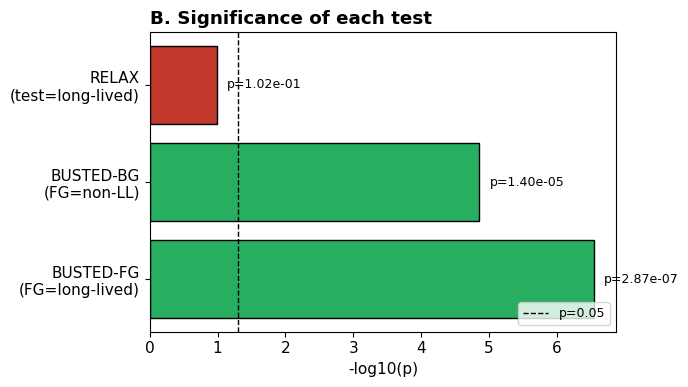

In [28]:
plot_significance(TEST_SUMMARY,
                  save_path=f'{OUTPUT_DIR}/{GENE_NAME}_01_significance.png')

In [29]:
OUTPUT_DIR

'pipeline_results'

Saved: pipeline_results/OR10C1_02_omega3_positive_class.png


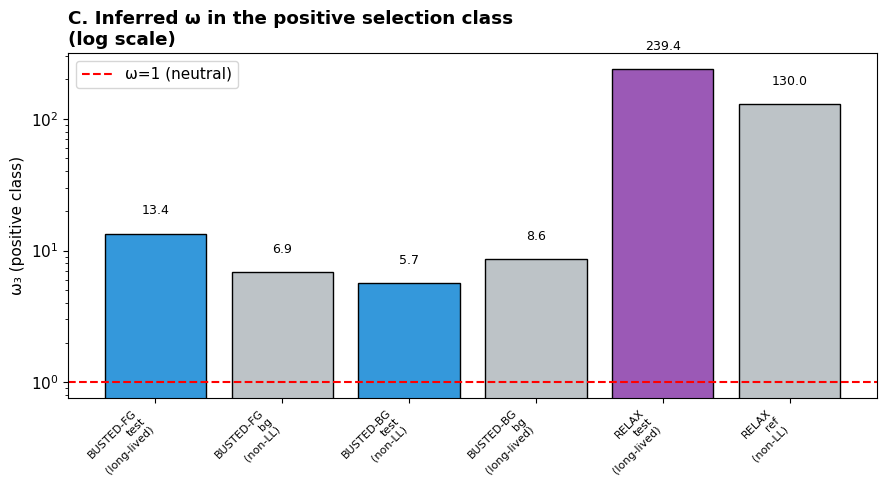

In [30]:
plot_omega3(OMEGA3_DATA,
            save_path=f'{OUTPUT_DIR}/{GENE_NAME}_02_omega3_positive_class.png')

Saved: pipeline_results/OR10C1_03_fingerprint_busted_fg.png


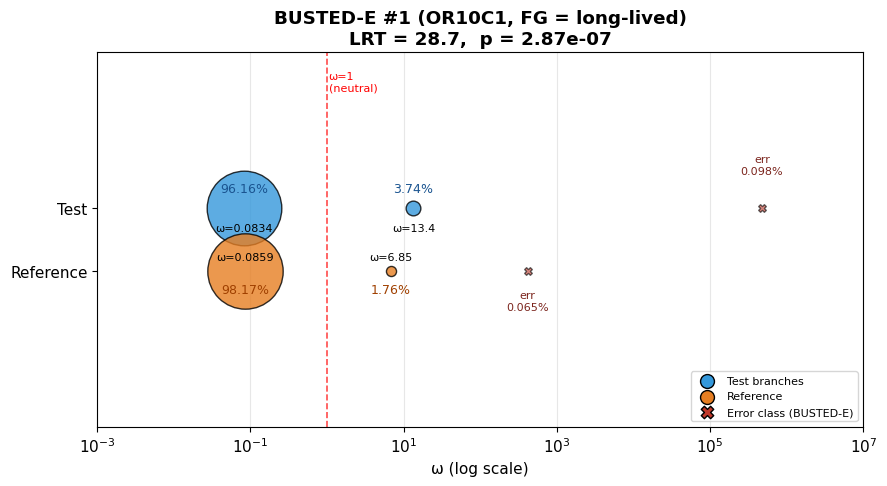

In [31]:
plot_fingerprint(
    BUSTED_FG_TEST, BUSTED_FG_REF,
    title=f'BUSTED-E #1 ({GENE_NAME}, FG = long-lived)\n'
          f'LRT = {fg_raw["LRT"]:.1f},  p = {fg_raw["p"]:.2e}',
    save_path=f'{OUTPUT_DIR}/{GENE_NAME}_03_fingerprint_busted_fg.png',
    ref_label='Reference',
)

# 7. aBSREL Analysis

In [22]:
import os
import time
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

HYPHY_BIN = "/home/poroshina/.conda/envs/based/bin/hyphy"
ABSREL_WORKERS = 4

FILE_SUFFIX = "_bird_only_nucleotide_codon_aligned.fasta"
TREE_SUFFIX = "_bird_only_nucleotide_labeled.nwk"

os.makedirs(DIRS["absrel"], exist_ok=True)

genes_for_absrel = (
    busted_df[busted_df['p_value']<0.05]["gene"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

def run_absrel(gene_name):
    start = time.time()

    codon_file = f"{gene_name}{FILE_SUFFIX}"
    tree_file = f"{gene_name}{TREE_SUFFIX}"

    codon_path = os.path.join(DIRS["pal2nal"], codon_file)
    tree_path = os.path.join(DIRS["labeled_trees"], tree_file)

    if not os.path.exists(codon_path):
        return gene_name, "missing_alignment", codon_path, 0

    if not os.path.exists(tree_path):
        return gene_name, "missing_tree", tree_path, 0

    output_json = os.path.join(DIRS["absrel"], f"{gene_name}_absrel.json")
    output_log = os.path.join(DIRS["absrel"], f"{gene_name}_absrel.log")

    absrel_cmd = [
        HYPHY_BIN,
        "CPU=1",
        "absrel",
        "--alignment",
        codon_path,
        "--tree",
        tree_path,
        "--output",
        output_json,
    ]

    with open(output_log, "w") as log_f:
        result = subprocess.run(
            absrel_cmd,
            stdout=log_f,
            stderr=subprocess.STDOUT
        )

    elapsed_min = (time.time() - start) / 60

    if result.returncode != 0:
        return gene_name, "failed", output_log, elapsed_min

    if not os.path.exists(output_json):
        return gene_name, "no_json", output_log, elapsed_min

    return gene_name, "completed", output_json, elapsed_min

print(f"Running aBSREL on {len(genes_for_absrel)} genes using {ABSREL_WORKERS} workers...")

results = []

with ThreadPoolExecutor(max_workers=ABSREL_WORKERS) as executor:
    futures = {
        executor.submit(run_absrel, gene_name): gene_name
        for gene_name in genes_for_absrel
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="aBSREL"):
        gene_name, status, path, elapsed_min = future.result()
        results.append((gene_name, status, path, elapsed_min))

        if status == "completed":
            done_times = [
                x[3] for x in results
                if x[1] == "completed" and x[3] > 0
            ]
            median_time = sorted(done_times)[len(done_times) // 2]
            remaining = len(genes_for_absrel) - len(results)
            approx_remaining = (remaining / ABSREL_WORKERS) * median_time
            tqdm.write(
                f"Completed {gene_name} in {elapsed_min:.1f} min; "
                f"approx remaining: {approx_remaining:.1f} min"
            )
        else:
            tqdm.write(f"{gene_name}: {status}: {path} after {elapsed_min:.1f} min")

analyses_completed = sum(status == "completed" for _, status, _, _ in results)

print(f"\nCompleted {analyses_completed} aBSREL analyses")

for gene_name, status, path, elapsed_min in results:
    print(f"{gene_name}\t{status}\t{elapsed_min:.2f} min")

Running aBSREL on 17 genes using 4 workers...


aBSREL:   0%|          | 0/17 [00:00<?, ?it/s]

Completed HYI in 29.2 min; approx remaining: 116.8 min


KeyboardInterrupt: 

In [102]:
# =============================================================================
# STEP 9b: ANALYZE aBSREL RESULTS
# =============================================================================
import os
import json
import logging
import pandas as pd

# --- Настройка логирования --------------------------------------------------
# Лог пишется и в консоль, и в файл — чтобы потом можно было разобраться,
# что пошло не так с конкретными генами.
log_path = os.path.join(DIRS['summary'], 'absrel_parsing.log')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.FileHandler(log_path, mode='w'),
        logging.StreamHandler(),
    ],
)
log = logging.getLogger('absrel')

# --- Парсинг ----------------------------------------------------------------
absrel_results = []
stats = {
    'files_total': 0,
    'files_ok': 0,
    'files_failed': 0,
    'branches_total': 0,
    'branches_skipped_no_pvalue': 0,
}

json_files = [f for f in os.listdir(DIRS['absrel']) if f.endswith('.json')]
log.info(f"Найдено {len(json_files)} JSON-файлов в {DIRS['absrel']}")

for json_file in json_files:
    stats['files_total'] += 1
    json_path = os.path.join(DIRS['absrel'], json_file)

    # Извлечение имени гена
    parts = json_file.split('_')
    if parts[0].startswith(('NP', 'XP')):
        gene_name = '_'.join(parts[:2])
    else:
        gene_name = parts[0]

    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError as e:
        log.error(f"[{json_file}] Битый JSON: {e}")
        stats['files_failed'] += 1
        continue
    except OSError as e:
        log.error(f"[{json_file}] Не удалось открыть файл: {e}")
        stats['files_failed'] += 1
        continue

    # Проверяем структуру
    if 'branch attributes' not in data:
        log.warning(f"[{json_file}] Нет ключа 'branch attributes' — пропускаю")
        stats['files_failed'] += 1
        continue

    branch_data = data['branch attributes'].get('0', {})
    if not branch_data:
        log.warning(f"[{json_file}] Пустые branch attributes['0'] — пропускаю")
        stats['files_failed'] += 1
        continue

    branches_in_file = 0
    for branch, attrs in branch_data.items():
        if not isinstance(attrs, dict):
            continue

        # Без p-value тестировать ветвь нет смысла
        if 'Corrected P-value' not in attrs:
            stats['branches_skipped_no_pvalue'] += 1
            continue

        # Rate Distributions: список [[omega, weight], ...] от 1 до 3 классов
        rate_dist = attrs.get('Rate Distributions', []) or []

        # ω+ — самый большой класс ω, его вес — доля сайтов под этим режимом.
        # Именно эта пара характеризует силу положительной селекции на ветви.
        if rate_dist and all(isinstance(rc, (list, tuple)) and len(rc) == 2
                             for rc in rate_dist):
            omega_plus, weight_plus = max(rate_dist, key=lambda x: x[0])
        else:
            omega_plus, weight_plus = None, None
            if rate_dist:
                log.warning(
                    f"[{json_file}|{branch}] Неожиданный формат "
                    f"Rate Distributions: {rate_dist!r}"
                )

        absrel_results.append({
            'gene': gene_name,
            'branch': branch,
            'uncorrected_p': attrs.get('Uncorrected P-value'),
            'corrected_p': attrs.get('Corrected P-value'),
            'baseline_omega': attrs.get('Baseline MG94xREV omega ratio'),
            'omega_plus': omega_plus,         # самый большой ω-класс
            'weight_plus': weight_plus,       # доля сайтов с этим ω
            'rate_classes': attrs.get('Rate classes'),
            'rate_distributions': rate_dist,  # полное распределение
            'LRT': attrs.get('LRT'),
        })
        branches_in_file += 1
        stats['branches_total'] += 1

    log.info(f"[{json_file}] Извлечено {branches_in_file} ветвей (ген: {gene_name})")
    stats['files_ok'] += 1

# --- Сохранение и сводка ----------------------------------------------------
log.info("=" * 60)
log.info(f"Файлов всего:        {stats['files_total']}")
log.info(f"Файлов успешно:      {stats['files_ok']}")
log.info(f"Файлов с ошибкой:    {stats['files_failed']}")
log.info(f"Ветвей извлечено:    {stats['branches_total']}")
log.info(f"Ветвей без p-value:  {stats['branches_skipped_no_pvalue']}")

if absrel_results:
    absrel_df = pd.DataFrame(absrel_results)
    ABSREL_CSV = os.path.join(DIRS['summary'], 'absrel_results.csv')
    absrel_df.to_csv(ABSREL_CSV, index=False)

    n_sig = (absrel_df['corrected_p'] < 0.05).sum()
    n_sig_uncorr = (absrel_df['uncorrected_p'] < 0.05).sum()

    log.info("=" * 60)
    log.info(f"Значимые ветви (corrected_p < 0.05):    {n_sig}")
    log.info(f"Значимые ветви (uncorrected_p < 0.05):  {n_sig_uncorr}")
    log.info(f"Результаты сохранены: {ABSREL_CSV}")
    log.info(f"Лог парсинга:         {log_path}")

    display(absrel_df.sort_values('corrected_p').head(20))
else:
    absrel_df = pd.DataFrame()
    log.warning("Не извлечено ни одной ветви — DataFrame пустой")

16:16:07 [INFO] Найдено 27 JSON-файлов в pipeline_results/09_absrel
16:16:07 [INFO] [SCAMP1_absrel.json] Извлечено 140 ветвей (ген: SCAMP1)
16:16:07 [INFO] [GSTA4_absrel.json] Извлечено 179 ветвей (ген: GSTA4)
16:16:07 [INFO] [CA14_absrel.json] Извлечено 154 ветвей (ген: CA14)
16:16:07 [INFO] [ARHGAP1_absrel.json] Извлечено 180 ветвей (ген: ARHGAP1)
16:16:07 [INFO] [HYI_absrel.json] Извлечено 167 ветвей (ген: HYI)
16:16:07 [INFO] [CD7_absrel.json] Извлечено 51 ветвей (ген: CD7)
16:16:07 [INFO] [PRPF31_absrel.json] Извлечено 59 ветвей (ген: PRPF31)
16:16:07 [INFO] [RGL1_absrel.json] Извлечено 151 ветвей (ген: RGL1)
16:16:07 [INFO] [FCGRT_absrel.json] Извлечено 56 ветвей (ген: FCGRT)
16:16:07 [INFO] [CD59_absrel.json] Извлечено 160 ветвей (ген: CD59)
16:16:07 [INFO] [IFNAR1_absrel.json] Извлечено 182 ветвей (ген: IFNAR1)
16:16:07 [INFO] [ARHGEF7_absrel.json] Извлечено 162 ветвей (ген: ARHGEF7)
16:16:07 [INFO] [RAB18_absrel.json] Извлечено 151 ветвей (ген: RAB18)
16:16:07 [INFO] [ZNF532_a

,gene,branch,uncorrected_p,corrected_p,baseline_omega,omega_plus,weight_plus,rate_classes,rate_distributions,LRT
1457,IFNAR1,Parus_major,0.000000e+00,0.000000e+00,1.240957,621.651778,0.112409,2,"[[0.9768062028889286, 0.8875913948612812], [62...",137.120936
1492,ARHGEF7,Athene_noctua,0.000000e+00,0.000000e+00,0.717324,2540.356350,0.014703,2,"[[0, 0.9852969226999336], [2540.35635037121, 0...",80.192179
1628,ARHGEF7,Rissa_tridactyla,0.000000e+00,0.000000e+00,0.728411,100000.000000,0.014823,2,"[[0, 0.9851765402354382], [99999.99999999693, ...",80.716677
1616,ARHGEF7,Numenius_arquata,0.000000e+00,0.000000e+00,0.774807,3326.690363,0.014642,2,"[[0, 0.9853577817528602], [3326.690363053796, ...",81.148809
1485,ARHGEF7,Aptenodytes_forsteri,0.000000e+00,0.000000e+00,1.523622,6636.862978,0.016787,2,"[[0, 0.9832127328883525], [6636.862978014672, ...",104.808997
1627,ARHGEF7,Pygoscelis_adeliae,0.000000e+00,0.000000e+00,0.664930,2527.240208,0.014732,2,"[[0, 0.985268165432854], [2527.240208223178, 0...",79.202074
1781,RAB18,Strigops_habroptila,0.000000e+00,0.000000e+00,0.921911,163.216535,0.204772,2,"[[0, 0.7952279663231046], [163.2165350353445, ...",107.222279
1572,ARHGEF7,Node156,0.000000e+00,0.000000e+00,0.886565,5086.214374,0.014708,2,"[[0, 0.9852921099659641], [5086.21437391456, 0...",83.085242
1549,ARHGEF7,Node104,0.000000e+00,0.000000e+00,1.097629,6061.712880,0.014681,2,"[[0, 0.9853190659417604], [6061.712880314147, ...",85.918014
1530,ARHGEF7,Haliaeetus_leucocephalus,0.000000e+00,0.000000e+00,1.128853,5734.410661,0.014838,2,"[[0, 0.9851615211256344], [5734.410661311232, ...",86.593773


In [103]:
set(absrel_df['gene'])

{'ARHGAP1',
 'ARHGEF7',
 'ATP5MC1',
 'CA14',
 'CD59',
 'CD7',
 'CPT1B',
 'EPHA6',
 'FCGRT',
 'GALNT7',
 'GSTA4',
 'HLA-DMA',
 'HLA-DRB4',
 'HYI',
 'IFNAR1',
 'KLRD1',
 'MAGI3',
 'OR10C1',
 'PKM',
 'PRPF31',
 'PTBP3',
 'RAB18',
 'RGL1',
 'SCAMP1',
 'SELL',
 'TGOLN2',
 'ZNF532'}

# собираю список генов для дальнейшего анализа 

In [41]:
busted=pd.read_csv('pipeline_results/11_summary/busted_results.csv')
relax=pd.read_csv('pipeline_results/11_summary/relax_results.csv')
relax=relax[relax['p_value']<0.05]
relax=relax[relax['interpretation']=='intensification']
pd.concat([busted, relax])['gene'].to_csv("fitmg94_genes.csv",index=False)

# 8. FitMG94 Lineage Analysis

In [104]:
# =============================================================================
# STEP 10b: ANALYZE FitMG94 RESULTS
# =============================================================================

import os
import json
import pandas as pd

fitmg94_results = []

FITMG94_SUFFIX = "_bird_only_nucleotide_codon_aligned_fitmg94.json"

for json_file in os.listdir(DIRS["fitmg94"]):
    if not json_file.endswith(".json"):
        continue

    json_path = os.path.join(DIRS["fitmg94"], json_file)

    try:
        with open(json_path, "r") as f:
            data = json.load(f)

        # Extract gene name
        if json_file.endswith(FITMG94_SUFFIX):
            gene_name = json_file.replace(FITMG94_SUFFIX, "")
        else:
            gene_name = json_file.replace("_fitmg94.json", "").replace(".json", "")

        # Main FitMG94 branch attributes block
        if "branch attributes" not in data:
            print(f"[SKIP] No branch attributes in {json_file}")
            continue

        if "0" not in data["branch attributes"]:
            print(f"[SKIP] No partition '0' in branch attributes: {json_file}")
            continue

        branch_data = data["branch attributes"]["0"]

        for branch, attrs in branch_data.items():
            if not isinstance(attrs, dict):
                continue

            # Skip internal nodes
            if branch.startswith("Node"):
                continue

            omega = attrs.get("Lineage dN/dS")
            dN = attrs.get("dN")
            dS = attrs.get("dS")

            ci = attrs.get("Confidence Intervals", {})
            omega_lb = ci.get("LB")
            omega_mle = ci.get("MLE")
            omega_ub = ci.get("UB")

            result_dict = {
                "gene": gene_name,
                "branch": branch,
                "original_name": attrs.get("original name", branch),

                "omega": omega,
                "omega_ci_lb": omega_lb,
                "omega_ci_mle": omega_mle,
                "omega_ci_ub": omega_ub,

                "dN": dN,
                "dS": dS,

                "nonsynonymous": attrs.get("nonsynonymous"),
                "synonymous": attrs.get("synonymous"),

                "standard_mg94_branch_length": attrs.get("Standard MG94"),
                "nucleotide_gtr_branch_length": attrs.get("Nucleotide GTR"),

                "json_file": json_file,
            }

            fitmg94_results.append(result_dict)

    except json.JSONDecodeError as e:
        print(f"[BAD JSON] {json_file}: {e}")

    except Exception as e:
        print(f"[ERROR] {json_file}: {e}")

if fitmg94_results:
    fitmg94_df = pd.DataFrame(fitmg94_results)

    # Convert numeric columns
    numeric_cols = [
        "omega",
        "omega_ci_lb",
        "omega_ci_mle",
        "omega_ci_ub",
        "dN",
        "dS",
        "nonsynonymous",
        "synonymous",
        "standard_mg94_branch_length",
        "nucleotide_gtr_branch_length",
    ]

    for col in numeric_cols:
        if col in fitmg94_df.columns:
            fitmg94_df[col] = pd.to_numeric(fitmg94_df[col], errors="coerce")

    os.makedirs(DIRS["summary"], exist_ok=True)

    FITMG94_CSV = os.path.join(DIRS["summary"], "fitmg94_results.csv")
    fitmg94_df.to_csv(FITMG94_CSV, index=False)

    print("FitMG94 Results Summary:")
    print(f"  Total tip branches analyzed: {len(fitmg94_df)}")
    print(f"  Total genes parsed: {fitmg94_df['gene'].nunique()}")

    valid_omega = fitmg94_df[fitmg94_df["omega"].notna()]

    if len(valid_omega) > 0:
        print(f"  Branches with valid omega: {len(valid_omega)}")
        print(f"  Branches with omega > 1: {len(valid_omega[valid_omega['omega'] > 1])}")
        print(f"  Mean omega: {valid_omega['omega'].mean():.4f}")
        print(f"  Median omega: {valid_omega['omega'].median():.4f}")
        print(f"  Max omega: {valid_omega['omega'].max():.4f}")
    else:
        print("  No valid omega values found")

    print(f"\nResults saved to: {FITMG94_CSV}")

    display(
        fitmg94_df
        .sort_values("omega", ascending=False)
        .head(20)
    )

else:
    fitmg94_df = pd.DataFrame()
    print("No FitMG94 results to analyze")

FitMG94 Results Summary:
  Total tip branches analyzed: 6992
  Total genes parsed: 77
  Branches with valid omega: 6992
  Branches with omega > 1: 30
  Mean omega: 0.1539
  Median omega: 0.0972
  Max omega: 67.4652

Results saved to: pipeline_results/11_summary/fitmg94_results.csv


,gene,branch,original_name,omega,omega_ci_lb,omega_ci_mle,omega_ci_ub,dN,dS,nonsynonymous,synonymous,standard_mg94_branch_length,nucleotide_gtr_branch_length,json_file
3123,GP5,Dromaius_novaehollandiae,Dromaius_novaehollandiae,67.465211,39.898400,67.465211,107.714952,1.543408e-01,4.067960e-10,1.164002e-01,1.000000e-10,0.116400,0.097912,GP5_bird_only_nucleotide_codon_aligned_fitmg94...
2250,HLA-DRB4,Nipponia_nippon,Nipponia_nippon,3.784805,2.460200,3.784805,5.538945,8.943523e-02,2.252677e-02,7.057816e-02,4.749683e-03,0.075328,0.083011,HLA-DRB4_bird_only_nucleotide_codon_aligned_fi...
6247,CD7,Anas_acuta,Anas_acuta,2.649862,1.953092,2.649862,3.517692,1.282148e-10,4.544237e-10,1.000000e-10,1.000000e-10,0.000000,0.000000,CD7_bird_only_nucleotide_codon_aligned_fitmg94...
2200,HLA-DRB4,Aptenodytes_patagonicus,Aptenodytes_patagonicus,2.541131,1.572144,2.541131,3.860368,7.070865e-02,2.595917e-02,5.580000e-02,5.473391e-03,0.061273,0.065670,HLA-DRB4_bird_only_nucleotide_codon_aligned_fi...
6248,CD7,Anas_platyrhynchos,Anas_platyrhynchos,2.350786,1.749319,2.350786,3.093835,9.076789e-03,1.003559e-02,7.079360e-03,2.208422e-03,0.009288,0.009326,CD7_bird_only_nucleotide_codon_aligned_fitmg94...
407,KLRD1,Apteryx_rowi,Apteryx_rowi,1.973859,0.800395,1.973859,3.878157,5.093909e-02,2.887628e-02,3.975580e-02,6.339569e-03,0.046095,0.054393,KLRD1_bird_only_nucleotide_codon_aligned_fitmg...
5435,CD244,Haliaeetus_albicilla,Haliaeetus_albicilla,1.478224,1.176644,1.478224,1.822545,2.376565e-02,3.326002e-02,1.775364e-02,8.413803e-03,0.026167,0.025343,CD244_bird_only_nucleotide_codon_aligned_fitmg...
2203,HLA-DRB4,Aquila_chrysaetos,Aquila_chrysaetos,1.366362,0.857541,1.366362,2.044219,7.324990e-02,4.742794e-10,5.780544e-02,1.000000e-10,0.057805,0.046876,HLA-DRB4_bird_only_nucleotide_codon_aligned_fi...
6260,CD7,Empidonax_traillii,Empidonax_traillii,1.355298,1.063683,1.355298,1.705167,1.548321e-01,6.014695e-02,1.207599e-01,1.323588e-02,0.133996,0.129642,CD7_bird_only_nucleotide_codon_aligned_fitmg94...
5894,NIPSNAP3B,Dromaius_novaehollandiae,Dromaius_novaehollandiae,1.352023,0.538532,1.352023,2.734991,3.162200e-02,3.364131e-02,2.440842e-02,7.674221e-03,0.032083,0.032821,NIPSNAP3B_bird_only_nucleotide_codon_aligned_f...


# 9. PGLS Analysis with phylokrr

In [107]:
# =============================================================================
# PGLS PER GENE: LQ ~ omega
# Fast version:
#   1) precomputes full VCV once
#   2) for each gene takes VCV submatrix
#   3) runs per-gene PGLS in parallel on 4 cores
# =============================================================================

import os

# ВАЖНО: чтобы 4 процесса не начали каждый использовать много потоков BLAS
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from ete3 import Tree
from scipy.stats import t as t_dist
from tqdm.auto import tqdm

# =========================
# PATHS
# =========================
OUTPUT_DIR = "pipeline_results"
SUMMARY_DIR = os.path.join(OUTPUT_DIR, "11_summary")
os.makedirs(SUMMARY_DIR, exist_ok=True)

FITMG94_CSV = os.path.join(SUMMARY_DIR, "fitmg94_results.csv")

BIRD_INFO_FILE = "featured_and_annotated_birds.csv"
SPECIES_TREE_FILE = "pruned_tree.nwk"

OUT_CSV = os.path.join(SUMMARY_DIR, "pgls_lq_vs_omega_per_gene.csv")

# =========================
# SETTINGS
# =========================
N_WORKERS = 4
MIN_SPECIES = 31

# =========================
# LOAD DATA
# =========================
fitmg94 = pd.read_csv(FITMG94_CSV)
bird_info = pd.read_csv(BIRD_INFO_FILE)

print("FitMG94 shape:", fitmg94.shape)
print("FitMG94 columns:", list(fitmg94.columns))

print("Bird info shape:", bird_info.shape)
print("Bird info columns:", list(bird_info.columns))

# =========================
# PREPARE BIRD INFO / LQ TABLE
# =========================
required_bird_cols = ["Genus", "Species", "LQ"]
missing = [c for c in required_bird_cols if c not in bird_info.columns]
if missing:
    raise ValueError(f"Missing columns in bird info file: {missing}")

bird_info["species"] = (
    bird_info["Genus"].astype(str).str.strip()
    + "_"
    + bird_info["Species"].astype(str).str.strip()
)

bird_lq = (
    bird_info[["species", "LQ"]]
    .dropna(subset=["species", "LQ"])
    .drop_duplicates(subset=["species"])
    .copy()
)

bird_lq["LQ"] = pd.to_numeric(bird_lq["LQ"], errors="coerce")
bird_lq = bird_lq.dropna(subset=["LQ"]).copy()

print(f"\nBird species with LQ: {len(bird_lq)}")
print(bird_lq.head())

# =========================
# PREPARE FITMG94 TABLE
# =========================
required_fit_cols = ["gene", "omega"]
missing = [c for c in required_fit_cols if c not in fitmg94.columns]
if missing:
    raise ValueError(f"Missing columns in FitMG94 results: {missing}")

if "original_name" in fitmg94.columns:
    fit_species_col = "original_name"
elif "branch" in fitmg94.columns:
    fit_species_col = "branch"
else:
    raise ValueError("Need either 'original_name' or 'branch' column in FitMG94 results")

fitmg94["species"] = (
    fitmg94[fit_species_col]
    .astype(str)
    .str.strip()
    .str.replace(" ", "_", regex=False)
)

fitmg94 = fitmg94.dropna(subset=["gene", "species", "omega"]).copy()
fitmg94["omega"] = pd.to_numeric(fitmg94["omega"], errors="coerce")
fitmg94 = fitmg94.dropna(subset=["omega"]).copy()

print(f"\nFitMG94 rows after cleaning: {len(fitmg94)}")
print(f"Genes: {fitmg94['gene'].nunique()}")
print(f"Species in FitMG94: {fitmg94['species'].nunique()}")

# =========================
# LOAD SPECIES TREE
# =========================
tree = Tree(SPECIES_TREE_FILE, format=1)

for leaf in tree:
    leaf.name = leaf.name.strip().replace(" ", "_")

tree_species = set(leaf.name for leaf in tree)

print(f"\nSpecies tree leaves: {len(tree_species)}")
print("Example tree leaves:", sorted(list(tree_species))[:10])

# =========================
# DIAGNOSTICS BEFORE PGLS
# =========================
fit_species = set(fitmg94["species"])
lq_species = set(bird_lq["species"])

print("\nOverlap diagnostics:")
print("  FitMG94 ∩ LQ:", len(fit_species & lq_species))
print("  FitMG94 ∩ tree:", len(fit_species & tree_species))
print("  LQ ∩ tree:", len(lq_species & tree_species))
print("  FitMG94 ∩ LQ ∩ tree:", len(fit_species & lq_species & tree_species))

print("\nExamples: species in FitMG94 but not in LQ:")
print(sorted(list(fit_species - lq_species))[:20])

print("\nExamples: species in FitMG94 but not in tree:")
print(sorted(list(fit_species - tree_species))[:20])

# =========================
# HELPER FUNCTIONS
# =========================
def safe_inverse(matrix, ridge=1e-8):
    matrix = np.asarray(matrix, dtype=float)
    matrix = matrix + np.eye(matrix.shape[0]) * ridge

    try:
        return np.linalg.inv(matrix)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(matrix)


def make_vcv_from_tree(tree_obj, species_list):
    """
    Brownian-motion phylogenetic covariance matrix.
    VCV[i, j] = shared path length from root to MRCA(i, j).
    Diagonal = root-to-tip distance.
    """
    n = len(species_list)
    vcv = np.zeros((n, n), dtype=float)

    root = tree_obj.get_tree_root()

    for i, sp1 in enumerate(tqdm(species_list, desc="Building full VCV")):
        for j in range(i, n):
            sp2 = species_list[j]

            if i == j:
                value = tree_obj.get_distance(root, sp1)
            else:
                mrca = tree_obj.get_common_ancestor(sp1, sp2)
                value = tree_obj.get_distance(root, mrca)

            vcv[i, j] = value
            vcv[j, i] = value

    return vcv


# =========================
# PRECOMPUTE FULL VCV ONCE
# =========================
all_possible_species = sorted(list(
    set(fitmg94["species"]) &
    set(bird_lq["species"]) &
    tree_species
))

print(f"\nSpecies used for full VCV: {len(all_possible_species)}")

if len(all_possible_species) < MIN_SPECIES:
    raise ValueError(
        f"Only {len(all_possible_species)} species overlap between FitMG94, LQ, and tree. "
        f"This is less than MIN_SPECIES={MIN_SPECIES}."
    )

tree_for_vcv = tree.copy()
tree_for_vcv.prune(all_possible_species, preserve_branch_length=True)

full_vcv = make_vcv_from_tree(tree_for_vcv, all_possible_species)

if not np.isfinite(full_vcv).all():
    raise ValueError("Full VCV contains non-finite values.")

if np.allclose(np.diag(full_vcv), 0):
    raise ValueError(
        "VCV diagonal is all zeros. Your species tree may not have branch lengths."
    )

species_to_vcv_idx = {
    sp: i for i, sp in enumerate(all_possible_species)
}

print("Full VCV shape:", full_vcv.shape)

# =========================
# PGLS FOR ONE GENE
# =========================
def run_pgls_single_gene(gene_name, gene_df, min_species=31):
    """
    Runs PGLS for one gene:
        LQ ~ omega

    Uses a precomputed full VCV and extracts a submatrix for this gene's species.
    """

    species_omega = (
        gene_df
        .groupby("species", as_index=False)["omega"]
        .mean()
    )

    merged = species_omega.merge(
        bird_lq,
        on="species",
        how="inner"
    ).dropna(subset=["omega", "LQ"])

    species_available = set(merged["species"])
    species_in_all = sorted(list(species_available & set(all_possible_species)))

    if len(species_in_all) < min_species:
        return {
            "gene": gene_name,
            "status": "skipped_not_enough_species",
            "n_species": len(species_in_all),
            "intercept": np.nan,
            "omega_coef": np.nan,
            "omega_se": np.nan,
            "t_stat": np.nan,
            "df": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan,
            "adj_r_squared": np.nan,
        }

    data = (
        merged[merged["species"].isin(species_in_all)]
        .sort_values("species")
        .reset_index(drop=True)
    )

    species_list = data["species"].tolist()
    n = len(species_list)

    y = data["LQ"].values.astype(float)
    X = data[["omega"]].values.astype(float)

    # Fast VCV: take submatrix from precomputed full VCV
    idx = [species_to_vcv_idx[sp] for sp in species_list]
    vcv = full_vcv[np.ix_(idx, idx)]
    vcv_inv = safe_inverse(vcv)

    # Design matrix: intercept + omega
    X_design = np.column_stack([np.ones(n), X])
    k = X_design.shape[1]
    rdf = n - k

    if rdf <= 0:
        return {
            "gene": gene_name,
            "status": "skipped_nonpositive_df",
            "n_species": n,
            "intercept": np.nan,
            "omega_coef": np.nan,
            "omega_se": np.nan,
            "t_stat": np.nan,
            "df": rdf,
            "p_value": np.nan,
            "r_squared": np.nan,
            "adj_r_squared": np.nan,
        }

    # GLS beta = (X' V^-1 X)^-1 X' V^-1 y
    XtVinv = X_design.T @ vcv_inv
    XtVinvX = XtVinv @ X_design

    try:
        XtVinvX_inv = np.linalg.inv(XtVinvX)
    except np.linalg.LinAlgError:
        XtVinvX_inv = np.linalg.pinv(XtVinvX)

    beta = XtVinvX_inv @ (XtVinv @ y)

    y_pred = X_design @ beta
    residuals = y - y_pred

    sigma2 = float(residuals.T @ vcv_inv @ residuals) / rdf

    cov_beta = XtVinvX_inv * sigma2
    se = np.sqrt(np.diag(cov_beta))

    intercept = float(beta[0])
    omega_coef = float(beta[1])
    omega_se = float(se[1])

    if omega_se == 0 or not np.isfinite(omega_se):
        t_stat = np.nan
        p_value = np.nan
    else:
        t_stat = omega_coef / omega_se
        p_value = 2 * (1 - t_dist.cdf(abs(t_stat), rdf))

    # Caper-style R²
    X_null = np.ones((n, 1))
    XtVinv_null = X_null.T @ vcv_inv

    try:
        beta_null = np.linalg.inv(XtVinv_null @ X_null) @ (XtVinv_null @ y)
    except np.linalg.LinAlgError:
        beta_null = np.linalg.pinv(XtVinv_null @ X_null) @ (XtVinv_null @ y)

    residuals_null = y - X_null @ beta_null

    NMS = float(residuals_null.T @ vcv_inv @ residuals_null) / (n - 1)
    NSSQ = NMS * (n - 1)

    RMS = sigma2
    RSSQ = RMS * rdf

    if NSSQ == 0 or NMS == 0:
        r_squared = np.nan
        adj_r_squared = np.nan
    else:
        r_squared = (NSSQ - RSSQ) / NSSQ
        adj_r_squared = (NMS - RMS) / NMS

    return {
        "gene": gene_name,
        "status": "ok",
        "n_species": n,
        "intercept": intercept,
        "omega_coef": omega_coef,
        "omega_se": omega_se,
        "t_stat": t_stat,
        "df": rdf,
        "p_value": p_value,
        "r_squared": r_squared,
        "adj_r_squared": adj_r_squared,
    }


# =========================
# RUN PGLS PER GENE WITH JOBLIB + TQDM
# =========================
try:
    from joblib import Parallel, delayed
except ImportError:
    raise ImportError(
        "joblib is not installed. Install it with:\n"
        "conda install -c conda-forge joblib -y\n"
        "or\n"
        "python -m pip install joblib"
    )

gene_tasks = [
    (gene_name, gene_df.copy())
    for gene_name, gene_df in fitmg94.groupby("gene")
]

print(f"\nRunning PGLS for {len(gene_tasks)} genes using {N_WORKERS} workers...")
print(f"MIN_SPECIES = {MIN_SPECIES}")

def run_pgls_task(task):
    gene_name, gene_df = task

    try:
        return run_pgls_single_gene(
            gene_name=gene_name,
            gene_df=gene_df,
            min_species=MIN_SPECIES
        )

    except Exception as e:
        return {
            "gene": gene_name,
            "status": f"error: {type(e).__name__}: {e}",
            "n_species": np.nan,
            "intercept": np.nan,
            "omega_coef": np.nan,
            "omega_se": np.nan,
            "t_stat": np.nan,
            "df": np.nan,
            "p_value": np.nan,
            "r_squared": np.nan,
            "adj_r_squared": np.nan,
        }

results = Parallel(n_jobs=N_WORKERS, backend="loky")(
    delayed(run_pgls_task)(task)
    for task in tqdm(gene_tasks, desc="PGLS per gene")
)

pgls_results = pd.DataFrame(results)

# =========================
# MULTIPLE TESTING CORRECTION
# =========================
ok_mask = pgls_results["status"].eq("ok") & pgls_results["p_value"].notna()

pgls_results["p_fdr_bh"] = np.nan

if ok_mask.sum() > 0:
    try:
        from statsmodels.stats.multitest import multipletests

        _, qvals, _, _ = multipletests(
            pgls_results.loc[ok_mask, "p_value"].values,
            method="fdr_bh"
        )

        pgls_results.loc[ok_mask, "p_fdr_bh"] = qvals

    except ImportError:
        print("statsmodels not installed, skipping FDR correction")

# =========================
# SAVE RESULTS
# =========================
pgls_results = pgls_results.sort_values(
    ["status", "p_value"],
    na_position="last"
).reset_index(drop=True)

pgls_results.to_csv(OUT_CSV, index=False)

print("\n" + "=" * 80)
print("PGLS PER-GENE ANALYSIS FINISHED")
print("=" * 80)
print(f"Total genes: {len(pgls_results)}")
print(f"OK genes: {(pgls_results['status'] == 'ok').sum()}")
print(f"Skipped/error genes: {(pgls_results['status'] != 'ok').sum()}")
print(f"Saved to: {OUT_CSV}")

print("\nTop genes by raw p-value:")
display(
    pgls_results[pgls_results["status"] == "ok"]
    .sort_values("p_value")
    .head(30)
)

FitMG94 shape: (6992, 14)
FitMG94 columns: ['gene', 'branch', 'original_name', 'omega', 'omega_ci_lb', 'omega_ci_mle', 'omega_ci_ub', 'dN', 'dS', 'nonsynonymous', 'synonymous', 'standard_mg94_branch_length', 'nucleotide_gtr_branch_length', 'json_file']
Bird info shape: (183, 25)
Bird info columns: ['Assembly Accession', 'Assembly Name', 'Organism Taxonomic ID', 'Genus', 'Species', 'Adult weight (g)', 'Birth weight (g)', 'Female maturity (days)', 'Gestation/Incubation (days)', 'Litter/Clutch size', 'Litters/Clutches per year', 'Male maturity (days)', 'Maximum longevity (yrs)', 'Weaning (days)', 'brain.mass', 'dev.mode', 'egg.mass', 'egg_mass_g', 'fledging.age', 'fledging_age_d', 'refseq_anootated', 'LQ', 'LQ_group', 'Specimen origin', 'LQ_threshold']

Bird species with LQ: 183
               species        LQ
0   Anas_platyrhynchos  1.266340
1  Taeniopygia_guttata  1.214389
2        Gallus_gallus  1.380465
3    Coturnix_japonica  0.396286
4      Anser_cygnoides  1.075807

FitMG94 rows a

Building full VCV:   0%|          | 0/107 [00:00<?, ?it/s]

Full VCV shape: (107, 107)

Running PGLS for 77 genes using 4 workers...
MIN_SPECIES = 31


PGLS per gene:   0%|          | 0/77 [00:00<?, ?it/s]


PGLS PER-GENE ANALYSIS FINISHED
Total genes: 77
OK genes: 72
Skipped/error genes: 5
Saved to: pipeline_results/11_summary/pgls_lq_vs_omega_per_gene.csv

Top genes by raw p-value:


,gene,status,n_species,intercept,omega_coef,omega_se,t_stat,df,p_value,r_squared,adj_r_squared,p_fdr_bh
0,NECTIN3,ok,103,0.584143,3.319735,0.707309,4.693475,101.0,0.000008,0.179053,0.170925,0.000609
1,MAGI3,ok,105,-0.505352,10.055205,2.715650,3.702688,103.0,0.000345,0.117470,0.108902,0.011941
2,EBNA1BP2,ok,102,0.068793,3.378726,0.938587,3.599801,100.0,0.000498,0.114720,0.105867,0.011941
3,RRBP1,ok,97,2.550978,-8.008926,2.965159,-2.701011,95.0,0.008186,0.071318,0.061542,0.147356
4,ZBTB8OS,ok,103,0.876396,1.850100,0.854359,2.165483,101.0,0.032705,0.044369,0.034907,0.470950
5,SCAMP1,ok,101,0.954398,2.259379,1.154204,1.957521,99.0,0.053102,0.037264,0.027539,0.637222
6,RAB18,ok,99,0.991409,2.108068,1.298953,1.622898,97.0,0.107857,0.026435,0.016398,0.780175
7,ARHGEF7,ok,92,0.892529,2.343139,1.484577,1.578321,90.0,0.118000,0.026933,0.016122,0.780175
8,CA14,ok,101,1.131793,-0.561373,0.359777,-1.560339,99.0,0.121871,0.024002,0.014144,0.780175
9,PRPF31,ok,43,1.103820,0.949418,0.604888,1.569577,41.0,0.124200,0.056681,0.033674,0.780175


In [201]:
pgls_results[pgls_results['gene']=='GALNT7']

,gene,status,n_species,intercept,omega_coef,omega_se,t_stat,df,p_value,r_squared,adj_r_squared,p_fdr_bh
59,GALNT7,ok,102,1.013026,0.164629,1.067754,0.154182,100.0,0.877777,0.000238,-0.00976,0.987706


In [202]:
# =============================================================================
# PLOTS FOR PGLS RESULTS
# =============================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

PLOTS_DIR = os.path.join(SUMMARY_DIR, "pgls_plots_per_gene")
os.makedirs(PLOTS_DIR, exist_ok=True)

# =========================
# 1) SUMMARY PLOT: effect size vs significance
# =========================
plot_df = pgls_results[
    (pgls_results["status"] == "ok") &
    pgls_results["p_value"].notna() &
    (pgls_results["gene"] == "GALNT7")
    np.isfinite(pgls_results["p_value"])
].copy()

plot_df["minus_log10_p"] = -np.log10(plot_df["p_value"])

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_df["omega_coef"],
    plot_df["minus_log10_p"],
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

plt.axhline(-np.log10(0.05), linestyle="--", linewidth=1, label="p = 0.05")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("PGLS coefficient for omega")
plt.ylabel("-log10(p-value)")
plt.title("Per-gene PGLS: LQ ~ omega")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

summary_plot_file = os.path.join(PLOTS_DIR, "pgls_summary_coef_vs_pvalue.png")
plt.savefig(summary_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved summary plot: {summary_plot_file}")


# =========================
# 2) SCATTER PLOTS FOR TOP GENES
# =========================
TOP_N = 20  # поменяй, если хочешь больше/меньше

top_genes = (
    plot_df
    .sort_values("p_value")
    .head(TOP_N)["gene"]
    .tolist()
)

def clean_filename(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))

for gene_name in top_genes:
    gene_df = fitmg94[fitmg94["gene"] == gene_name].copy()

    species_omega = (
        gene_df
        .groupby("species", as_index=False)["omega"]
        .mean()
    )

    merged = species_omega.merge(
        bird_lq,
        on="species",
        how="inner"
    ).dropna(subset=["omega", "LQ"])

    species_in_all = sorted(list(set(merged["species"]) & tree_species))

    if len(species_in_all) < 4:
        continue

    data = (
        merged[merged["species"].isin(species_in_all)]
        .sort_values("species")
        .reset_index(drop=True)
    )

    res_row = pgls_results[pgls_results["gene"] == gene_name].iloc[0]

    intercept = res_row["intercept"]
    coef = res_row["omega_coef"]
    p_value = res_row["p_value"]
    r_squared = res_row["r_squared"]
    n_species = res_row["n_species"]

    x = data["omega"].values
    y = data["LQ"].values

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + coef * x_line

    plt.figure(figsize=(8, 6))

    plt.scatter(
        x,
        y,
        alpha=0.75,
        s=70,
        edgecolors="black",
        linewidth=0.7
    )

    plt.plot(
        x_line,
        y_line,
        linestyle="--",
        linewidth=2,
        label="PGLS fitted line"
    )

    plt.xlabel("Omega (ω)")
    plt.ylabel("Longevity Quotient (LQ)")
    plt.title(
        f"{gene_name}: PGLS LQ ~ omega\n"
        f"n = {n_species}, p = {p_value:.3e}, R² = {r_squared:.3f}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_file = os.path.join(
        PLOTS_DIR,
        f"pgls_lq_vs_omega_{clean_filename(gene_name)}.png"
    )

    plt.savefig(plot_file, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {plot_file}")

SyntaxError: invalid syntax (867445784.py, line 20)

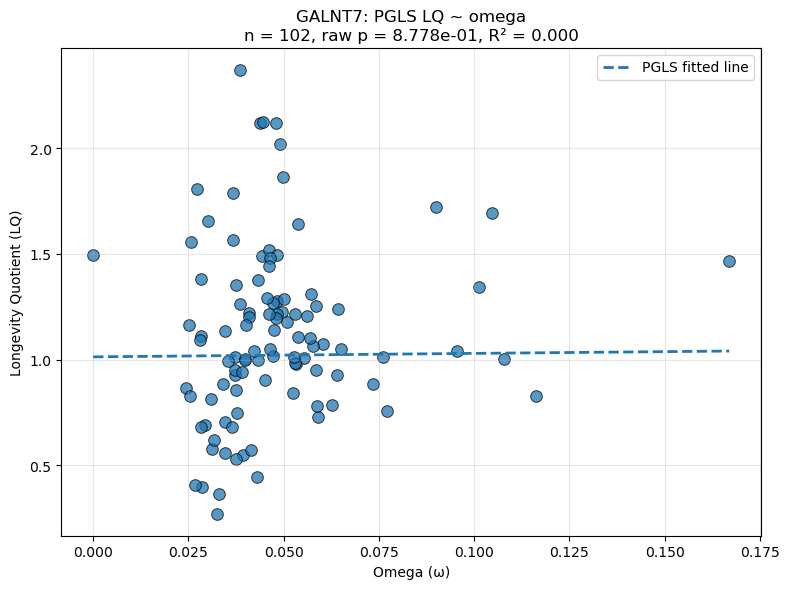

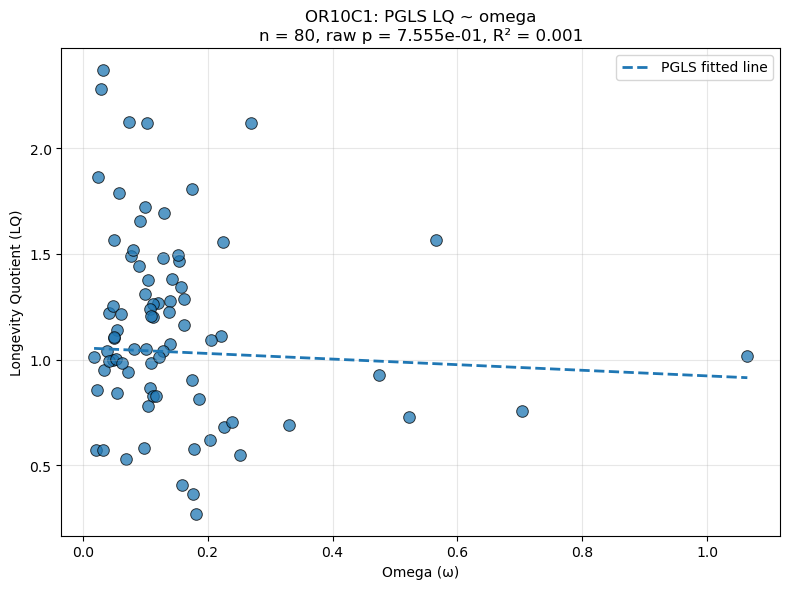

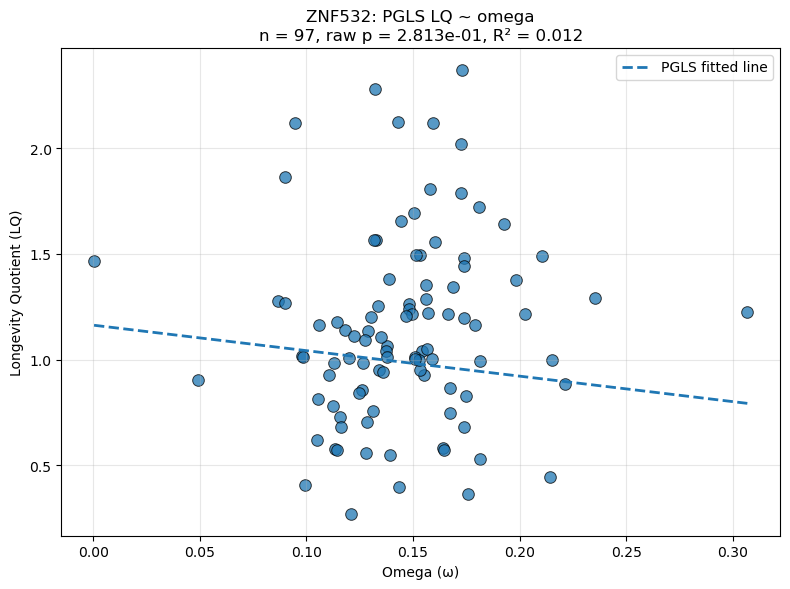

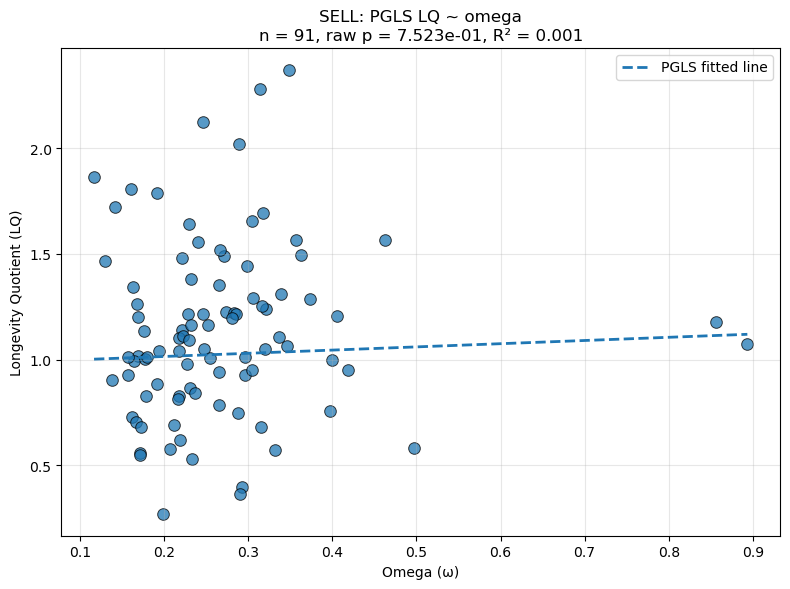

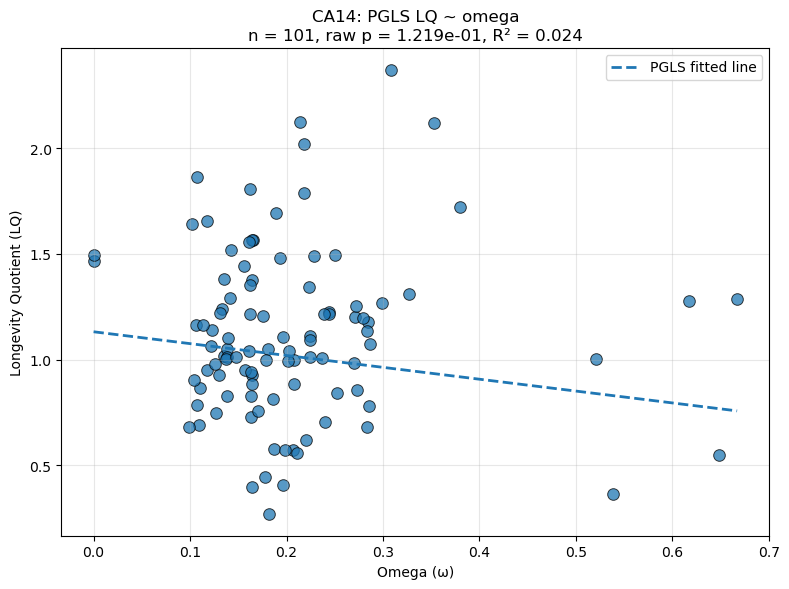

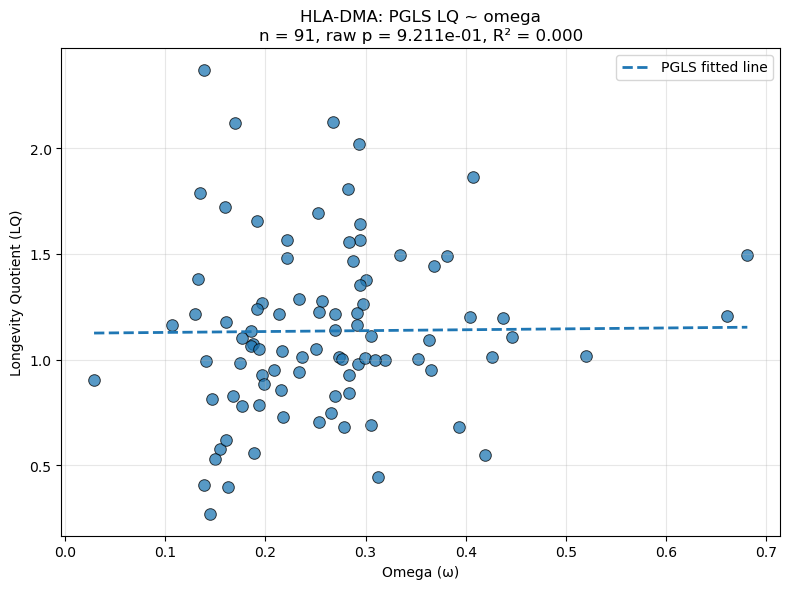

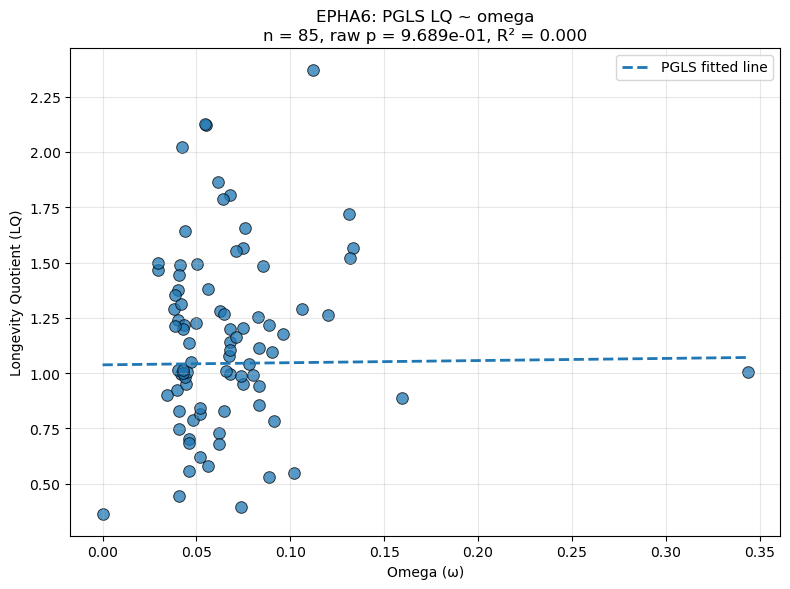

In [180]:
# =========================
# SCATTER PLOTS FOR SELECTED GENES
# =========================

GENES_TO_PLOT = [
    "GALNT7",
    "OR10C1",
    "ZNF532",
    "SELL",
    "CA14",
    "HLA-DMA",
    "EPHA6",
]

for gene_name in GENES_TO_PLOT:
    if gene_name not in set(fitmg94["gene"]):
        print(f"Skipped {gene_name}: not found in FitMG94 table")
        continue

    if gene_name not in set(pgls_results["gene"]):
        print(f"Skipped {gene_name}: not found in PGLS results")
        continue

    res_row = pgls_results[pgls_results["gene"] == gene_name].iloc[0]

    if res_row["status"] != "ok":
        print(f"Skipped {gene_name}: PGLS status = {res_row['status']}")
        continue

    gene_df = fitmg94[fitmg94["gene"] == gene_name].copy()

    species_omega = (
        gene_df
        .groupby("species", as_index=False)["omega"]
        .mean()
    )

    merged = species_omega.merge(
        bird_lq,
        on="species",
        how="inner"
    ).dropna(subset=["omega", "LQ"])

    species_in_all = sorted(list(set(merged["species"]) & tree_species))

    if len(species_in_all) < 4:
        print(f"Skipped {gene_name}: too few species for plotting")
        continue

    data = (
        merged[merged["species"].isin(species_in_all)]
        .sort_values("species")
        .reset_index(drop=True)
    )

    intercept = res_row["intercept"]
    coef = res_row["omega_coef"]
    raw_p_value = res_row["p_value"]
    r_squared = res_row["r_squared"]
    n_species = int(res_row["n_species"])

    x = data["omega"].values
    y = data["LQ"].values

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + coef * x_line

    plt.figure(figsize=(8, 6))

    plt.scatter(
        x,
        y,
        alpha=0.75,
        s=70,
        edgecolors="black",
        linewidth=0.7
    )

    plt.plot(
        x_line,
        y_line,
        linestyle="--",
        linewidth=2,
        label="PGLS fitted line"
    )

    plt.xlabel("Omega (ω)")
    plt.ylabel("Longevity Quotient (LQ)")
    plt.title(
        f"{gene_name}: PGLS LQ ~ omega\n"
        f"n = {n_species}, raw p = {raw_p_value:.3e}, R² = {r_squared:.3f}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 101. вырезаю аутлайеров и перезапускаю без них 

In [28]:
# хочется вырезать три вида--
NWK_FILE = "pipeline_results/07_labeled_trees/OR10C1_bird_only_nucleotide_labeled.nwk"

full_tree = Tree(NWK_FILE, format=1)
full_tree.

Type:        TreeNode
String form:
           /-Struthio_camelus{Background}
           /-|
           |  |   /-Dromaius_novaehollandiae{Background}
           |  <...>     \-Molothrus_ater{Background}
           |
           \-Falco_cherrug{Background}
Length:      80
File:        ~/.conda/envs/based/lib/python3.9/site-packages/ete3/coretype/tree.py
Docstring:  
TreeNode (Tree) class is used to store a tree structure. A tree
consists of a collection of TreeNode instances connected in a
hierarchical way. Trees can be loaded from the New Hampshire Newick
format (newick).

:argument newick: Path to the file containing the tree or, alternatively,
   the text string containing the same information.

:argument 0 format: subnewick format

  .. table::

      ======  ==============================================
      FORMAT  DESCRIPTION
      ======  ==============================================
      0        flexible with support values
      1        flexible with internal node names
  

In [30]:
from pathlib import Path
from ete3 import Tree
from Bio import SeqIO

TREE_FILE = Path("pipeline_results/07_labeled_trees/OR10C1_bird_only_nucleotide_labeled.nwk")
ALIGNMENT_FILE = Path("pipeline_results/05_pal2nal_normalized_no_duplicates/OR10C1_bird_only_nucleotide_codon_aligned.fasta")

REMOVE_VARIANTS = {
    "without_apteryx": {
        "Apteryx_mantelli",
        "Apteryx_rowi",
    },
    "without_apteryx_strigops": {
        "Apteryx_mantelli",
        "Apteryx_rowi",
        "Strigops_habroptila",
    },
}

def normalize_species_name(name):
    name = str(name).strip().replace(" ", "_")
    if "{" in name:
        name = name.split("{")[0]
    return name

def save_pruned_tree(tree_file, species_to_remove, suffix):
    tree = Tree(str(tree_file), format=1)
    tree_copy = tree.copy(method="deepcopy")

    all_leaf_names = [leaf.name for leaf in tree_copy.iter_leaves()]

    leaf_names_to_keep = [
        leaf_name
        for leaf_name in all_leaf_names
        if normalize_species_name(leaf_name) not in species_to_remove
    ]

    removed_from_tree = [
        leaf_name
        for leaf_name in all_leaf_names
        if normalize_species_name(leaf_name) in species_to_remove
    ]

    out_tree_file = tree_file.with_name(tree_file.stem + f"_{suffix}.nwk")

    print("=" * 80)
    print(f"TREE VARIANT: {suffix}")
    print("Tree leaves before:", len(all_leaf_names))
    print("Removing from tree:", removed_from_tree)

    tree_copy.prune(leaf_names_to_keep, preserve_branch_length=True)

    print("Tree leaves after:", len(tree_copy.get_leaves()))

    tree_copy.write(
        outfile=str(out_tree_file),
        format=1
    )

    print("Saved tree to:", out_tree_file)

    return out_tree_file

def save_pruned_alignment(alignment_file, species_to_remove, suffix):
    records = list(SeqIO.parse(str(alignment_file), "fasta"))

    records_to_keep = [
        record
        for record in records
        if normalize_species_name(record.id) not in species_to_remove
    ]

    removed_from_alignment = [
        record.id
        for record in records
        if normalize_species_name(record.id) in species_to_remove
    ]

    out_alignment_file = alignment_file.with_name(alignment_file.stem + f"_{suffix}.fasta")

    print("-" * 80)
    print(f"ALIGNMENT VARIANT: {suffix}")
    print("Alignment records before:", len(records))
    print("Removing from alignment:", removed_from_alignment)
    print("Alignment records after:", len(records_to_keep))

    SeqIO.write(records_to_keep, str(out_alignment_file), "fasta")

    print("Saved alignment to:", out_alignment_file)

    return out_alignment_file

for suffix, species_to_remove in REMOVE_VARIANTS.items():
    save_pruned_tree(TREE_FILE, species_to_remove, suffix)
    save_pruned_alignment(ALIGNMENT_FILE, species_to_remove, suffix)

TREE VARIANT: without_apteryx
Tree leaves before: 80
Removing from tree: ['Apteryx_mantelli{Foreground}', 'Apteryx_rowi{Foreground}']
Tree leaves after: 78
Saved tree to: pipeline_results/07_labeled_trees/OR10C1_bird_only_nucleotide_labeled_without_apteryx.nwk
--------------------------------------------------------------------------------
ALIGNMENT VARIANT: without_apteryx
Alignment records before: 80
Removing from alignment: ['Apteryx_rowi', 'Apteryx_mantelli']
Alignment records after: 78
Saved alignment to: pipeline_results/05_pal2nal_normalized_no_duplicates/OR10C1_bird_only_nucleotide_codon_aligned_without_apteryx.fasta
TREE VARIANT: without_apteryx_strigops
Tree leaves before: 80
Removing from tree: ['Apteryx_mantelli{Foreground}', 'Apteryx_rowi{Foreground}', 'Strigops_habroptila{Foreground}']
Tree leaves after: 77
Saved tree to: pipeline_results/07_labeled_trees/OR10C1_bird_only_nucleotide_labeled_without_apteryx_strigops.nwk
-----------------------------------------------------

# смотрю насыщение 

In [148]:
busted=pd.read_csv('pipeline_results/11_summary/busted_results.csv')
relax=pd.read_csv('pipeline_results/11_summary/relax_results.csv')
s_busted=busted[busted['p_value']<0.05]
s_relax=relax[relax['p_value']<0.05]
s_relax=s_relax[s_relax['interpretation']=='intensification']

In [121]:
busted[busted['fdr_adjusted_p']<0.05]

,gene,p_value,log_file,fdr_adjusted_p,significant
243,GALNT7,0.0000,GALNT7_bird_only_nucleotide_codon_aligned.fast...,0.0000,True
484,SELL,0.0001,SELL_bird_only_nucleotide_codon_aligned.fasta_...,0.0241,True
526,HLA-DMA,0.0003,HLA-DMA_bird_only_nucleotide_codon_aligned.fas...,0.0482,True
781,ZNF532,0.0000,ZNF532_bird_only_nucleotide_codon_aligned.fast...,0.0000,True
792,OR10C1,0.0000,OR10C1_bird_only_nucleotide_codon_aligned.fast...,0.0000,True
844,CA14,0.0003,CA14_bird_only_nucleotide_codon_aligned.fasta_...,0.0482,True


In [150]:
#54 и 17, 4 пересекаются
len(set(list(s_relax['gene'])+list(s_busted['gene'])))
sig_intens_genes=list(s_relax['gene'])
all_525_opengenes=list(relax['gene'])

In [151]:
import gseapy as gp

libs = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'Reactome_2022'
]

gene_sets = {}

for lib in libs:
    gs = gp.get_library(name=lib, organism='Human')
    for term, genes in gs.items():
        gene_sets[f'{lib}__{term}'] = genes

enr = gp.enrich(
    gene_list=list(sig_intens_genes),
    gene_sets=gene_sets,
    background=list(all_525_opengenes),
    outdir=None
)

res = enr.results.sort_values('Adjusted P-value')
print(res.head(20))

21:46:48 [INFO] Downloading and generating Enrichr library gene sets...
21:46:51 [INFO] 0001 gene_sets have been filtered out when max_size=2000 and min_size=0
21:46:52 [INFO] Downloading and generating Enrichr library gene sets...
21:46:54 [INFO] Downloading and generating Enrichr library gene sets...
21:46:56 [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


     Gene_set                                               Term Overlap  \
296  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     1/1   
297  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     2/2   
299  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     2/4   
300  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     2/3   
42   gs_ind_0  GO_Biological_Process_2023__Cellular Response ...     1/1   
44   gs_ind_0  GO_Biological_Process_2023__Cellular Response ...     1/1   
47   gs_ind_0  GO_Biological_Process_2023__Cellular Response ...     2/5   
48   gs_ind_0  GO_Biological_Process_2023__Cellular Response ...     1/1   
278  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     1/1   
279  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     1/1   
280  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     1/1   
283  gs_ind_0  GO_Biological_Process_2023__Positive Regulatio...     2/3   
285  gs_ind_

In [153]:
res[res['Adjusted P-value']<0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes


In [154]:
res[res['P-value']<0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
297,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,2/2,0.009984,0.433934,45.763359,210.819408,IFNAR1;PDGFRB
300,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,2/3,0.027998,0.433934,15.229008,54.452916,CNTN1;LCK
283,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,2/3,0.027998,0.433934,15.229008,54.452916,NOS1AP;ANK3
293,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,3/4,0.003627,0.433934,21.651163,121.668332,ANK3;PODXL;LCK
295,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,4/14,0.043167,0.433934,3.978628,12.503563,EIF4G3;NOS1AP;CD244;PDGFRB
321,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,2/3,0.027998,0.433934,15.229008,54.452916,CNTN1;CD244
336,gs_ind_0,GO_Biological_Process_2023__Positive Regulatio...,6/21,0.013330,0.433934,3.985576,17.208600,CNTN1;ANK3;MSN;MARK1;NOS1AP;NGF
845,gs_ind_0,Reactome_2022__Disease R-HSA-1643685,14/88,0.043964,0.433934,1.911748,5.973041,PAPSS1;DUSP10;RPS21;LCK;NUP88;IFNAR1;MSN;HLA-C...
846,gs_ind_0,Reactome_2022__Diseases Of Signal Transduction...,7/27,0.013185,0.433934,3.504334,15.169004,PAPSS1;DUSP10;LCK;MSN;ERBB3;RRBP1;PDGFRB
890,gs_ind_0,Reactome_2022__Glucose Metabolism R-HSA-70326,3/8,0.037711,0.433934,5.865398,19.225629,PGP;PKM;NUP88


In [130]:
import os
import pandas as pd
df=pd.DataFrame()
folder = "category_easy_search"
for filename in os.listdir(folder):
    filepath = os.path.join(folder, filename)
    if os.path.isfile(filepath):          # только файлы, не папки
        # делаем что-то с файлом
        columns = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
               "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
        
        df_mmseqs = pd.read_csv(filepath, sep='\t', names=columns)
        
        if df_mmseqs["qseqid"].isna().sum()!=0:
            print(f'в файле{filename} какая-то полная хуйня')
        teg=filepath.split('/')[-1][10:-3]
        df_mmseqs['teg']=teg
        df_mmseqs['tag'] = df_mmseqs['teg'].astype(str).str.replace(r'_+', ' ', regex=True)
        
        
        df = pd.concat([df, df_mmseqs], axis=0)
        df['tag']=df['tag'].str.split('.').str[0]
        # print(filepath.split('/')[-1][10:-2])


в файлеhomologs__uncat_genes_proteins.m8 какая-то полная хуйня


In [131]:
es=list(set(df['qseqid']))
rbh=list(set(pd.read_csv('~/dn_ds_pipeline/homologs_rbh_filtered.csv')['qseqid']))


In [136]:
from pathlib import Path

DATA_DIR = Path("human_category")  # поменяй путь к папке

genes = []

for fasta_path in sorted(DATA_DIR.glob("*.fasta")):
    name = fasta_path.name.lower()

    # исключаем два последних файла
    if "uncat" in name or fasta_path.name == "REST_hm_protein.fasta":
        continue

    with open(fasta_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith(">"):
                gene = line[1:].split("|")[0].strip()
                genes.append(gene)

all_opengenes = sorted(set(genes))



In [141]:
all_opengenes = [g.strip() for g in all_opengenes if isinstance(g, str) and g.strip()]
es = [g.strip() for g in es if isinstance(g, str) and g.strip()]

In [142]:
import gseapy as gp

libs = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'Reactome_2022'
]

gene_sets = {}

for lib in libs:
    gs = gp.get_library(name=lib, organism='Human')
    for term, genes in gs.items():
        gene_sets[f'{lib}__{term}'] = genes

enr = gp.enrich(
    gene_list=list(es),
    gene_sets=gene_sets,
    background=list(all_opengenes),
    outdir=None
)

res = enr.results.sort_values('Adjusted P-value')
print(res.head(20))

21:30:10 [INFO] Downloading and generating Enrichr library gene sets...
21:30:14 [INFO] 0001 gene_sets have been filtered out when max_size=2000 and min_size=0
21:30:15 [INFO] Downloading and generating Enrichr library gene sets...
21:30:17 [INFO] Downloading and generating Enrichr library gene sets...
21:30:21 [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


      Gene_set                                               Term Overlap  \
4920  gs_ind_0  Reactome_2022__WNT5A-dependent Internalization...     2/2   
4921  gs_ind_0  Reactome_2022__XBP1(S) Activates Chaperone Gen...     4/4   
4922  gs_ind_0           Reactome_2022__cGMP Effects R-HSA-418457     1/1   
4923  gs_ind_0        Reactome_2022__eNOS Activation R-HSA-203615     2/2   
4924  gs_ind_0   Reactome_2022__mRNA 3-End Processing R-HSA-72187   14/14   
4925  gs_ind_0  Reactome_2022__mRNA Activation Upon Binding Of...     6/6   
4926  gs_ind_0            Reactome_2022__mRNA Capping R-HSA-72086     1/1   
4927  gs_ind_0  Reactome_2022__mRNA Decay By 3 To 5 Exoribonuc...     4/4   
4912  gs_ind_0  Reactome_2022__Vitamin D (Calciferol) Metaboli...     1/1   
4913  gs_ind_0  Reactome_2022__Voltage Gated Potassium Channel...     2/2   
4914  gs_ind_0  Reactome_2022__Vpr-mediated Nuclear Import Of ...     6/6   
4915  gs_ind_0  Reactome_2022__Vpu Mediated Degradation Of CD4...     1/1   

In [146]:
res.to_csv('enrichment_easy_search.csv')

In [147]:
res_rbh.to_csv('enrichment_rbh.csv')

In [143]:
import gseapy as gp

libs = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'Reactome_2022'
]

gene_sets = {}

for lib in libs:
    gs = gp.get_library(name=lib, organism='Human')
    for term, genes in gs.items():
        gene_sets[f'{lib}__{term}'] = genes

enr = gp.enrich(
    gene_list=list(rbh),
    gene_sets=gene_sets,
    background=list(all_opengenes),
    outdir=None
)

res_rbh = enr.results.sort_values('Adjusted P-value')
print(res.head(20))

21:30:36 [INFO] Downloading and generating Enrichr library gene sets...
21:30:37 [INFO] 0001 gene_sets have been filtered out when max_size=2000 and min_size=0
21:30:39 [INFO] Downloading and generating Enrichr library gene sets...
21:30:42 [INFO] Downloading and generating Enrichr library gene sets...
21:30:44 [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


      Gene_set                                               Term Overlap  \
4920  gs_ind_0  Reactome_2022__WNT5A-dependent Internalization...     2/2   
4921  gs_ind_0  Reactome_2022__XBP1(S) Activates Chaperone Gen...     4/4   
4922  gs_ind_0           Reactome_2022__cGMP Effects R-HSA-418457     1/1   
4923  gs_ind_0        Reactome_2022__eNOS Activation R-HSA-203615     2/2   
4924  gs_ind_0   Reactome_2022__mRNA 3-End Processing R-HSA-72187   14/14   
4925  gs_ind_0  Reactome_2022__mRNA Activation Upon Binding Of...     6/6   
4926  gs_ind_0            Reactome_2022__mRNA Capping R-HSA-72086     1/1   
4927  gs_ind_0  Reactome_2022__mRNA Decay By 3 To 5 Exoribonuc...     4/4   
4912  gs_ind_0  Reactome_2022__Vitamin D (Calciferol) Metaboli...     1/1   
4913  gs_ind_0  Reactome_2022__Voltage Gated Potassium Channel...     2/2   
4914  gs_ind_0  Reactome_2022__Vpr-mediated Nuclear Import Of ...     6/6   
4915  gs_ind_0  Reactome_2022__Vpu Mediated Degradation Of CD4...     1/1   

In [173]:
res_rbh = pd.read_csv('enrichment_rbh.csv')
set(res_rbh[res_rbh['Adjusted P-value']<0.05]['Term'])

{"GO_Biological_Process_2023__'De Novo' Post-Translational Protein Folding (GO:0051084)",
 'GO_Biological_Process_2023__Cellular Heat Acclimation (GO:0070370)',
 'GO_Biological_Process_2023__Cellular Response To Heat (GO:0034605)',
 'GO_Biological_Process_2023__Cellular Response To Organic Cyclic Compound (GO:0071407)',
 'GO_Biological_Process_2023__Cellular Response To Steroid Hormone Stimulus (GO:0071383)',
 'GO_Biological_Process_2023__Chaperone Cofactor-Dependent Protein Refolding (GO:0051085)',
 'GO_Biological_Process_2023__Cytoplasmic Translation (GO:0002181)',
 'GO_Biological_Process_2023__Gene Expression (GO:0010467)',
 'GO_Biological_Process_2023__Heat Acclimation (GO:0010286)',
 'GO_Biological_Process_2023__Macromolecule Biosynthetic Process (GO:0009059)',
 'GO_Biological_Process_2023__Negative Regulation Of Calcium Ion Transmembrane Transporter Activity (GO:1901020)',
 'GO_Biological_Process_2023__Negative Regulation Of Cation Channel Activity (GO:2001258)',
 'GO_Biological_

# табличка с результатами BUSTED+BUSTED в обратку+ RELAX


In [160]:
busted=pd.read_csv('pipeline_results/11_summary/busted_results.csv')
busted_back=pd.read_csv('pipeline_results/11_summary/busted_back_results.csv')
relax_results=pd.read_csv('pipeline_results/11_summary/relax_results.csv')

In [161]:
busted.drop(['log_file', 'significant'], axis=1, inplace=True)
busted_back.drop(['log_file', 'significant'], axis=1, inplace=True)
busted = busted.rename(columns={
    "fdr_adjusted_p": "fdr_adjusted_p_basted",
    "p_value": "p_value_basted"})
busted_back = busted_back.rename(columns={
    "fdr_adjusted_p": "fdr_adjusted_p_basted_back",
    "p_value": "p_value_basted_back"})
relax_results = relax_results.rename(columns={
    "p_value": "p_value_relax"})

In [162]:
df=busted.merge(busted_back, on='gene', how='left').merge(relax_results, on='gene', how='left')
df=df[df['p_value_basted']<0.01].sort_values('p_value_basted').reset_index(drop=True)

In [163]:
d=df.merge(pgls_results[['gene', 'p_fdr_bh', 'status']], on='gene', how='left')

In [166]:
d.iloc[:, :-2].to_csv('dn_ds_analisis_significant.csv')

In [167]:
d.iloc[:, :-2]

,gene,p_value_basted,fdr_adjusted_p_basted,p_value_basted_back,fdr_adjusted_p_basted_back,K,p_value_relax,interpretation
0,GALNT7,0.0000,0.000000,0.0922,0.146435,1.458160,8.355785e-05,intensification
1,ZNF532,0.0000,0.000000,0.0000,0.000000,1.000120,1.000000e+00,intensification
2,OR10C1,0.0000,0.000000,0.0000,0.000000,1.125488,1.015425e-01,intensification
3,SELL,0.0001,0.024100,0.0000,0.000000,0.900006,5.055380e-01,relaxation
4,HLA-DMA,0.0003,0.048200,0.0000,0.000000,1.229331,2.185654e-01,intensification
5,CA14,0.0003,0.048200,0.0000,0.000000,1.003361,9.212578e-01,intensification
6,EPHA6,0.0007,0.096400,0.3424,0.462240,1.642981,4.835806e-03,intensification
7,CPT1B,0.0009,0.108450,0.0101,0.019479,1.062940,5.057500e-01,intensification
8,IFNAR1,0.0012,0.128533,0.4917,0.500000,1.351578,1.600035e-02,intensification
9,FCGRT,0.0014,0.131455,0.1164,0.174600,1.047812,6.923861e-01,intensification


In [92]:
set(d[d['p_value_relax'].isna()]['gene'])

{'CD7', 'PRPF31', 'RAB18', 'RGL1', 'SELL', 'ZNF532'}

In [82]:
# табличка с результатами PGLS и absrel
pgls_results[['gene', 'p_fdr_bh']]

,gene,p_fdr_bh
0,NECTIN3,0.000592
1,MAGI3,0.011609
2,EBNA1BP2,0.011609
3,RRBP1,0.143262
4,ZBTB8OS,0.457868
...,...,...
70,CD244,NaN
71,CD7,NaN
72,EPB41L2,NaN
73,FCGRT,NaN


In [114]:
pgls_results

,gene,status,n_species,intercept,omega_coef,omega_se,t_stat,df,p_value,r_squared,adj_r_squared,p_fdr_bh
0,NECTIN3,ok,103,0.584143,3.319735,0.707309,4.693475,101.0,0.000008,0.179053,0.170925,0.000609
1,MAGI3,ok,105,-0.505352,10.055205,2.715650,3.702688,103.0,0.000345,0.117470,0.108902,0.011941
2,EBNA1BP2,ok,102,0.068793,3.378726,0.938587,3.599801,100.0,0.000498,0.114720,0.105867,0.011941
3,RRBP1,ok,97,2.550978,-8.008926,2.965159,-2.701011,95.0,0.008186,0.071318,0.061542,0.147356
4,ZBTB8OS,ok,103,0.876396,1.850100,0.854359,2.165483,101.0,0.032705,0.044369,0.034907,0.470950
...,...,...,...,...,...,...,...,...,...,...,...,...
72,CD244,skipped_not_enough_species,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,CD7,skipped_not_enough_species,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,EPB41L2,skipped_not_enough_species,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,FCGRT,skipped_not_enough_species,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
absrel=pd.read_csv('pipeline_results/11_summary/absrel_results.csv')
len(set(absrel['gene']).intersection(set(d['gene'])))

19

In [99]:
set(d['gene'])-set(absrel['gene'])

{'RAB18'}

# MEME

In [ ]:
dn_ds_pipeline_easy_search/pipeline_results/09_meme/MAGI3_meme.json
dn_ds_pipeline_easy_search/pipeline_results/09_meme/MAGI3_meme.json
JSON_PATH = "pipeline_results/09_meme/GALNT7_meme.json"
dn_ds_pipeline_easy_search/pipeline_results/09_meme/EPHA6_meme.json

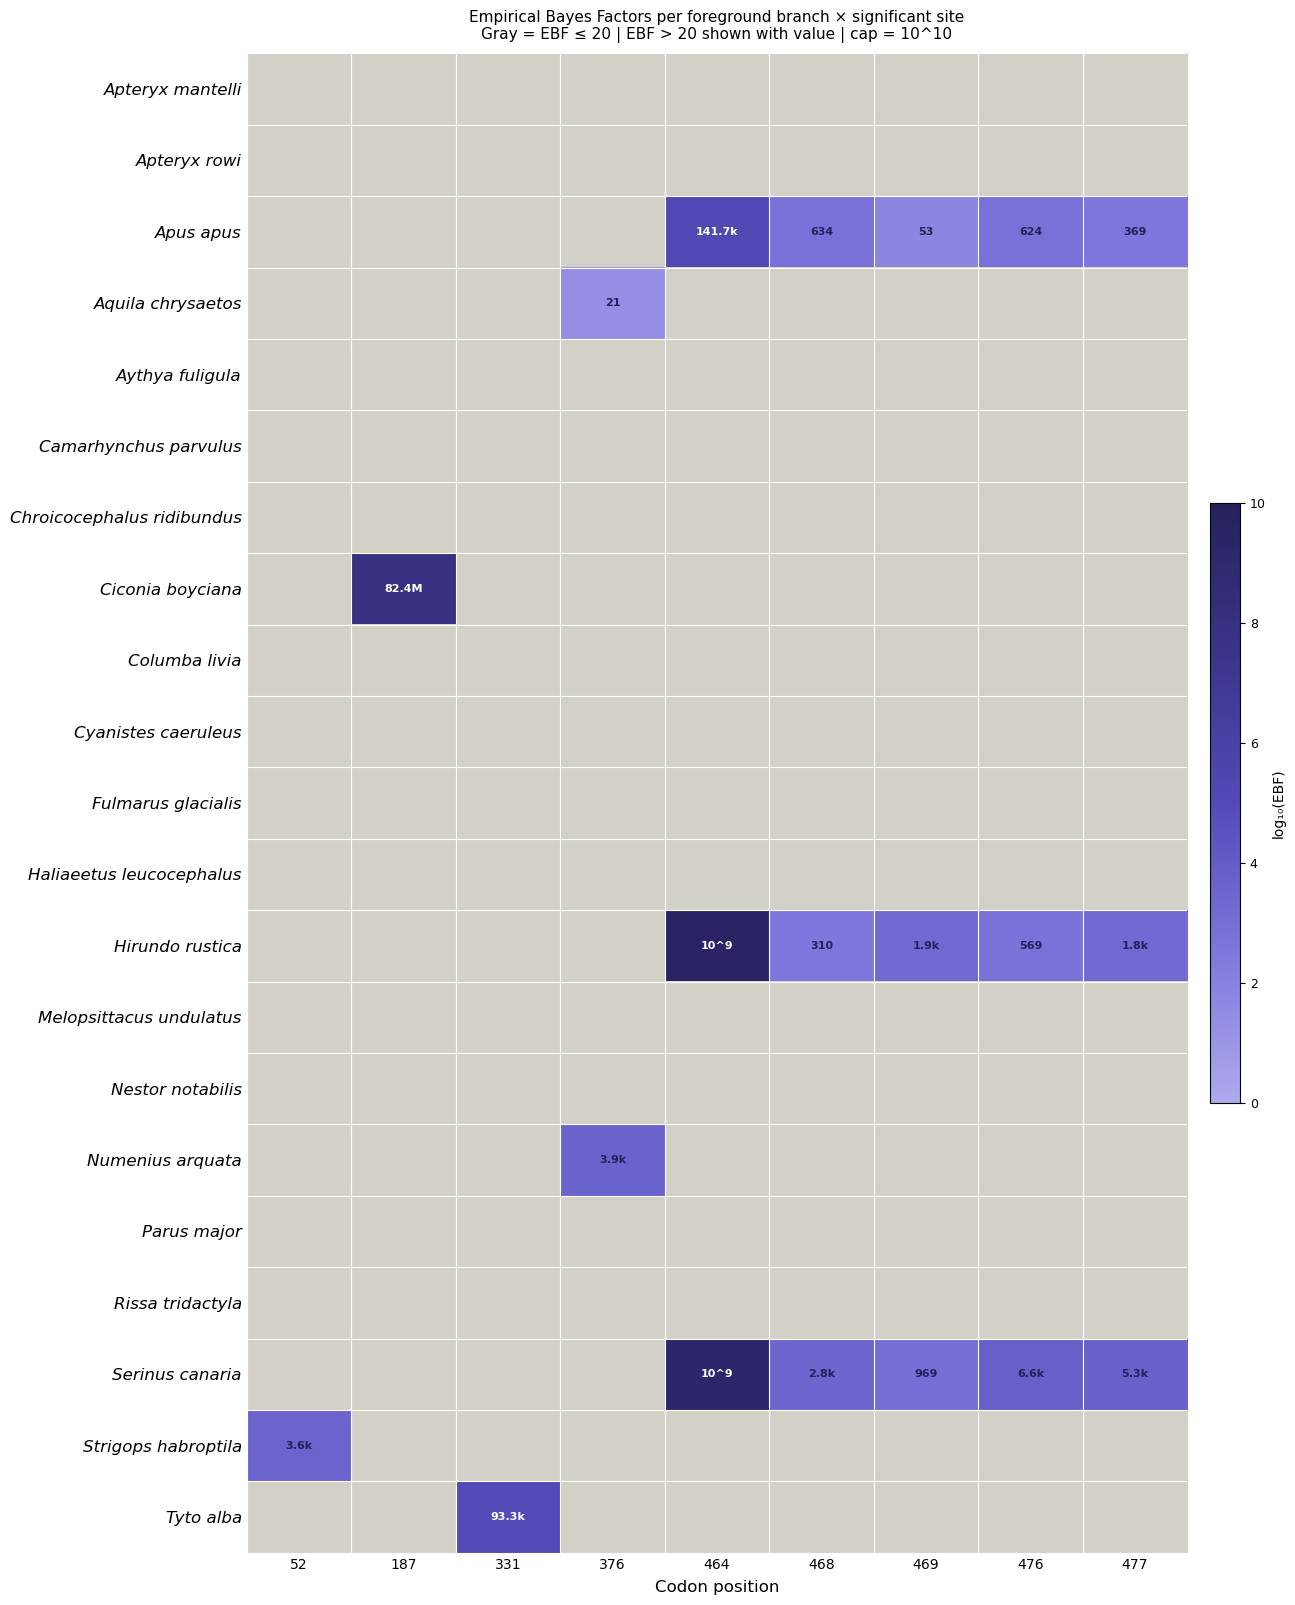

Saved → meme_ebf_heatmap.pdf


In [197]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# Config for notebook
# =========================
JSON_PATH = "pipeline_results/09_meme/MAGI3_meme.json"
OUT_PATH = "meme_ebf_heatmap.pdf"

EBF_THRESH = 20          # below this → gray
LOG_CAP = 10             # log10 cap for colour scale
GRAY = "#d3d1c7"

SPECIES_FONT_SIZE = 12   # размер шрифта видов
SITE_FONT_SIZE = 10
AXIS_FONT_SIZE = 12
TITLE_FONT_SIZE = 11
CELL_TEXT_SIZE = 8


# =========================
# Load MEME JSON
# =========================
with open(JSON_PATH) as f:
    data = json.load(f)


# =========================
# Identify foreground branches
# =========================
tested = data["tested"]["0"]

foreground = [
    b for b, role in tested.items()
    if role == "test"
]

foreground = sorted(foreground)

# labels without underscores
foreground_labels = [
    b.replace("_", " ")
    for b in foreground
]


# =========================
# Identify significant sites: p <= 0.1
# =========================
mle_content = data["MLE"]["content"]["0"]

PVAL_IDX = 6    # p-value column index
PPLUS_IDX = 4   # p+ column index

sig_sites = []

for i, row in enumerate(mle_content):
    pval = row[PVAL_IDX]
    p_plus = row[PPLUS_IDX]

    if pval <= 0.1:
        sig_sites.append((i, p_plus))

if not sig_sites:
    raise ValueError("No significant sites found with p <= 0.1")

site_indices = [s[0] for s in sig_sites]
site_labels = [str(s[0] + 1) for s in sig_sites]  # 1-based codon numbers
prior_plus = {s[0]: s[1] for s in sig_sites}


# =========================
# Compute EBF matrix
# =========================
ba = data["branch attributes"]["0"]

ebf_matrix = np.zeros((len(foreground), len(site_indices)))

for bi, branch in enumerate(foreground):
    pp = ba[branch]["Posterior prob omega class by site"]

    p_minus_arr = pp[0]
    p_plus_arr = pp[1]

    for si, site_idx in enumerate(site_indices):
        post_plus = p_plus_arr[site_idx]
        post_minus = p_minus_arr[site_idx]

        pp_prior = prior_plus[site_idx]
        pm_prior = 1.0 - pp_prior

        if post_minus > 0 and pp_prior > 0 and pm_prior > 0:
            ebf = (post_plus / post_minus) / (pp_prior / pm_prior)
        else:
            ebf = 0.0

        ebf_matrix[bi, si] = ebf


# =========================
# Build colour array
# =========================
purple_cmap = mcolors.LinearSegmentedColormap.from_list(
    "purple_ramp",
    ["#afa9ec", "#7f77dd", "#534ab7", "#3c3489", "#26215c"]
)

nB, nS = ebf_matrix.shape

color_array = np.full((nB, nS, 4), 0.0)
gray_rgba = mcolors.to_rgba(GRAY)

for bi in range(nB):
    for si in range(nS):
        v = ebf_matrix[bi, si]

        if v > EBF_THRESH:
            lv = min(LOG_CAP, math.log10(v + 1)) / LOG_CAP
            color_array[bi, si] = purple_cmap(lv)
        else:
            color_array[bi, si] = gray_rgba


# =========================
# Helper for EBF labels
# =========================
def fmt_ebf(v):
    if v >= 1e9:
        e = int(math.log10(v))
        return f"10^{e}"
    elif v >= 1e6:
        return f"{v / 1e6:.1f}M"
    elif v >= 1e3:
        return f"{v / 1e3:.1f}k"
    else:
        return f"{int(round(v))}"


# =========================
# Plot
# =========================
CELL_H = 0.65
FIG_W = max(10, nS * 1.0 + 5)
FIG_H = max(6, nB * CELL_H + 2.5)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.imshow(
    color_array,
    aspect="auto",
    interpolation="nearest",
    extent=[-0.5, nS - 0.5, nB - 0.5, -0.5]
)


# =========================
# Cell text for EBF > threshold
# =========================
for bi in range(nB):
    for si in range(nS):
        v = ebf_matrix[bi, si]

        if v > EBF_THRESH:
            lv = min(LOG_CAP, math.log10(v + 1)) / LOG_CAP
            txt_color = "white" if lv > 0.45 else "#26215c"

            ax.text(
                si,
                bi,
                fmt_ebf(v),
                ha="center",
                va="center",
                fontsize=CELL_TEXT_SIZE,
                fontweight="bold",
                color=txt_color
            )


# =========================
# Axes
# =========================
ax.set_xticks(range(nS))
ax.set_xticklabels(site_labels, fontsize=SITE_FONT_SIZE)

ax.set_yticks(range(nB))
ax.set_yticklabels(
    foreground_labels,
    fontsize=SPECIES_FONT_SIZE,
    style="italic"
)

ax.set_xlabel("Codon position", fontsize=AXIS_FONT_SIZE, labelpad=6)
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)


# =========================
# Grid lines
# =========================
for x in np.arange(-0.5, nS, 1):
    ax.axvline(x, color="white", lw=0.8)

for y in np.arange(-0.5, nB, 1):
    ax.axhline(y, color="white", lw=0.8)


# =========================
# Colourbar
# =========================
sm = plt.cm.ScalarMappable(
    cmap=purple_cmap,
    norm=mcolors.Normalize(vmin=0, vmax=LOG_CAP)
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.4,
    pad=0.02,
    aspect=20
)

cbar.set_label("log₁₀(EBF)", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 2, 4, 6, 8, 10])


# =========================
# Title
# =========================
ax.set_title(
    "Empirical Bayes Factors per foreground branch × significant site\n"
    f"Gray = EBF ≤ {EBF_THRESH} | EBF > {EBF_THRESH} shown with value | cap = 10^{LOG_CAP}",
    fontsize=TITLE_FONT_SIZE,
    pad=10
)

plt.tight_layout()

plt.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved → {OUT_PATH}")

# absrel визуализация

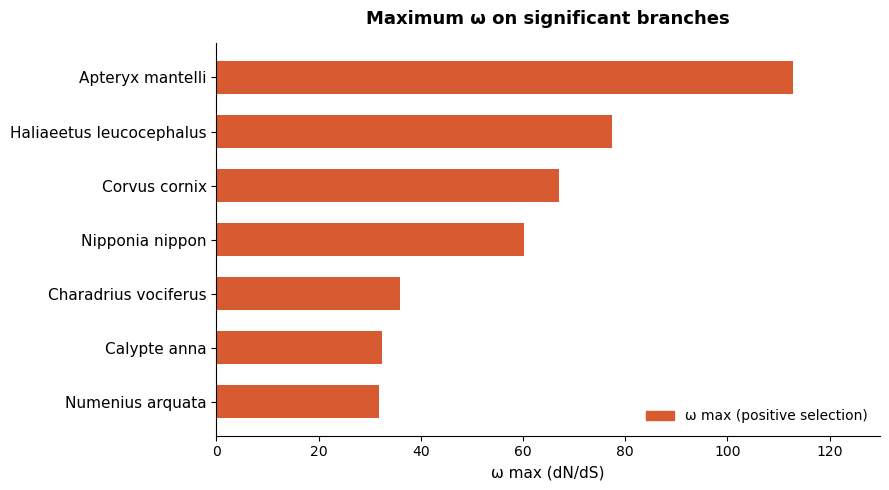

In [199]:
# dn_ds_pipeline_easy_search/pipeline_results/09_absrel/GALNT7_absrel.json
# dn_ds_pipeline_easy_search/pipeline_results/09_absrel/EPHA6_absrel.json
# dn_ds_pipeline_easy_search/pipeline_results/09_absrel/MAGI3_absrel.json

import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with open("pipeline_results/09_absrel/GALNT7_absrel.json") as f:
    data = json.load(f)

ba = data["branch attributes"]["0"]

sig_branches = []
for branch, attrs in ba.items():
    p_corr = attrs.get("Corrected P-value", 1.0)
    rate_dist = attrs.get("Rate Distributions", None)
    if p_corr is not None and p_corr < 0.05 and rate_dist:
        omega_max = max(cls[0] for cls in rate_dist)
        sig_branches.append((branch.replace("_", " "), omega_max, p_corr))

sig_branches.sort(key=lambda x: x[1], reverse=True)

names  = [b[0] for b in sig_branches]
omegas = [b[1] for b in sig_branches]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(names, omegas, color="#D85A30", height=0.6)

ax.invert_yaxis()
ax.set_xlabel("ω max (dN/dS)", fontsize=11)
ax.set_title("Maximum ω on significant branches", fontweight="bold", fontsize=13, pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
ax.set_xlim(0, max(omegas) * 1.15)

legend = mpatches.Patch(color="#D85A30", label="ω max (positive selection)")
ax.legend(handles=[legend], fontsize=10, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("GALNT7_absrel_omega.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
dn_ds_pipeline_easy_search/pipeline_results/09_absrel/GALNT7_absrel.json
